# 0. Préparation de l'environnement de travail

### Importation des librairies

In [93]:
import warnings

# Suppress the warning
warnings.simplefilter(action='ignore', category=FutureWarning)

In [94]:
import os
import re
import numpy as np
import pandas as pd
from  matplotlib  import pyplot as plt
import time

In [95]:
start_time = time.time()

In [96]:
import importlib
import My_function_p4_explo

In [97]:
# pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)

### Définition du répertoire de travail

In [98]:
os.chdir("C:/Users/guill/Documents/OpenClassrooms/Reborn/Projet 4/Last week")

### Importation du fichier

In [99]:
df = pd.read_csv("2016_Building_Energy_Benchmarking.csv")
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


# 1. Caractéristiques

## 1.0. Aperçu

On travaille sur une copie : 

In [100]:
df_copy = df.copy()

In [101]:
df_copy.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,7,DOWNTOWN,47.61220,-122.33799,1927,1.0,12,88434,0,88434,Hotel,Hotel,88434.0,NaN,NaN,NaN,NaN,NaN,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,7,DOWNTOWN,47.61317,-122.33393,1996,1.0,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,83880.0,Parking,15064.0,Restaurant,4622.0,NaN,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,7,DOWNTOWN,47.61393,-122.33810,1969,1.0,41,956110,196718,759392,Hotel,Hotel,756493.0,NaN,NaN,NaN,NaN,NaN,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,7,DOWNTOWN,47.61412,-122.33664,1926,1.0,10,61320,0,61320,Hotel,Hotel,61320.0,NaN,NaN,NaN,NaN,NaN,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,7,DOWNTOWN,47.61375,-122.34047,1980,1.0,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,123445.0,Parking,68009.0,Swimming Pool,0.0,NaN,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [102]:
df_copy.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,3376.000000,3.376000e+03,3.356000e+03,1679.000000,596.000000,2533.000000,3369.000000,3370.000000,3367.000000,3367.000000,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,8001.526066,8.683201e+04,7.917764e+04,28444.075817,11738.675166,67.918674,54.732116,57.033798,134.232848,137.783932,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,32326.723928,2.079398e+05,2.017034e+05,54392.917928,29331.199286,26.873271,56.273124,57.163330,139.287554,139.109807,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,0.000000,3.636000e+03,5.656000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-2.100000,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,0.000000,2.775600e+04,2.509475e+04,5000.000000,2239.000000,53.000000,27.900000,29.400000,74.699997,78.400002,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,0.000000,4.321600e+04,3.989400e+04,10664.000000,5043.000000,75.000000,38.599998,40.900002,96.199997,101.099998,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,0.000000,8.427625e+04,7.620025e+04,26640.000000,10138.750000,90.000000,60.400002,64.275002,143.899994,148.349998,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,512608.000000,9.320156e+06,9.320156e+06,686750.000000,459748.000000,100.000000,834.400024,834.400024,2620.000000,2620.000000,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


Dans ce premier aperçu, on voit que : 
- il y'a des NaN 
- il y'a des valeurs négatives 
- les échelles de valeurs ne sont pas toutes les mêmes
- certaines colonnes ne prennent qu'une seule et même valeur

## 1.1. Datatypes

Vérifions les types de chaque colonnes : 

In [103]:
df_copy.dtypes

OSEBuildingID                        int64
DataYear                             int64
BuildingType                        object
PrimaryPropertyType                 object
PropertyName                        object
Address                             object
City                                object
State                               object
ZipCode                            float64
TaxParcelIdentificationNumber       object
CouncilDistrictCode                  int64
Neighborhood                        object
Latitude                           float64
Longitude                          float64
YearBuilt                            int64
NumberofBuildings                  float64
NumberofFloors                       int64
PropertyGFATotal                     int64
PropertyGFAParking                   int64
PropertyGFABuilding(s)               int64
ListOfAllPropertyUseTypes           object
LargestPropertyUseType              object
LargestPropertyUseTypeGFA          float64
SecondLarge

On les enregistre :

In [104]:
from My_function_p4_explo import type_definition
importlib.reload(My_function_p4_explo)
num_col, cat_col = type_definition(df_copy)

Colonnes numériques : ['OSEBuildingID', 'DataYear', 'ZipCode', 'CouncilDistrictCode', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'TotalGHGEmissions', 'GHGEmissionsIntensity']
Colonnes catégoriques : ['BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'TaxParcelIdentificationNumber', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified', 'ComplianceStatus', 'Outlier']


Correction des dtypes :

In [105]:
wrong_type_num = ('OSEBuildingID', 'ZipCode', 'CouncilDistrictCode', 'DefaultData', 'Comments')
for col in wrong_type_num:
    df_copy[col] = df_copy[col].astype(str)

Actualise les datatypes :

In [106]:
num_col, cat_col = type_definition(df_copy)

Colonnes numériques : ['DataYear', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity']
Colonnes catégoriques : ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'City', 'State', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified', 'DefaultData', 'Comments', 'ComplianceStatus', 'Outlier']


## 1.2. Modalités

Nombre de valeurs unique par colonne :

In [107]:
df_copy.nunique().head(10)

OSEBuildingID                    3376
DataYear                            1
BuildingType                        8
PrimaryPropertyType                24
PropertyName                     3362
Address                          3354
City                                1
State                               1
ZipCode                            56
TaxParcelIdentificationNumber    3268
dtype: int64

In [108]:
from My_function_p4_explo import get_modalities

info_from_unique_column = get_modalities(df_copy)

Il y a 42 colonnes avec au moins 2 valeurs, voici leurs nombres de modalités respectives
[('DefaultData', 2), ('Outlier', 2), ('ComplianceStatus', 4), ('CouncilDistrictCode', 7), ('BuildingType', 8), ('NumberofBuildings', 17), ('Neighborhood', 19), ('PrimaryPropertyType', 24), ('ThirdLargestPropertyUseType', 44), ('NumberofFloors', 50), ('SecondLargestPropertyUseType', 50), ('ZipCode', 56), ('LargestPropertyUseType', 56), ('YearsENERGYSTARCertified', 65), ('ENERGYSTARScore', 100), ('YearBuilt', 113), ('SteamUse(kBtu)', 131), ('ListOfAllPropertyUseTypes', 466), ('PropertyGFAParking', 496), ('ThirdLargestPropertyUseTypeGFA', 501), ('GHGEmissionsIntensity', 511), ('SiteEUI(kBtu/sf)', 1085), ('SiteEUIWN(kBtu/sf)', 1105), ('SecondLargestPropertyUseTypeGFA', 1352), ('SourceEUI(kBtu/sf)', 1648), ('SourceEUIWN(kBtu/sf)', 1694), ('NaturalGas(therms)', 2109), ('NaturalGas(kBtu)', 2109), ('Longitude', 2656), ('TotalGHGEmissions', 2818), ('Latitude', 2876), ('LargestPropertyUseTypeGFA', 3122), ('P

Suppression des colonnes inutiles :

In [109]:
from My_function_p4_explo import drop_low_modalities


df_copy = drop_low_modalities(df_copy, info_from_unique_column)

Before drop : (3376, 46)
After drop : (3376, 42)


On actualise num_col et cat_col

In [110]:
num_col, cat_col = type_definition(df_copy)

Colonnes numériques : ['Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity']
Colonnes catégoriques : ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified', 'DefaultData', 'ComplianceStatus', 'Outlier']


Standardisation des chaines de caractères :

In [111]:
from My_function_p4_explo import clean_strings

df_copy = clean_strings(df_copy, cat_col=cat_col)

### 1.2.1. Condition projet

Garde les non-résidentielles, stocke les outliers et les DefaultData particulier :


In [112]:
df_copy = df_copy[df_copy["BuildingType"].str.contains("nonresidential")]

In [113]:
from My_function_p4_explo import find_error_col
col = "ComplianceStatus"
errors = ["error - correct default data"]
df_copy = find_error_col(df_copy, col, errors)

Shape of df: (1546, 42)
Shape of df cleaned: (1533, 42)


In [114]:
col_to_check = "Outlier"
errors_to_find = ["low outlier", "high outlier"]

df_copy = find_error_col(df_copy, col = col_to_check, errors = errors_to_find)

Shape of df: (1533, 42)
Shape of df cleaned: (1518, 42)


In [115]:
num_col, cat_col = type_definition(df_copy)
df_copy['Outlier'] = df_copy['Outlier'].astype(str)
num_col, cat_col = type_definition(df_copy)

Colonnes numériques : ['Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)', 'TotalGHGEmissions', 'GHGEmissionsIntensity']
Colonnes catégoriques : ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified', 'DefaultData', 'ComplianceStatus', 'Outlier']
Colonnes numériques : ['Latitude', 'Longitude', '

In [116]:
col_to_check = "ComplianceStatus"
errors_to_find = ["non-compliant"]

df_copy = find_error_col(df_copy, col = col_to_check, errors = errors_to_find)

Shape of df: (1518, 42)
Shape of df cleaned: (1515, 42)


In [117]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import keep_value_col

col_to_check = "ComplianceStatus"
values_to_check = ["compliant"]

df_copy = keep_value_col(df_copy, col = col_to_check, values = values_to_check)

Shape of df: (1515, 42)
Shape of df cleaned: (1514, 42)


In [118]:
col_to_check = "DefaultData"
values_to_check = ["false"]

df_copy = keep_value_col(df_copy, col = col_to_check, values = values_to_check)

Shape of df: (1514, 42)
Shape of df cleaned: (1514, 42)


## 1.3. Doublons

In [119]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import keep_unique

pkey = "OSEBuildingID"

df_copy = keep_unique(df_copy, pkey, keep='first')

Number of duplicate rows based on primary key OSEBuildingID: 0
Shape of df with unique primary key OSEBuildingID: (1514, 42)


Il n'y a pas de doublons. Certains ID batiments ont le même ID de taxe parcelle mais ce sont des batiments différents.

In [120]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import get_duplicate

pkey = "TaxParcelIdentificationNumber"

get_duplicate(df_copy, pkey, keep='first')

Number of duplicate rows based on primary key TaxParcelIdentificationNumber: 78


In [121]:
df_copy.shape

(1514, 42)

Il reste 1514 lignes et 42 colonnes.

# 2. NaN

## 2.1. Aperçu

In [122]:
df_copy = df_copy.replace('nan', np.nan)

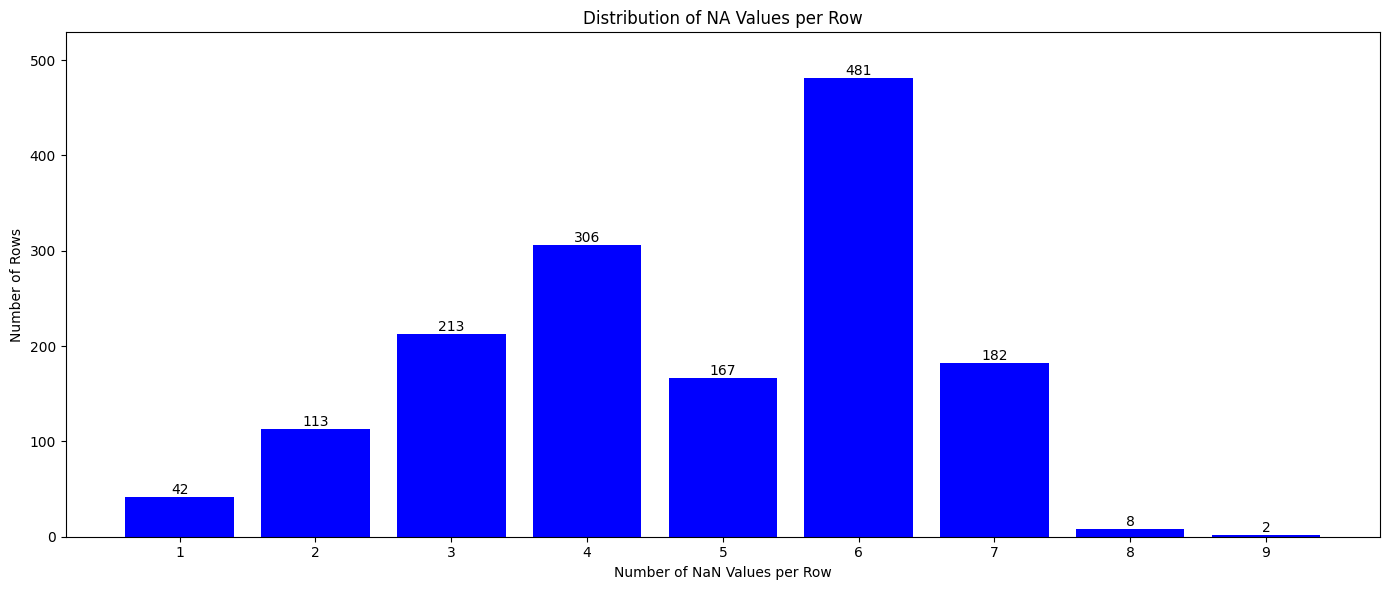

In [123]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import check_na_row, plot_na_row

# 1. Calculate NA values per row and their distribution
distrib_na_row_df_copy, total_na_df_copy,  = check_na_row(df_copy)

# 2. Plot the distribution of NA values per row
plot_na_row(distrib_na_row_df_copy, total_na_df_copy)

In [124]:
df_copy[df_copy.isnull().sum(axis=1)==8]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
1147,21103,nonresidential,hotel,palladian hotel,2000 second avenue,98121.0,1977201140,7,downtown,47.61203,-122.34165,1910,1.0,8,61721,0,61721,hotel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.0,52.200001,53.500000,150.399994,154.399994,2.897080e+06,2.968430e+06,0.0,742846.3750,2.534592e+06,3624.875244,3.624880e+05,false,compliant,NaN,36.92,0.60
2414,25568,nonresidential,small- and mid-sized office,talon northlake llc,1341 n northlake way,98103.0,4088804565,4,lake union,47.64747,-122.34086,2008,1.0,4,48350,0,48350,office,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.0,72.199997,74.699997,226.600006,234.600006,3.168131e+06,3.280956e+06,0.0,928526.0000,3.168131e+06,0.000000,0.000000e+00,false,compliant,NaN,22.09,0.46
3361,50198,nonresidential cos,other,fire station 06,405 mlk jr way s,NaN,1250200565,3,central,47.59905,-122.29787,2013,1.0,1,11685,0,11685,prison/incarceration,prison/incarceration,11685.0,NaN,NaN,NaN,NaN,NaN,NaN,72.800003,82.900002,138.600006,149.199997,8.510538e+05,9.691420e+05,0.0,101784.5000,3.472887e+05,5037.649902,5.037650e+05,false,compliant,NaN,29.18,2.50
3362,50201,nonresidential cos,other,fire station 35,8729 15th ave nw,NaN,3300700810,6,ballard,47.69330,-122.37717,2010,1.0,1,11968,0,11968,prison/incarceration,prison/incarceration,11968.0,NaN,NaN,NaN,NaN,NaN,NaN,65.500000,71.800003,139.199997,149.000000,7.834230e+05,8.587730e+05,0.0,118183.7969,4.032431e+05,3801.799805,3.801800e+05,false,compliant,NaN,23.00,1.92
3363,50204,nonresidential cos,other,fire station 39,2806 ne 127th st,NaN,3834500066,5,north,47.72126,-122.29735,1949,1.0,1,11285,0,11285,prison/incarceration,prison/incarceration,11285.0,NaN,NaN,NaN,NaN,NaN,NaN,57.200001,62.599998,140.000000,148.399994,6.456654e+05,7.059837e+05,0.0,126552.0000,4.317954e+05,2138.700195,2.138700e+05,false,compliant,NaN,14.37,1.27
3367,50212,nonresidential cos,other,conservatory campus,1400 e galer st,NaN,2925049087,3,east,47.63228,-122.31574,1912,1.0,1,23445,0,23445,other - recreation,other - recreation,23445.0,NaN,NaN,NaN,NaN,NaN,NaN,254.899994,286.500000,380.100006,413.200012,5.976246e+06,6.716330e+06,0.0,369539.8125,1.260870e+06,47153.757810,4.715376e+06,false,compliant,NaN,259.22,11.06
3370,50221,nonresidential cos,other,high point community center,6920 34th ave sw,NaN,2524039059,1,delridge neighborhoods,47.54067,-122.37441,1982,1.0,1,18261,0,18261,other - recreation,other - recreation,18261.0,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,56.200001,126.000000,136.600006,9.320821e+05,1.025432e+06,0.0,185334.7031,6.323620e+05,2997.199951,2.997200e+05,false,compliant,NaN,20.33,1.11
3372,50223,nonresidential cos,other,international district/chinatown cc,719 8th ave s,NaN,3558300000,2,downtown,47.59625,-122.32283,2004,1.0,1,16000,0,16000,other - recreation,other - recreation,16000.0,NaN,NaN,NaN,NaN,NaN,NaN,59.400002,65.900002,114.199997,118.900002,9.502762e+05,1.053706e+06,0.0,116221.0000,3.965461e+05,5537.299805,5.537300e+05,false,compliant,NaN,32.17,2.01


En généralisant, si ListOfAllPropertyUseTypes contient une seule valeur, on peut l'attribuer à LargestPropertyUseType.

In [125]:
df_copy["Nb_UseType"] = df_copy["ListOfAllPropertyUseTypes"].str.split(',').str.len()
df_copy[["Nb_UseType","ListOfAllPropertyUseTypes"]].head()

,Nb_UseType,ListOfAllPropertyUseTypes
0,1,hotel
1,3,"hotel,parking,restaurant"
2,1,hotel
3,1,hotel
4,3,"hotel,parking,swimming pool"


In [126]:
df_copy[["LargestPropertyUseTypeGFA","SecondLargestPropertyUseTypeGFA","ThirdLargestPropertyUseTypeGFA"]].isna().sum()

LargestPropertyUseTypeGFA             4
SecondLargestPropertyUseTypeGFA     685
ThirdLargestPropertyUseTypeGFA     1174
dtype: int64

## 2.2. Règles

On entre les règles de remplissage des NaN pour chaque colonne :

In [127]:
na_rules = {
    'LargestPropertyUseTypeGFA': [(lambda x: x['Nb_UseType'] == 1, df_copy["PropertyGFATotal"])],
    'LargestPropertyUseType': [(lambda x: x['Nb_UseType'] == 1, df_copy["ListOfAllPropertyUseTypes"])],

    'SecondLargestPropertyUseTypeGFA': [(lambda x: x['Nb_UseType'] < 2, 0)],
    'SecondLargestPropertyUseType': [(lambda x: x['Nb_UseType'] < 2, "Aucun")],

    'ThirdLargestPropertyUseTypeGFA': [(lambda x: x['Nb_UseType'] < 3, 0)],
    'ThirdLargestPropertyUseType': [(lambda x: x['Nb_UseType'] < 3, "Aucun")],

    'Outlier': [(lambda x: x['Outlier'].isna()==True, 0)],
    'ZipCode': [(lambda x: x['ZipCode'].isna()==True, "Aucun")],
    'YearsENERGYSTARCertified': [(lambda x: x['YearsENERGYSTARCertified'].isna()==True, "Aucun")],
    'ENERGYSTARScore' :[(lambda x: x['ENERGYSTARScore'].isna()==True, 0)],
}

In [128]:
from My_function_p4_explo import conditional_fill_na
df_copy = conditional_fill_na(df_copy, na_rules)

In [129]:
df_energy = df_copy[["OSEBuildingID","ENERGYSTARScore"]]

In [130]:
df_copy[["LargestPropertyUseTypeGFA","SecondLargestPropertyUseTypeGFA","ThirdLargestPropertyUseTypeGFA"]].isna().sum()

LargestPropertyUseTypeGFA          1
SecondLargestPropertyUseTypeGFA    1
ThirdLargestPropertyUseTypeGFA     2
dtype: int64

## 2.3. Reste

In [131]:
df_copy[df_copy["ThirdLargestPropertyUseTypeGFA"].isna()==True]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,Nb_UseType
266,393,nonresidential,other,500 yale,500 yale ave n,98109.0,0209000030,7,lake union,47.62323,-122.33028,2009,1.0,5,141131,69710,71421,"office,parking,personal services",parking,74831.0,office,71643.0,NaN,NaN,Aucun,0.0,43.099998,43.099998,135.199997,135.199997,3085814.0,3085814.0,0.0,904400.1875,3085813.0,0.00000,0.0,false,compliant,0.0,21.51,0.15,3
353,496,nonresidential,self-storage facility,market st center,2811 nw market street,98107.0,1175001235,6,ballard,47.66838,-122.39310,1946,2.0,2,111445,0,111445,"fitness center/health club/gym,office,other - ...",NaN,NaN,NaN,NaN,NaN,NaN,Aucun,0.0,47.799999,51.000000,103.000000,106.400002,5697472.5,6076957.0,0.0,881452.0000,3007514.0,26899.58203,2689958.0,false,compliant,0.0,163.83,1.47,11


On entre les 2 derniers manuellement :

In [132]:
id_393 = df_copy["OSEBuildingID"]=="393"

In [133]:
use_of_id_393 = df_copy.loc[id_393,"ListOfAllPropertyUseTypes"]
use_of_id_393.values

array(['office,parking,personal services'], dtype=object)

In [134]:
df_copy.loc[id_393, "LargestPropertyUseType"] = "office"
df_copy.loc[id_393, "SecondLargestPropertyUseType"] = "parking"
df_copy.loc[id_393, "ThirdLargestPropertyUseType"] = "personal services"

df_copy.loc[id_393, "LargestPropertyUseTypeGFA"] = df_copy["PropertyGFATotal"]/2
df_copy.loc[id_393, "SecondLargestPropertyUseTypeGFA"] = df_copy["PropertyGFATotal"]/2
df_copy.loc[id_393, "ThirdLargestPropertyUseTypeGFA"] = 0

In [135]:
id_496 = df_copy["OSEBuildingID"]=="496"

In [136]:
use_of_id_496 = df_copy.loc[id_496,"ListOfAllPropertyUseTypes"]
use_of_id_496.values

array(['fitness center/health club/gym,office,other - education,other - recreation,other - restaurant/bar,outpatient rehabilitation/physical therapy,personal services ,restaurant,retail store,self-storage facility,vocat'],
      dtype=object)

In [137]:
df_copy.loc[id_496, "LargestPropertyUseType"] = "fitness center/health club/gym"
df_copy.loc[id_496, "SecondLargestPropertyUseType"] = "office"
df_copy.loc[id_496, "ThirdLargestPropertyUseType"] = "other"

df_copy.loc[id_496, "LargestPropertyUseTypeGFA"] = np.nan
df_copy.loc[id_496, "SecondLargestPropertyUseTypeGFA"] = np.nan
df_copy.loc[id_496, "ThirdLargestPropertyUseTypeGFA"] = np.nan

Si nous étions à court de data, nous pourrions teter de récupérer comme ceci : 

1 - Remplacer par le % median, par catégorie

2 - Appliquer le % par rapport à PropertyGFATotal

On pourrait aussi garder le total comme Primary et mettre 0 aux autres.

Ici, nous supprimerons la ligne.

In [138]:
df_copy.isna().sum().sort_values(ascending=False).head(6)

SecondLargestPropertyUseTypeGFA    1
SiteEnergyUseWN(kBtu)              1
LargestPropertyUseTypeGFA          1
SiteEUIWN(kBtu/sf)                 1
ThirdLargestPropertyUseTypeGFA     1
ComplianceStatus                   0
dtype: int64

In [139]:
df_copy[df_copy["SiteEnergyUseWN(kBtu)"].isna()==True]

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,Nb_UseType
563,757,nonresidential,large office,market place i & ii-2003 western avenue,2003 western avenue,98121.0,1977200280,7,downtown,47.61051,-122.34439,1979,1.0,7,131143,87160,43983,"office,retail store",office,120248.0,retail store,10853.0,Aucun,0.0,Aucun,93.0,39.5,NaN,128.0,0.0,5177270.5,NaN,0.0,1427645.25,4871126.0,14160.40918,1416041.0,false,compliant,0.0,109.16,0.83,2


On pourrait déduire la valeur en prenant le rapport moyen-median utilisé pour passer de SiteEnergyUse à WN. Comme c'est notre cible et qu'il n'y a qu'une ligne, on supprime la ligne.

In [140]:
df_copy = df_copy.dropna()

In [141]:
df_copy.isna().sum().sum()

0

In [142]:
df_copy.shape

(1512, 43)

In [143]:
df_copy.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kWh)',
       'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)',
       'DefaultData', 'ComplianceStatus', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsInte

In [144]:
df_copy = df_copy.drop(columns=['NaturalGas(therms)','Electricity(kWh)','DefaultData', 'ComplianceStatus'])

Il nous reste 1512 lignes.

# 3. Outliers

## 3.0. Incohérences

### Vérifications énergie

On part de l'hypothèse que la somme des 3 sources est la valeur de référence. On la vérifie et on garde uniquement les lignes dont l'hypothèse se vérifie, avec 1% de marge d'erreur.

In [145]:
target_column = "SiteEnergyUse(kBtu)"
target_index = df_copy.columns.get_loc(target_column)
df_copy.insert(loc=target_index, column="Verif_Sum_Energy", value = 
               df_copy["SteamUse(kBtu)"] + df_copy["Electricity(kBtu)"] + df_copy["NaturalGas(kBtu)"] )

In [146]:
target_column = "SiteEnergyUse(kBtu)"
target_index = df_copy.columns.get_loc(target_column)
df_copy.insert(loc=target_index, column="Diff_Verif_Sum_Energy", value = 
               df_copy["Verif_Sum_Energy"] - df_copy["SiteEnergyUse(kBtu)"] )

In [147]:
target_column = "Diff_Verif_Sum_Energy"
target_index = df_copy.columns.get_loc(target_column)
df_copy.insert(loc=target_index, column="%_Ratio_Diff_Energy_Verif", value = 
               round(100*df_copy["Diff_Verif_Sum_Energy"] / df_copy["SiteEnergyUse(kBtu)"],3) )

In [148]:
df_copy[["SiteEnergyUse(kBtu)","Verif_Sum_Energy","Diff_Verif_Sum_Energy","%_Ratio_Diff_Energy_Verif", "SteamUse(kBtu)","Electricity(kBtu)","NaturalGas(kBtu)"]].head()

,SiteEnergyUse(kBtu),Verif_Sum_Energy,Diff_Verif_Sum_Energy,%_Ratio_Diff_Energy_Verif,SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu)
0,7226362.5,7226362.00,-0.50,-0.0,2003882.00,3946027.0,1276453.0
1,8387933.0,8387933.00,0.00,0.0,0.00,3242851.0,5145082.0
2,72587024.0,72587018.00,-6.00,-0.0,21566554.00,49526664.0,1493800.0
3,6794584.0,6794583.25,-0.75,-0.0,2214446.25,2768924.0,1811213.0
4,14172606.0,14172605.00,-1.00,-0.0,0.00,5368607.0,8803998.0


In [149]:
df_copy[abs(df_copy["%_Ratio_Diff_Energy_Verif"]) > 1].shape

(21, 42)

Il y'a 21 individus pour lesquels la vérif energ indique une erreur d'au moins 1% de la consommation.
On les supprime

In [150]:
df_copy = df_copy[~(abs(df_copy["%_Ratio_Diff_Energy_Verif"]) > 1)]
df_copy.shape

(1491, 42)

In [151]:
col_to_drop = ["%_Ratio_Diff_Energy_Verif", "Verif_Sum_Energy","Diff_Verif_Sum_Energy"]
df_copy = df_copy.drop(columns=col_to_drop)

### Vérifications GFA

Attention, il y'a des incohérences de données : certains parking ne sont pas pris en compte dans le PropertyGFATotal. Exemple OSEBuildingID 326, devrait être autour de 510 000 au lieu de 383k. 

Nous avons 2 hypothèses probables : 
H1 - La somme des 3 usetype est correcte
H2 - La somme de Building et Parking est correcte

=> <u> Nous allons comparer les valeurs obtenues dans les 2 hypothèses et garder celle qui demande le moins d'ajustement des données. </u>

Nous calculons d'abord en additionnant les surfaces Parking et batiments :

In [152]:
target_column = "PropertyGFATotal"
target_index = df_copy.columns.get_loc(target_column)
df_copy.insert(loc=target_index, column="Sum_2_Build_Park", value=df_copy["PropertyGFAParking"] + df_copy["PropertyGFABuilding(s)"])

2è vérification, nous sommons les surfaces pour les 3 usages :

In [153]:
df_copy["Sum_3_Uses_GFA"] = df_copy["LargestPropertyUseTypeGFA"] + df_copy["SecondLargestPropertyUseTypeGFA"] + df_copy["ThirdLargestPropertyUseTypeGFA"]

In [154]:
df_copy[["PropertyGFATotal","Sum_3_Uses_GFA","Sum_2_Build_Park"]].head()

,PropertyGFATotal,Sum_3_Uses_GFA,Sum_2_Build_Park
0,88434,88434.0,88434
1,103566,103566.0,103566
2,956110,756493.0,956110
3,61320,61320.0,61320
4,175580,191454.0,175580


In [155]:
df_copy[["PropertyGFATotal","Sum_3_Uses_GFA","Sum_2_Build_Park"]].isna().sum()

PropertyGFATotal    0
Sum_3_Uses_GFA      0
Sum_2_Build_Park    0
dtype: int64

On calcule la différence pour chacune :

In [156]:
df_copy["delta_sum_3"] = df_copy["Sum_3_Uses_GFA"] - df_copy["PropertyGFATotal"]
df_copy["delta_sum_2"] = df_copy["Sum_2_Build_Park"] - df_copy["PropertyGFATotal"]
med_delta_2 = df_copy["delta_sum_2"].median()
med_delta_3 = df_copy["delta_sum_3"].median()

print(med_delta_2)
print(med_delta_3)

0.0
0.0


Au moins, les 2 Hypothèses au minimum 50°% de valeurs correctes.

In [157]:
mean_delta_2 = df_copy["delta_sum_2"].mean()
mean_delta_3 = df_copy["delta_sum_3"].mean()
print(mean_delta_2)
print(mean_delta_3)

0.0
939.5095208343394


On garde l'hypothèse N°2 de la somme de parking et building. 

Nous devons ajuster les valeurs des 3 UseType pour qu'elles suivent cette hypothèse.

In [158]:
sum_before_1 = df_copy["LargestPropertyUseTypeGFA"].sum()
sum_before_2 = df_copy["SecondLargestPropertyUseTypeGFA"].sum()
sum_before_3 = df_copy["ThirdLargestPropertyUseTypeGFA"].sum()

In [159]:
df_copy["%_Largest"] = df_copy["LargestPropertyUseTypeGFA"]/df_copy["Sum_3_Uses_GFA"]
df_copy["%_Second"] = (df_copy["SecondLargestPropertyUseTypeGFA"]/df_copy["Sum_3_Uses_GFA"])
df_copy["%_Third"] = (df_copy["ThirdLargestPropertyUseTypeGFA"]/df_copy["Sum_3_Uses_GFA"])

In [160]:
df_copy[["%_Largest","%_Second","%_Third"]].isna().sum()

%_Largest    0
%_Second     0
%_Third      0
dtype: int64

In [161]:
df_copy["LargestPropertyUseTypeGFA"] = df_copy["%_Largest"]*df_copy["PropertyGFATotal"]
df_copy["SecondLargestPropertyUseTypeGFA"] = df_copy["%_Second"]*df_copy["PropertyGFATotal"]
df_copy["ThirdLargestPropertyUseTypeGFA"] = df_copy["%_Third"]*df_copy["PropertyGFATotal"]

In [162]:
df_copy["Sum_3_Uses_GFA"] = df_copy["LargestPropertyUseTypeGFA"] + df_copy["SecondLargestPropertyUseTypeGFA"] + df_copy["ThirdLargestPropertyUseTypeGFA"]
df_copy["delta_sum_3"] = df_copy["Sum_3_Uses_GFA"] - df_copy["PropertyGFATotal"]
df_copy["delta_sum_3"].mean()

-6.319493702459783e-13

In [163]:
df_copy.head()

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,Sum_2_Build_Park,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),Outlier,TotalGHGEmissions,GHGEmissionsIntensity,Nb_UseType,Sum_3_Uses_GFA,delta_sum_3,delta_sum_2,%_Largest,%_Second,%_Third
0,1,nonresidential,hotel,mayflower park hotel,405 olive way,98101.0,0659000030,7,downtown,47.61220,-122.33799,1927,1.0,12,88434,88434,0,88434,hotel,hotel,88434.000000,Aucun,0.000000,Aucun,0.0,Aucun,60.0,81.699997,84.300003,182.500000,189.000000,7226362.5,7456910.0,2003882.00,3946027.0,1276453.0,0.0,249.98,2.83,1,88434.0,0.0,0,1.000000,0.000000,0.000000
1,2,nonresidential,hotel,paramount hotel,724 pine street,98101.0,0659000220,7,downtown,47.61317,-122.33393,1996,1.0,11,103566,103566,15064,88502,"hotel,parking,restaurant",hotel,83880.000000,parking,15064.000000,restaurant,4622.0,Aucun,61.0,94.800003,97.900002,176.100006,179.399994,8387933.0,8664479.0,0.00,3242851.0,5145082.0,0.0,295.86,2.86,3,103566.0,0.0,0,0.809918,0.145453,0.044629
2,3,nonresidential,hotel,5673-the westin seattle,1900 5th avenue,98101.0,0659000475,7,downtown,47.61393,-122.33810,1969,1.0,41,956110,956110,196718,759392,hotel,hotel,956110.000000,Aucun,0.000000,Aucun,0.0,Aucun,43.0,96.000000,97.699997,241.899994,244.100006,72587024.0,73937112.0,21566554.00,49526664.0,1493800.0,0.0,2089.28,2.19,1,956110.0,0.0,0,1.000000,0.000000,0.000000
3,5,nonresidential,hotel,hotel max,620 stewart st,98101.0,0659000640,7,downtown,47.61412,-122.33664,1926,1.0,10,61320,61320,0,61320,hotel,hotel,61320.000000,Aucun,0.000000,Aucun,0.0,Aucun,56.0,110.800003,113.300003,216.199997,224.000000,6794584.0,6946800.5,2214446.25,2768924.0,1811213.0,0.0,286.43,4.67,1,61320.0,0.0,0,1.000000,0.000000,0.000000
4,8,nonresidential,hotel,warwick seattle hotel,401 lenora st,98121.0,0659000970,7,downtown,47.61375,-122.34047,1980,1.0,18,175580,175580,62000,113580,"hotel,parking,swimming pool",hotel,113209.821158,parking,62370.178842,swimming pool,0.0,Aucun,75.0,114.800003,118.699997,211.399994,215.600006,14172606.0,14656503.0,0.00,5368607.0,8803998.0,0.0,505.01,2.88,3,175580.0,0.0,0,0.644776,0.355224,0.000000


In [164]:
col_to_drop = ["delta_sum_3", "delta_sum_2","Sum_3_Uses_GFA","Sum_2_Build_Park"]
df_copy = df_copy.drop(columns=col_to_drop)

### Vérification conso surfacique

In [165]:
target_column = "SiteEUIWN(kBtu/sf)"
target_index = df_copy.columns.get_loc(target_column)
df_copy.insert(loc=target_index, column="Verif_Site_EUIWN", value = df_copy["SiteEnergyUseWN(kBtu)"] / df_copy["PropertyGFABuilding(s)"])

In [166]:
target_column = "Verif_Site_EUIWN"
target_index = df_copy.columns.get_loc(target_column)
df_copy.insert(loc=target_index, column="Diff_Verif_Site_EUIWN", value = df_copy["Verif_Site_EUIWN"] - df_copy["SiteEUIWN(kBtu/sf)"] )

In [167]:
target_column = "Diff_Verif_Site_EUIWN"
target_index = df_copy.columns.get_loc(target_column)
df_copy.insert(loc=target_index, column="%_Ratio_Diff_EUIWN_Verif", value = 
               round(100*df_copy["Diff_Verif_Site_EUIWN"] / df_copy["SiteEUIWN(kBtu/sf)"],3) )

In [168]:
df_copy[["%_Ratio_Diff_EUIWN_Verif","Diff_Verif_Site_EUIWN", "Verif_Site_EUIWN","SiteEUIWN(kBtu/sf)","PropertyGFAParking"]].head()

,%_Ratio_Diff_EUIWN_Verif,Diff_Verif_Site_EUIWN,Verif_Site_EUIWN,SiteEUIWN(kBtu/sf),PropertyGFAParking
0,0.026,0.021751,84.321754,84.300003,0
1,0.002,0.001504,97.901505,97.900002,15064
2,-0.344,-0.336432,97.363565,97.699997,196718
3,-0.011,-0.012324,113.287679,113.300003,0
4,8.712,10.341234,129.041231,118.699997,62000


In [169]:
print(f"Erreur de plus de 1% : {df_copy[abs(df_copy['%_Ratio_Diff_EUIWN_Verif']) > 1].shape[0]}")
print(f"Erreur de plus de 5% : {df_copy[abs(df_copy['%_Ratio_Diff_EUIWN_Verif']) > 5].shape[0]}")
print(f"Erreur de plus de 10% : {df_copy[abs(df_copy['%_Ratio_Diff_EUIWN_Verif']) > 10].shape[0]}")
print(f"Erreur de plus de 40% : {df_copy[abs(df_copy['%_Ratio_Diff_EUIWN_Verif']) > 40].shape[0]}")

Erreur de plus de 1% : 702
Erreur de plus de 5% : 497
Erreur de plus de 10% : 350
Erreur de plus de 40% : 84


Il y'a 350 lignes qui ont une erreur d'au moins 10%. 
Comme nous avons vérifié et validé les hypothèses concernant la superficie et la consommation totale, ET que les erreurs sont nombreuses, on remplace les valeurs par notre calcul de vérification. Nos features dans les data sont ainsi cohérentes entre elles.

Par précaution, nous nous débarassons des plus grosses erreurs, au delà de 40%.

In [170]:
df_copy = df_copy[~(abs(df_copy["%_Ratio_Diff_EUIWN_Verif"]) > 40)]
df_copy.shape

(1407, 45)

In [171]:
df_copy["SiteEUIWN(kBtu/sf)"] = df_copy["Verif_Site_EUIWN"]
df_copy = df_copy.drop(columns = ["Verif_Site_EUIWN", "%_Ratio_Diff_EUIWN_Verif","Diff_Verif_Site_EUIWN"])
df_copy.shape

(1407, 42)

Nous avons 1407 lignes de 42 colonnes.

## 3.1. Identifications par IQR et Z-score

In [172]:
num_col, cat_col = type_definition(df_copy)

Colonnes numériques : ['Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity', 'Nb_UseType', '%_Largest', '%_Second', '%_Third']
Colonnes catégoriques : ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified']


In [173]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import outlier_stat
out_stat = outlier_stat(df_copy, num_col, cat_col)
out_stat

,IQR_OUT_NB,Z_OUT_NB,outlier_max_iqr,outlier_min_iqr,outlier_max_zscore,outlier_min_zscore,mode,mode_occurrence
feature,,,,,,,,
Latitude,0.0,0.0,4.774112e+01,47.495755,4.775749e+01,4.747578e+01,NaN,NaN
Longitude,1407.0,9.0,-1.222931e+02,0.000000,-1.222645e+02,-1.224025e+02,NaN,NaN
YearBuilt,0.0,0.0,2.076500e+03,1840.500000,2.060072e+03,1.862434e+03,NaN,NaN
NumberofBuildings,79.0,21.0,1.000000e+00,1.000000,2.735772e+00,-6.675413e-01,NaN,NaN
NumberofFloors,129.0,29.0,8.500000e+00,0.000000,2.525989e+01,-1.654205e+01,NaN,NaN
PropertyGFATotal,170.0,32.0,2.145230e+05,0.000000,6.840570e+05,-4.605914e+05,NaN,NaN
PropertyGFAParking,295.0,42.0,0.000000e+00,0.000000,1.466746e+05,-1.190196e+05,NaN,NaN
PropertyGFABuilding(s),146.0,31.0,1.930482e+05,0.000000,5.958970e+05,-4.000864e+05,NaN,NaN
LargestPropertyUseTypeGFA,145.0,29.0,1.864553e+05,0.000000,5.413863e+05,-3.613304e+05,NaN,NaN


Pour certaines colonnes, la méthode IQR n'a pas de sens. Par exemple les parking, un bien qui a un parking serait considéré comme outlier car le quantille 75 est à 0.

Pour certaines colonnes comme latitude et longitude, cela n'a pas de sens de les considérer comme outlier. Nous avons cependant plusieurs centaines de valeurs considérées comme extrêmes. Nous y verrons plus clairs avec des graphiques.

## 3.2. Visualisations

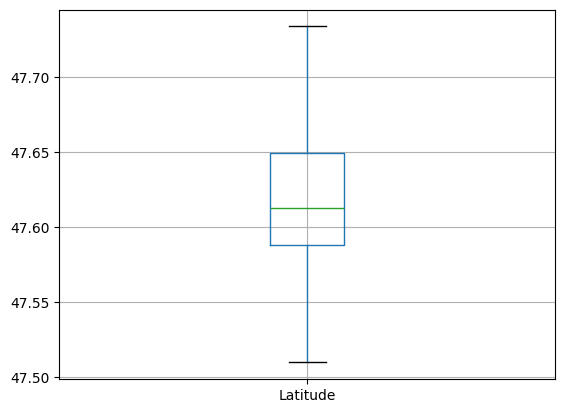

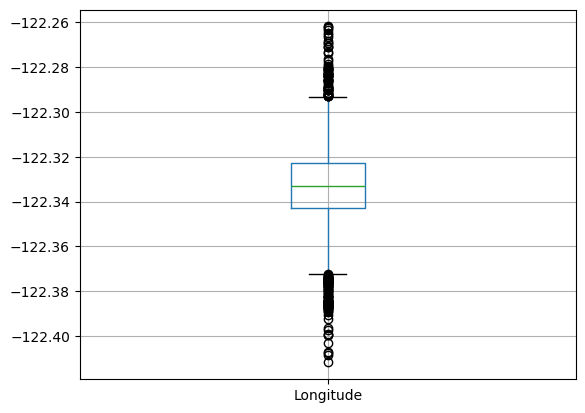

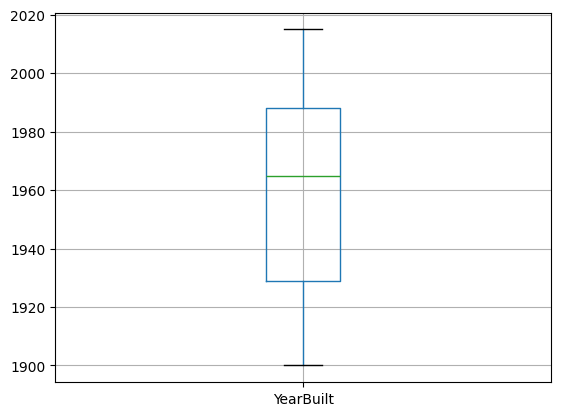

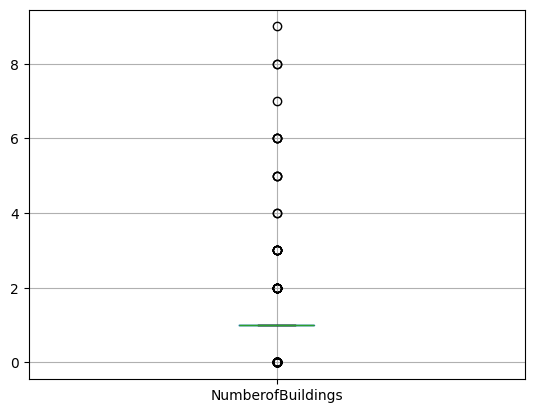

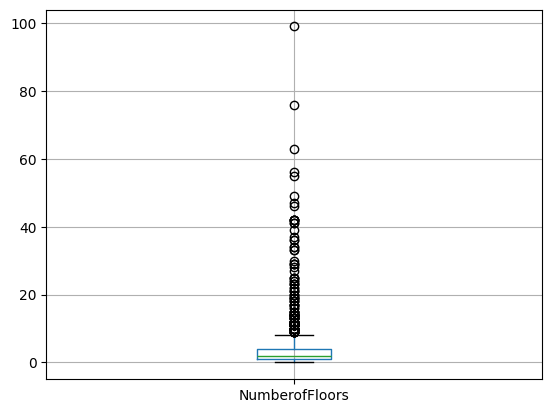

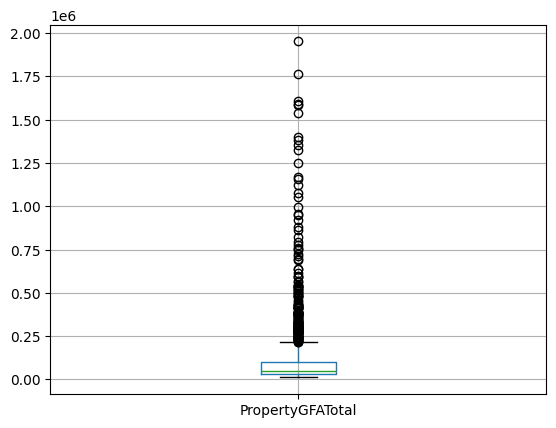

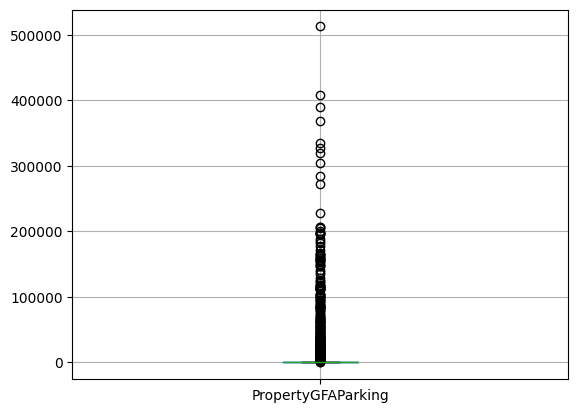

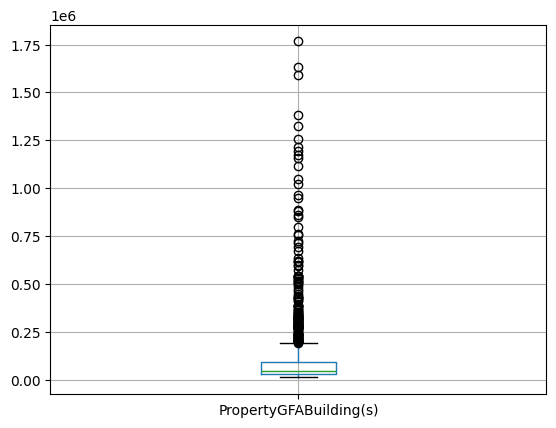

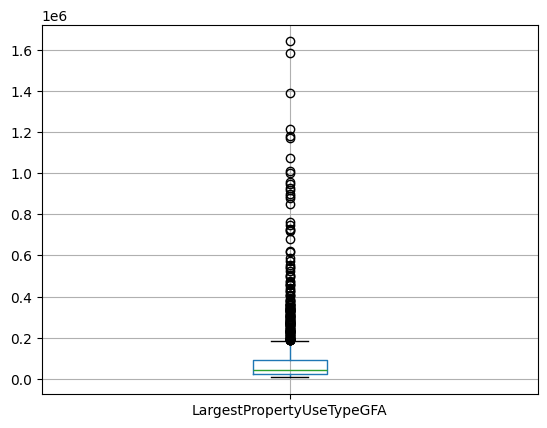

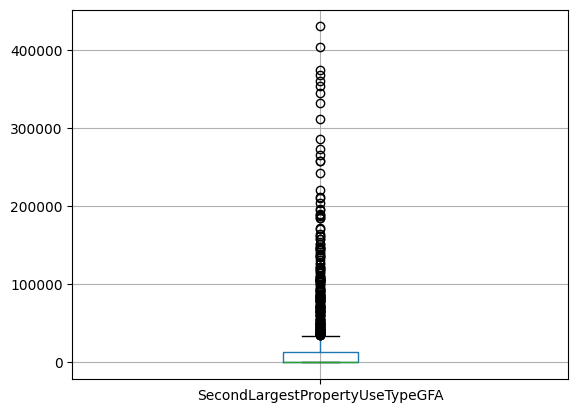

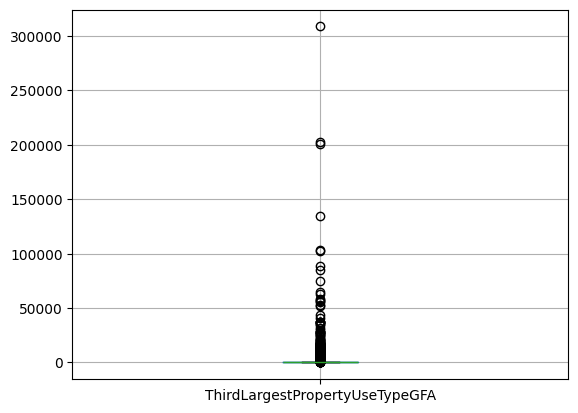

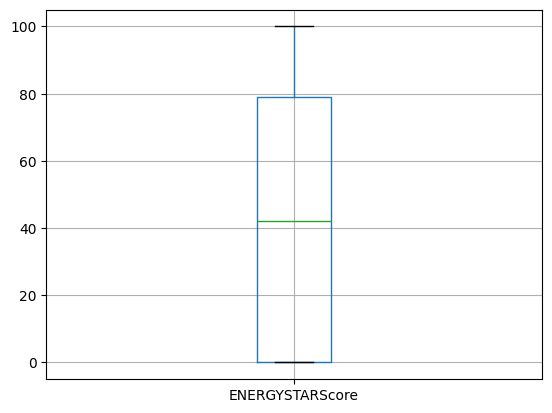

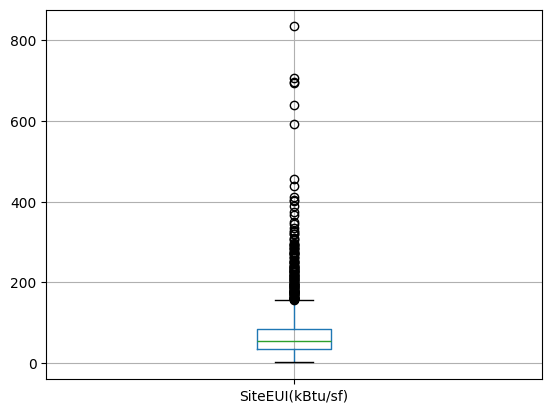

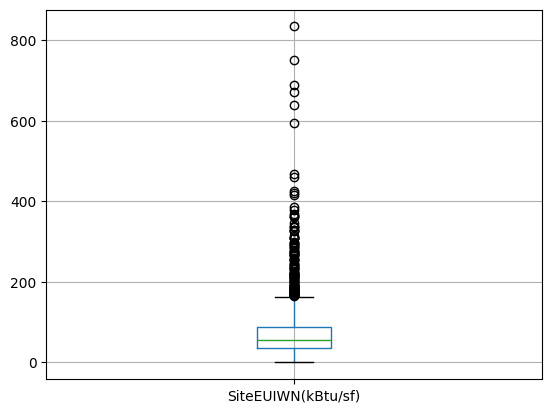

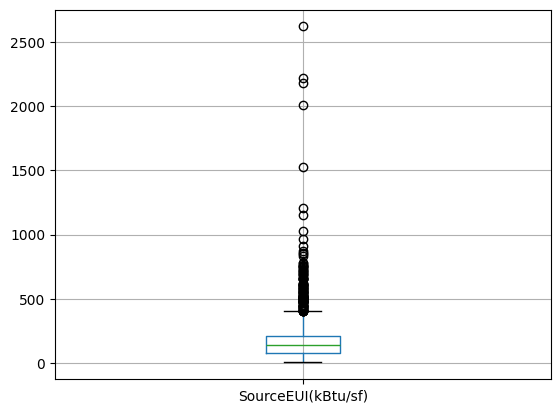

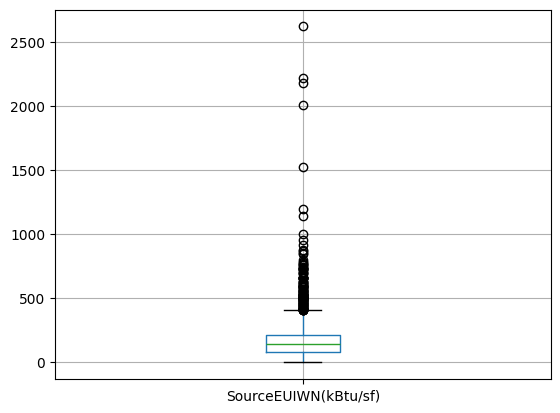

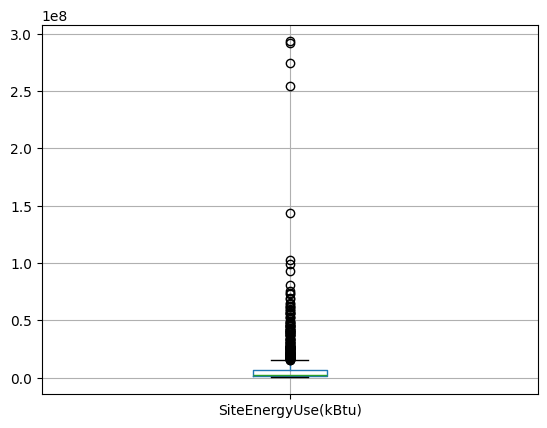

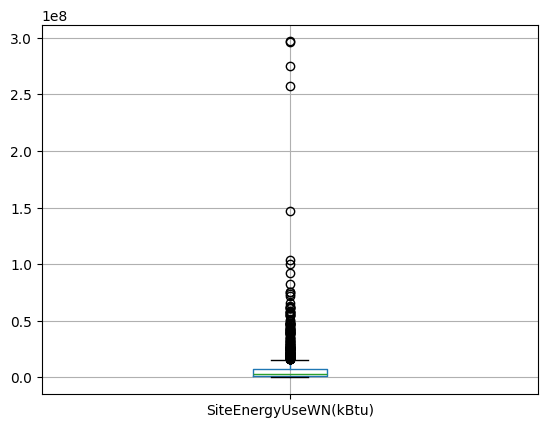

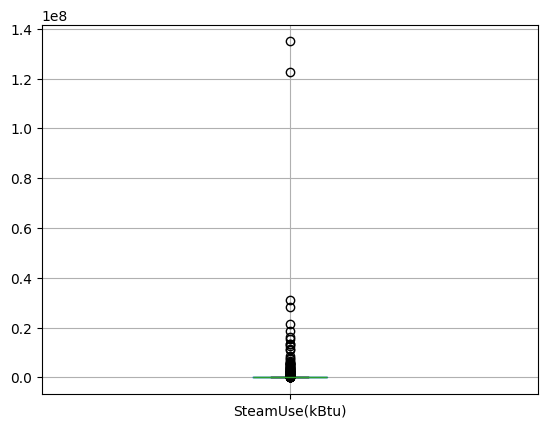

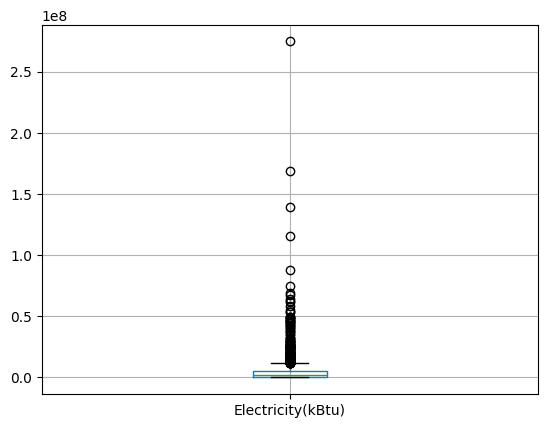

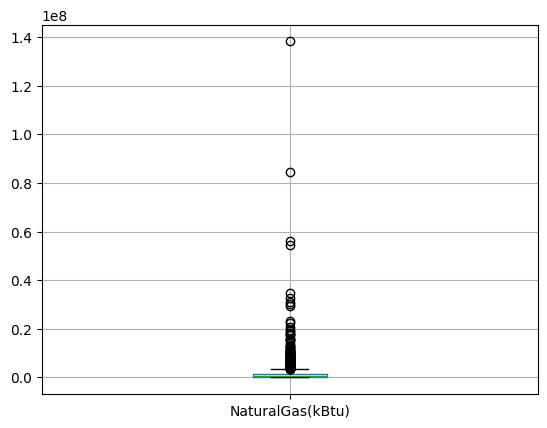

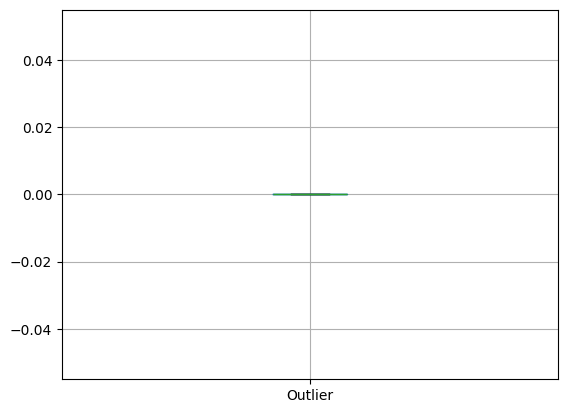

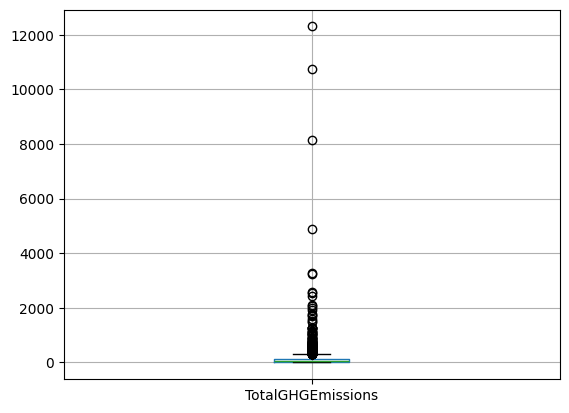

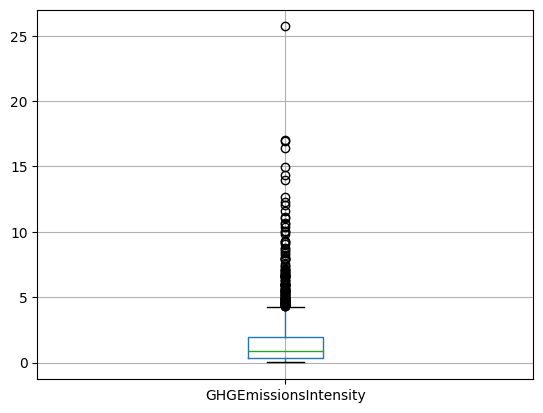

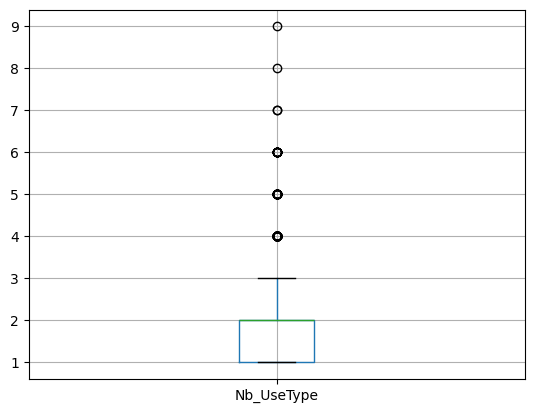

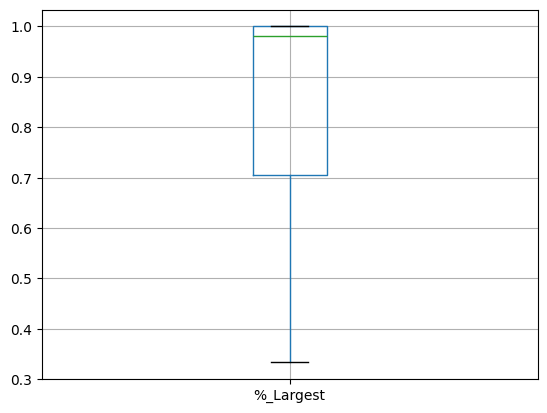

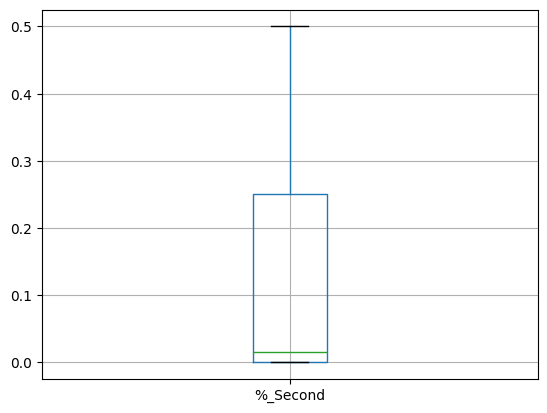

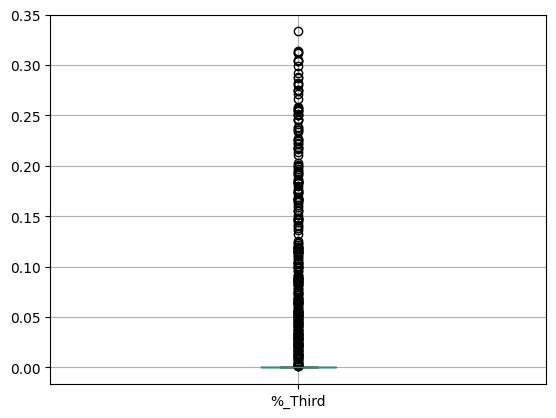

In [174]:
for feat in num_col:
    df_copy.boxplot(column=feat)
    plt.show()

Les boxplots montrent que certaines valeurs ont un autre ordre de grandeur que la majorité du dataset. 

Pour une meilleure lisibilité, nous allons les observer en 2 parties : haute et basse.

### Séparation IQR

In [175]:
col_for_outlier = list(set(num_col).difference(['Latitude', 'Longitude']))
col_for_outlier

['TotalGHGEmissions',
 'YearBuilt',
 'SecondLargestPropertyUseTypeGFA',
 'SiteEnergyUseWN(kBtu)',
 'SourceEUI(kBtu/sf)',
 'PropertyGFATotal',
 'Electricity(kBtu)',
 'GHGEmissionsIntensity',
 '%_Third',
 '%_Largest',
 'NumberofBuildings',
 'LargestPropertyUseTypeGFA',
 'NaturalGas(kBtu)',
 'PropertyGFAParking',
 'NumberofFloors',
 'ENERGYSTARScore',
 'SiteEUIWN(kBtu/sf)',
 'Outlier',
 'SourceEUIWN(kBtu/sf)',
 'SteamUse(kBtu)',
 'PropertyGFABuilding(s)',
 '%_Second',
 'Nb_UseType',
 'SiteEnergyUse(kBtu)',
 'ThirdLargestPropertyUseTypeGFA',
 'SiteEUI(kBtu/sf)']

In [176]:
# Calculate quantiles and IQR for the specified columns
Q1 = df_copy[col_for_outlier].quantile(0.25)
Q3 = df_copy[col_for_outlier].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds for each specified column
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Create a mask for values outside the IQR range for each specified column
IQR_mask = ((df_copy[col_for_outlier] < lower_bound) | (df_copy[col_for_outlier] > upper_bound)).any(axis=1)

# Apply the mask to create a DataFrame with outliers
df_outliers = df_copy[IQR_mask]
print(df_outliers.shape)
print(df_copy.shape)

(739, 42)
(1407, 42)


Ce jeu de données contient environ une moitié d'individus avec au moins une valeur considérées comme étant extrêmes selon la méthode IQR. 
Par exemple, tous les batiments de plus de 8 étages sont considérés comme extrêmes.
Nous pourrions découper notre jeu de données en 2 dataframes : 
- un avec des valeurs dites basse ou normale
- un avec des valeurs plus élevées

Nous allons le découper, uiquement pour la visualisation, tout en gardant le dataframe initial.

In [177]:
# Create a DataFrame with outliers
df_high = df_copy[IQR_mask].copy() #Dataframe containing only outliers
df_low = df_copy[~IQR_mask].copy() #Dataframe containing no outliers
df_all = df_copy.copy() 

print(df_high.shape)
print(df_low.shape)
print(df_all.shape)

(739, 42)
(668, 42)
(1407, 42)


Observons les séparément :

### Valeurs basses

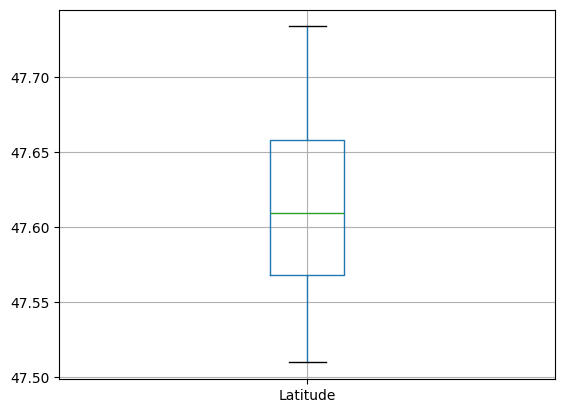

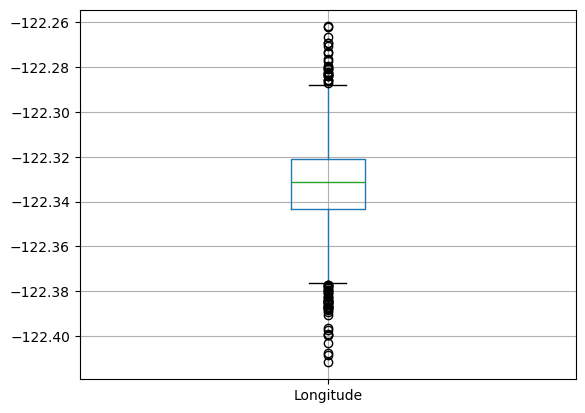

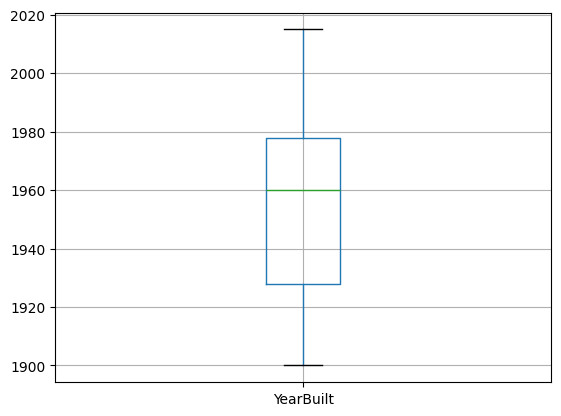

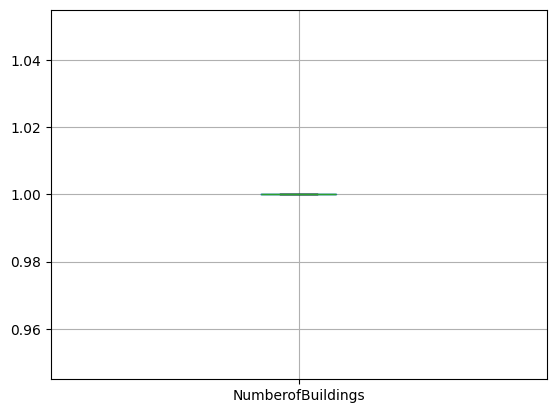

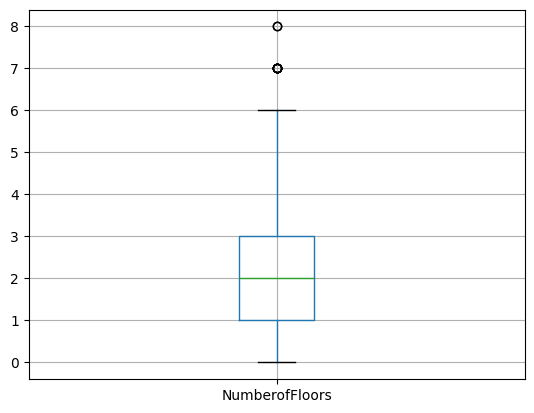

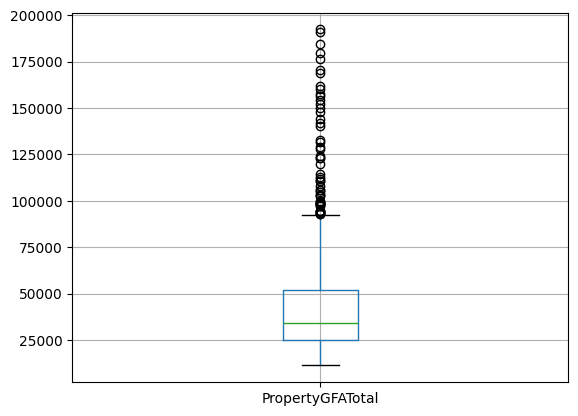

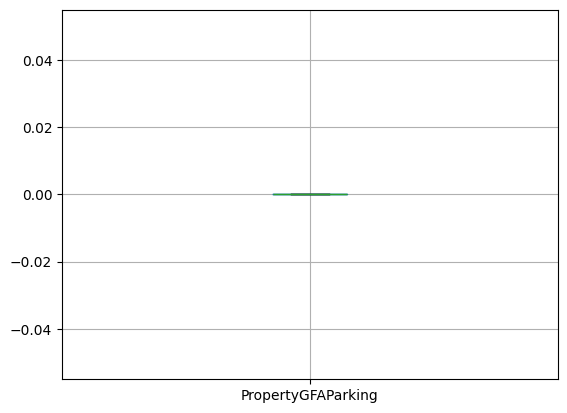

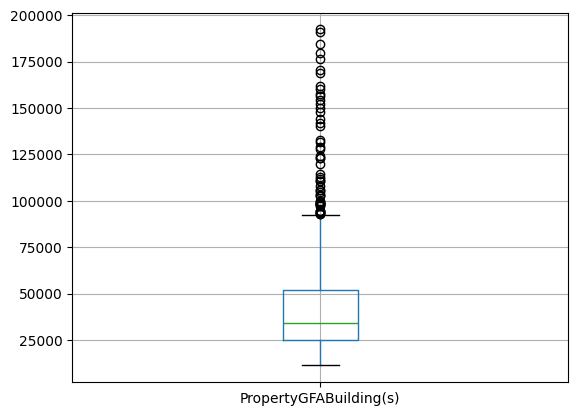

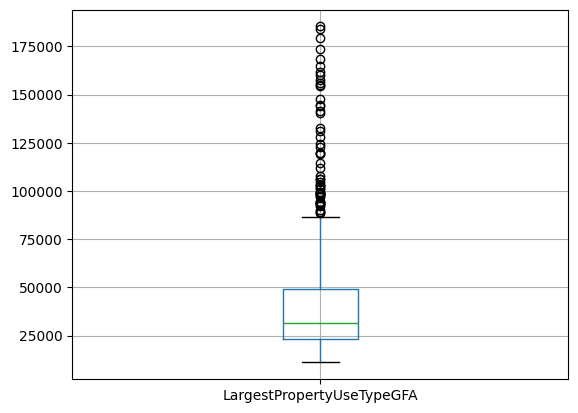

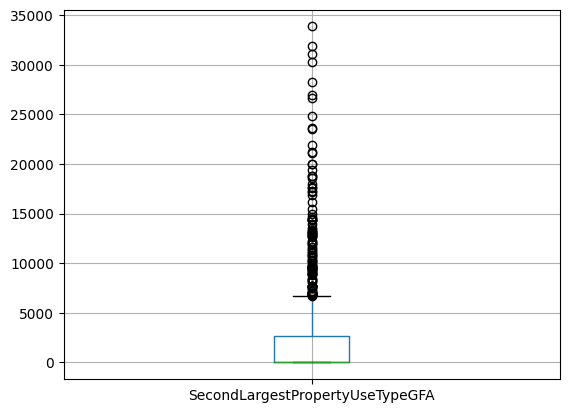

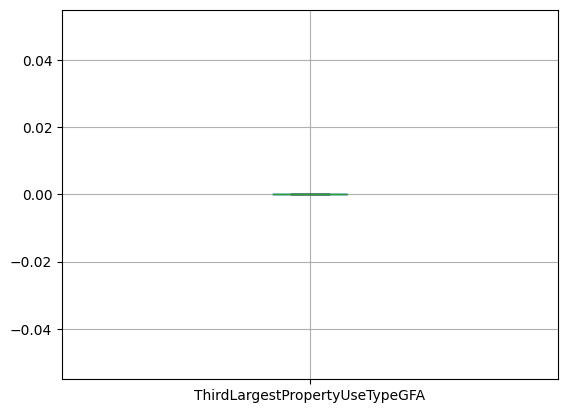

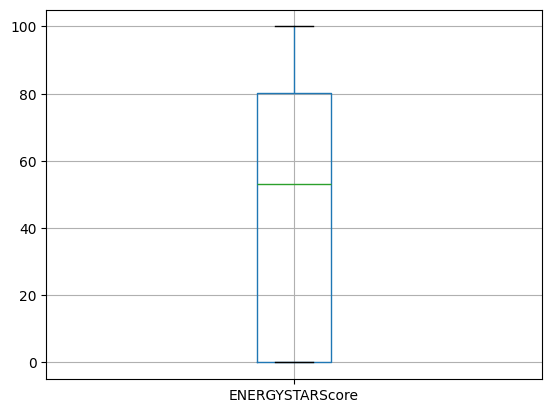

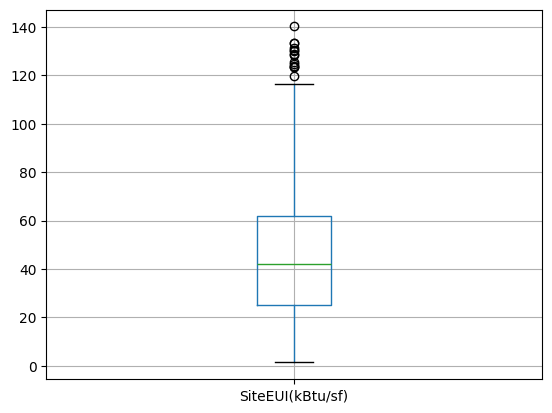

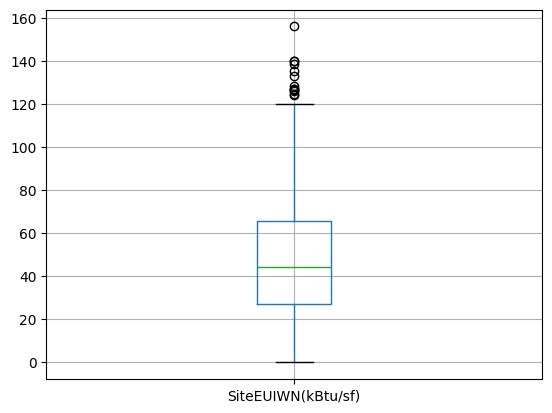

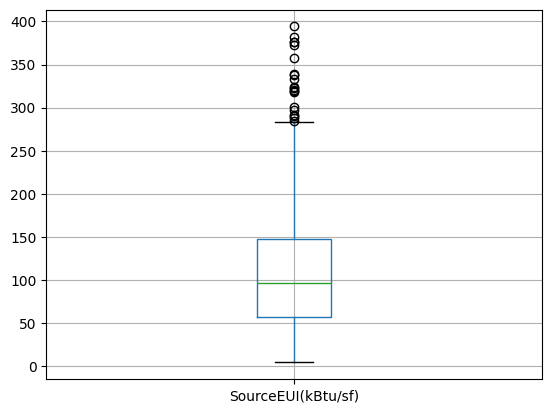

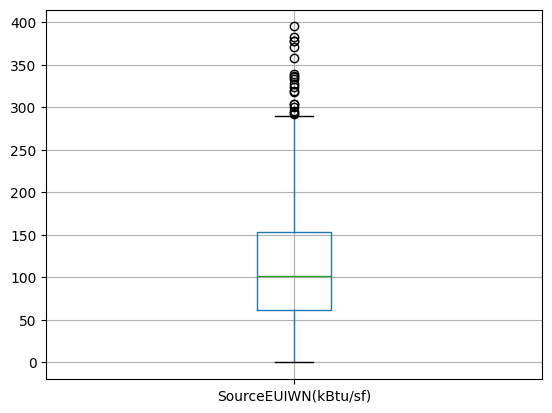

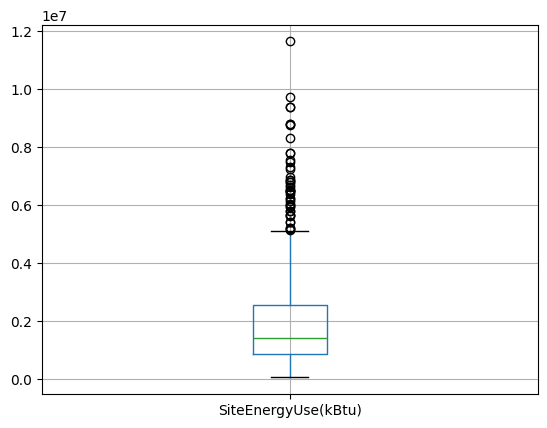

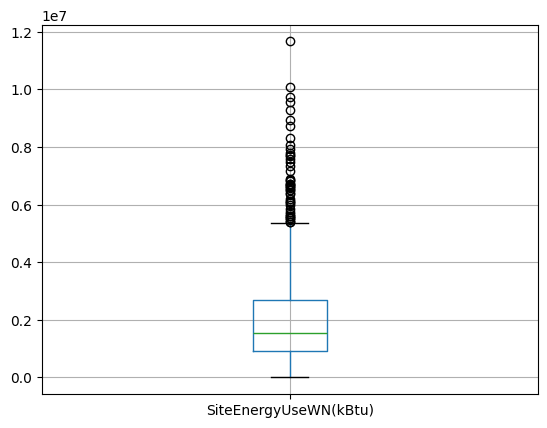

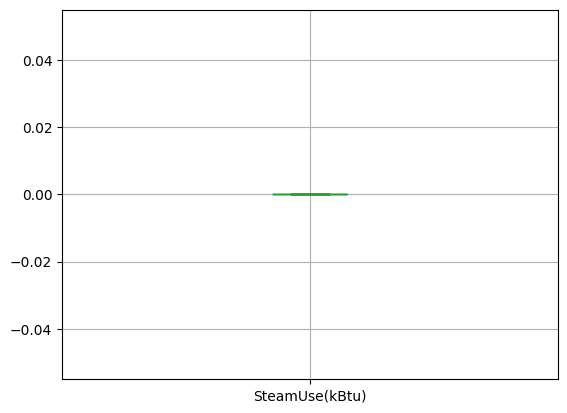

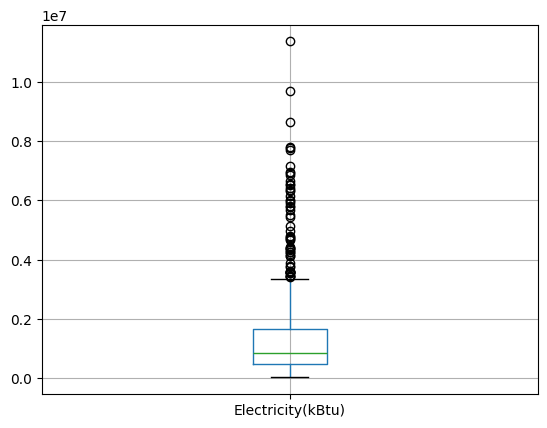

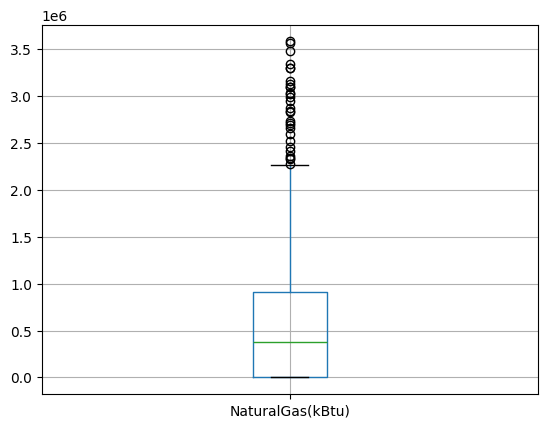

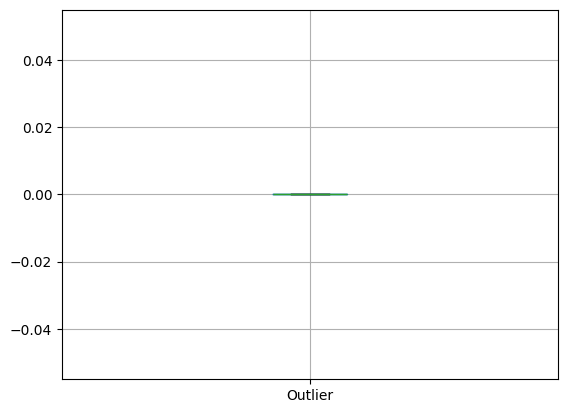

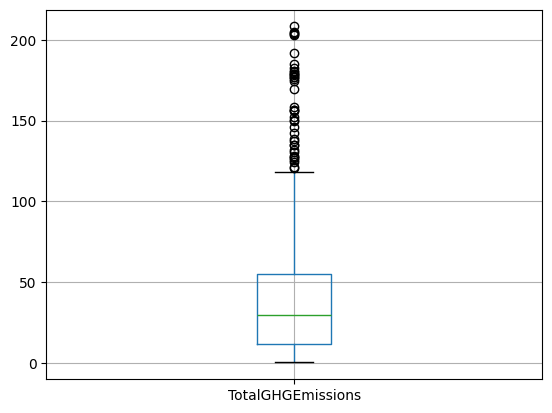

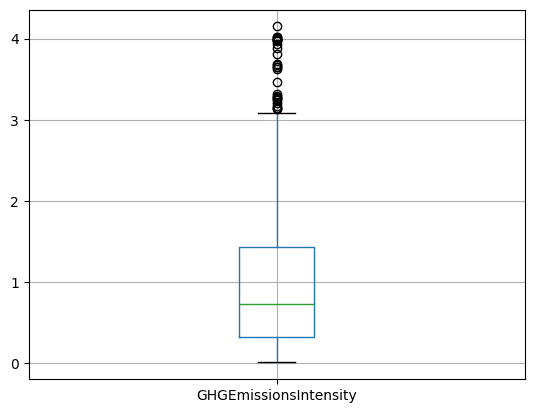

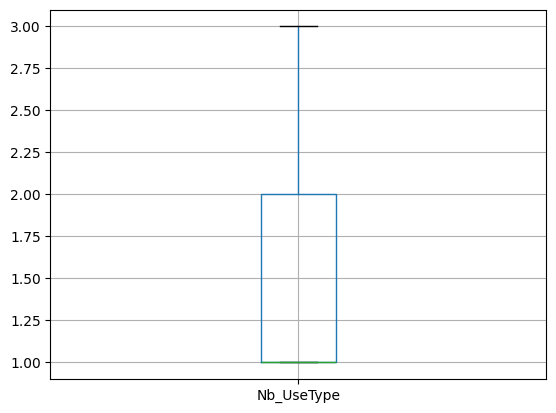

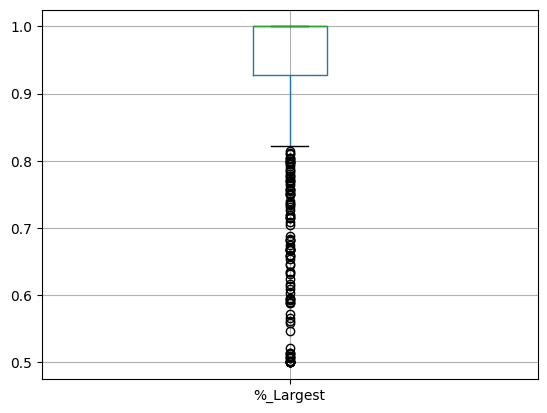

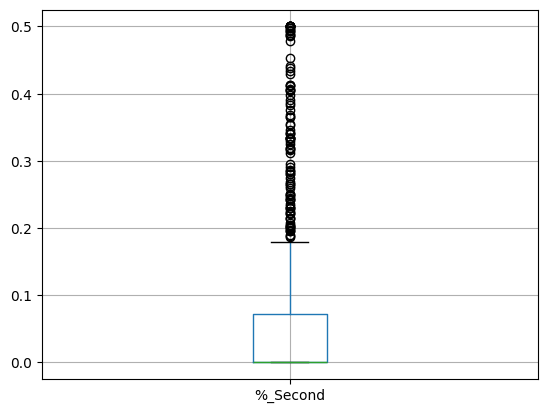

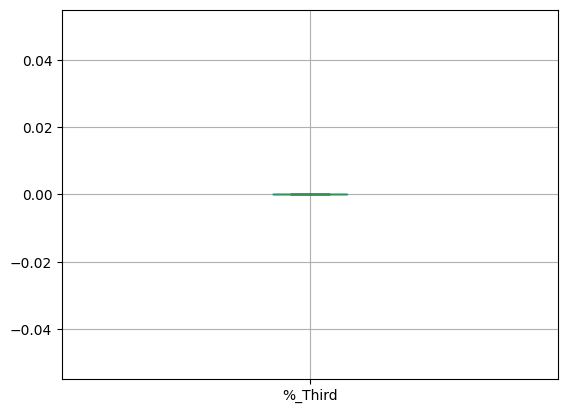

In [178]:
for feat in df_low[num_col].columns:
    df_low.boxplot(column=feat)
    plt.show()

Nous tournons autour des années 1930 à 1980.
Nous n'avons pas de parkings ni d'usage de vapeurs dans ce jeu de données.
La plupart n'ont qu'un seul usage, aucun n'a de 3ème, tous ont une superficie de moins de 100k pieds carrés.
Les batiments font 8 étages ou moins.


### Valeurs hautes

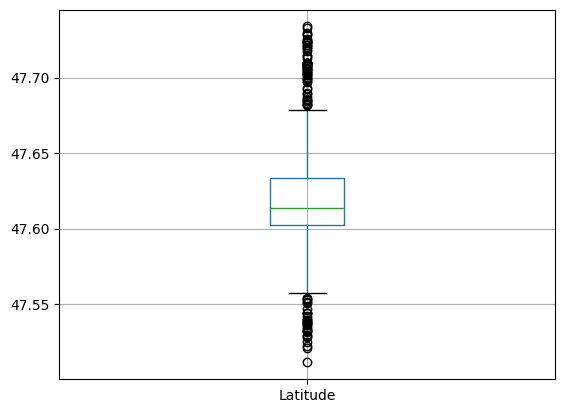

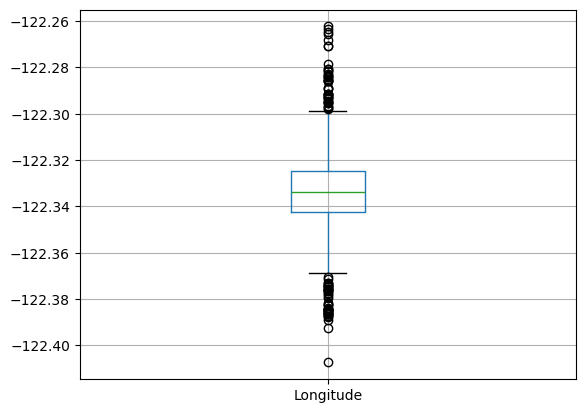

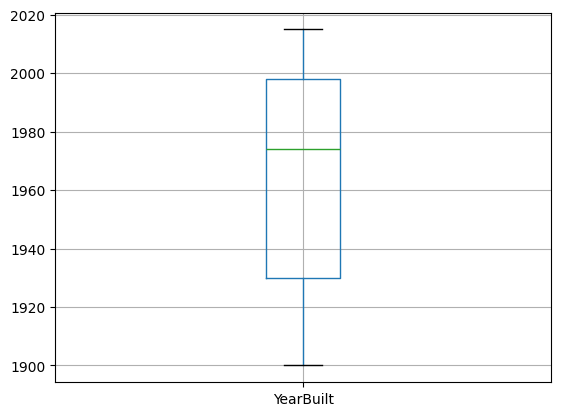

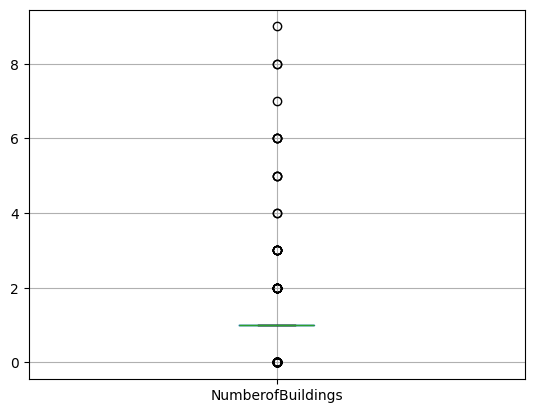

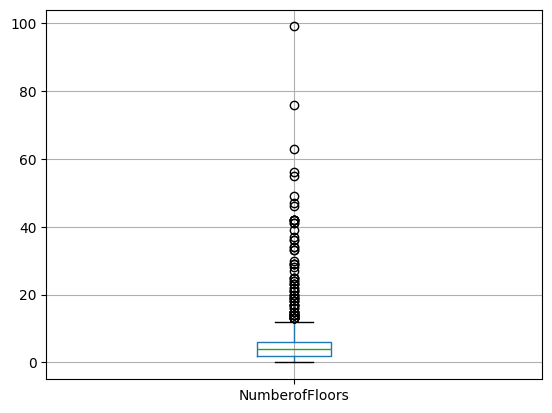

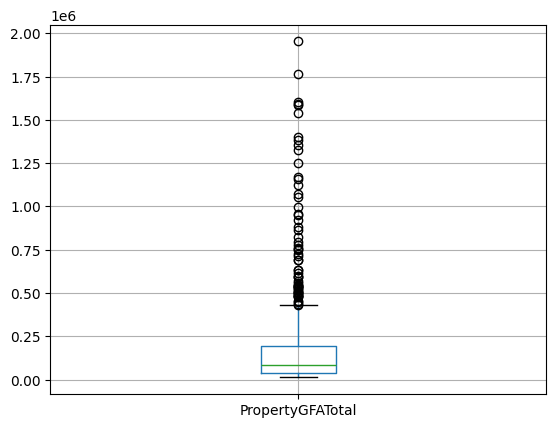

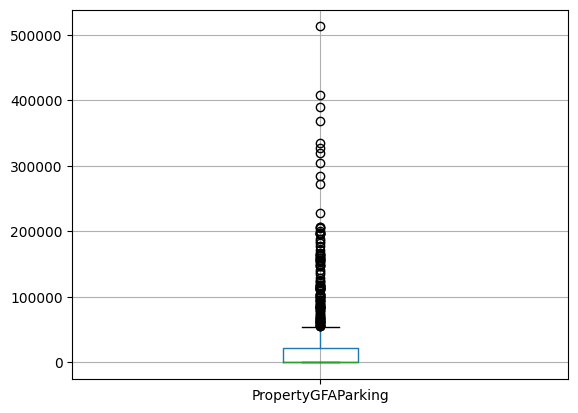

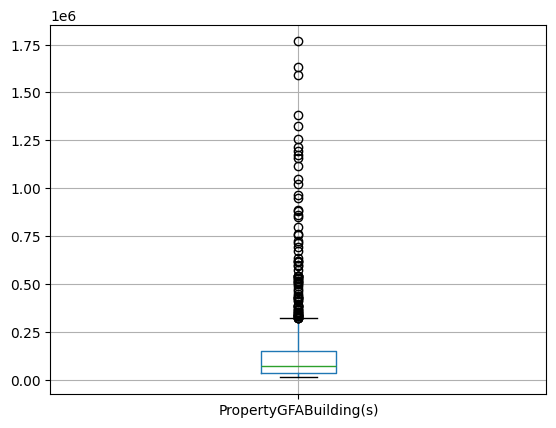

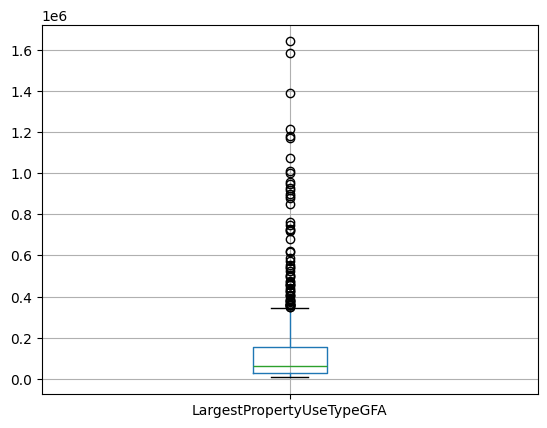

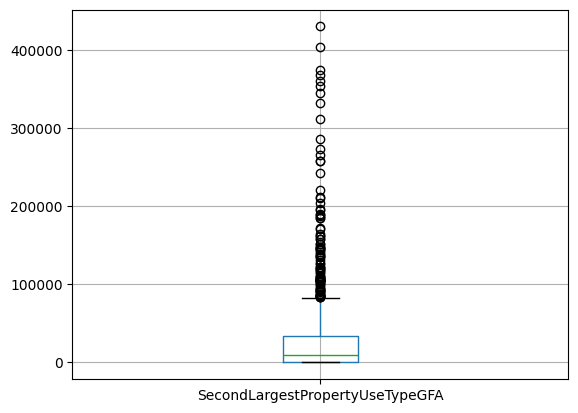

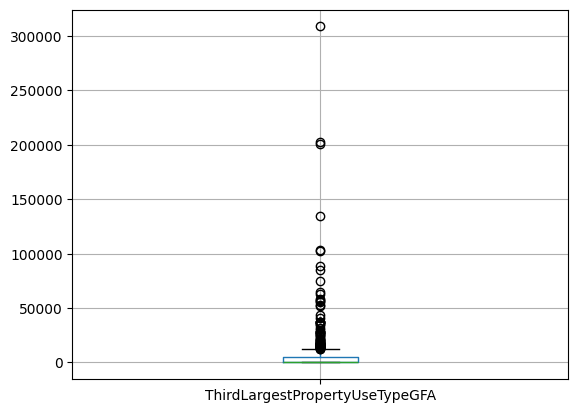

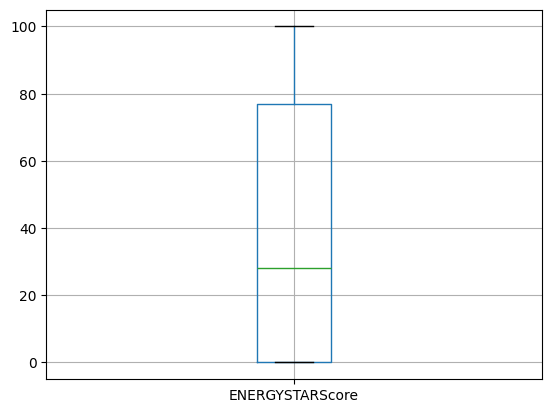

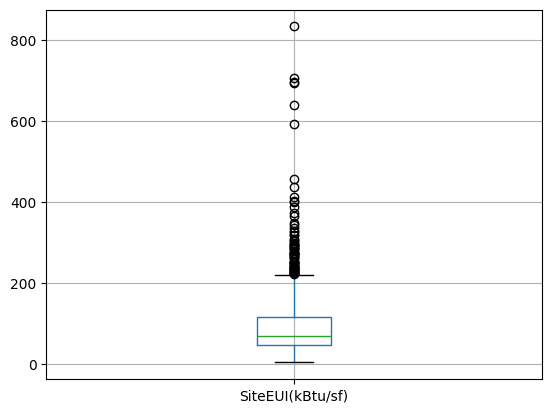

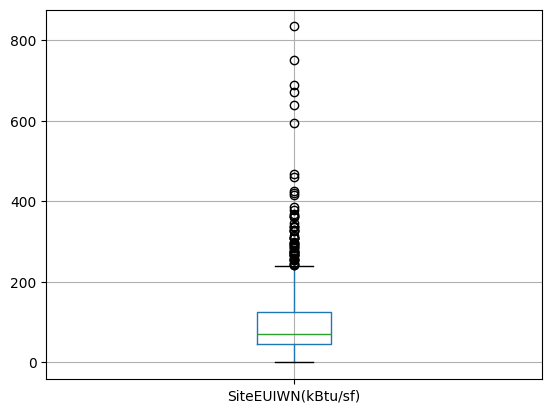

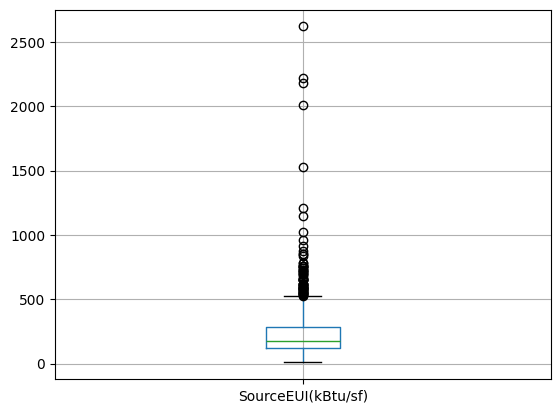

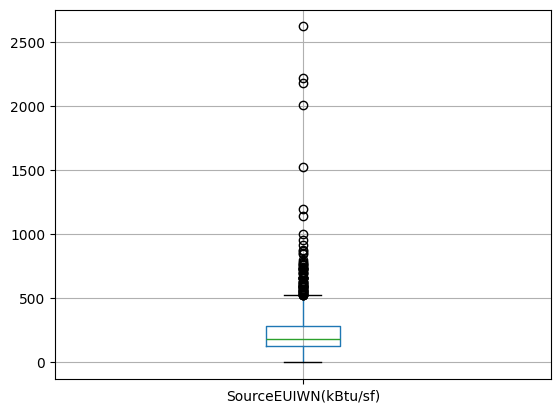

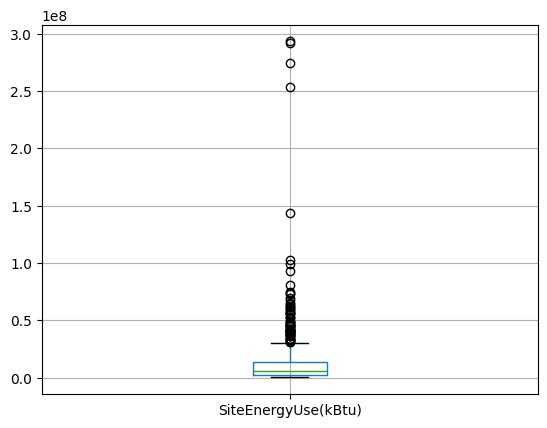

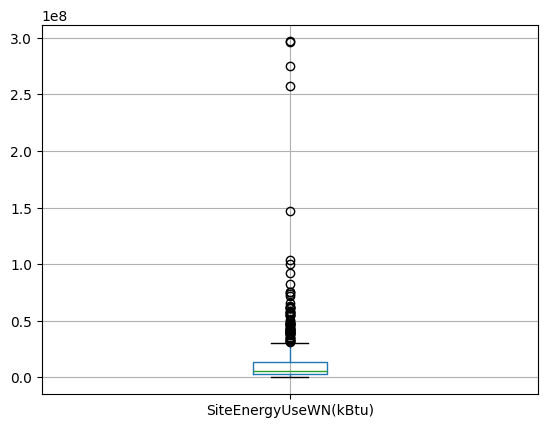

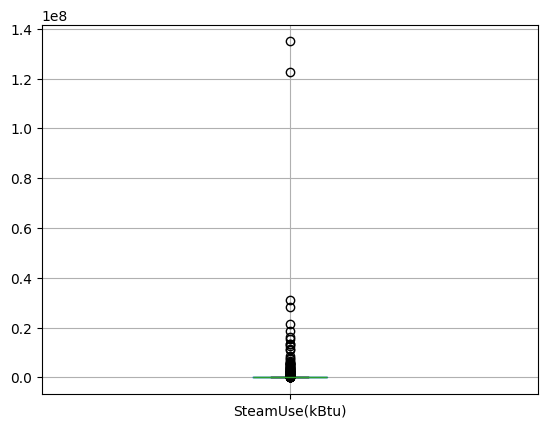

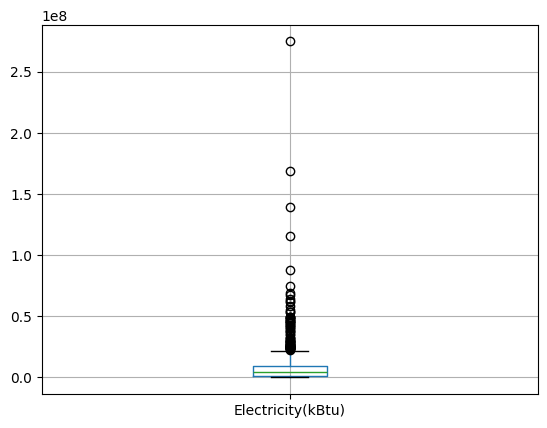

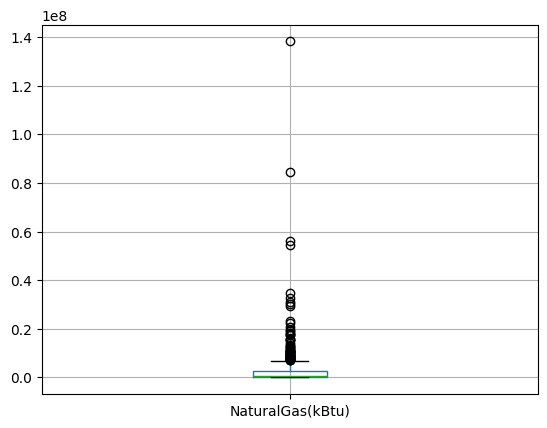

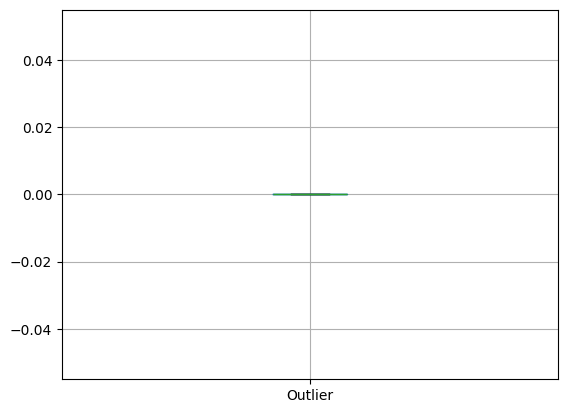

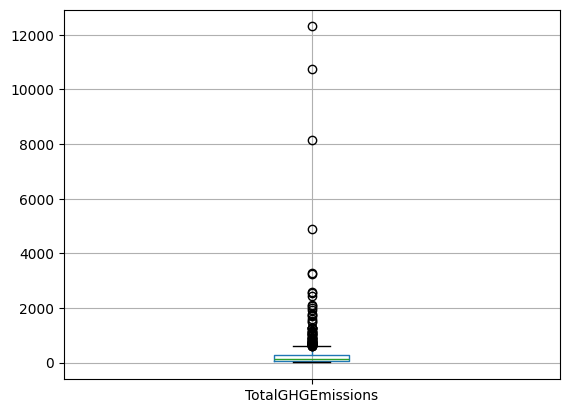

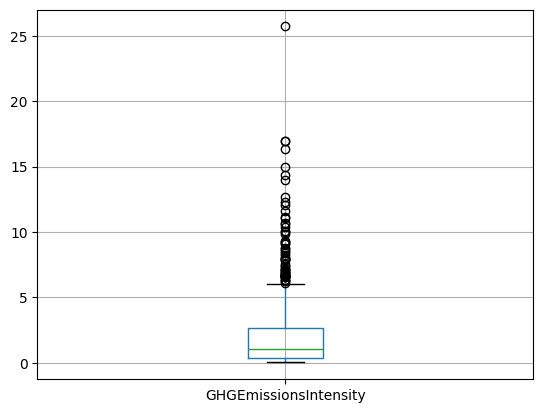

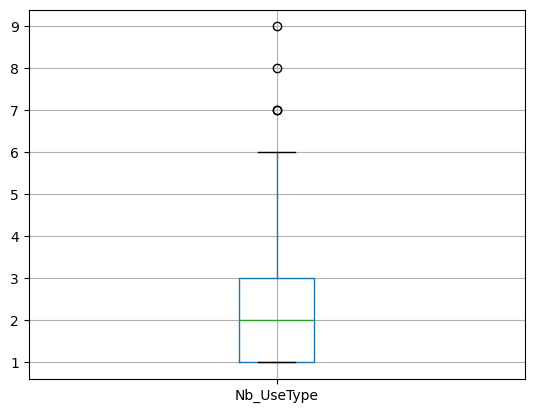

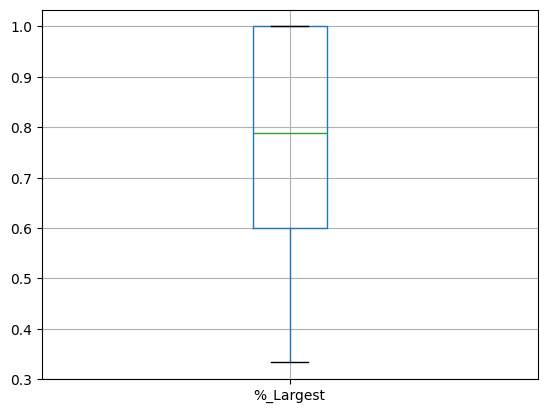

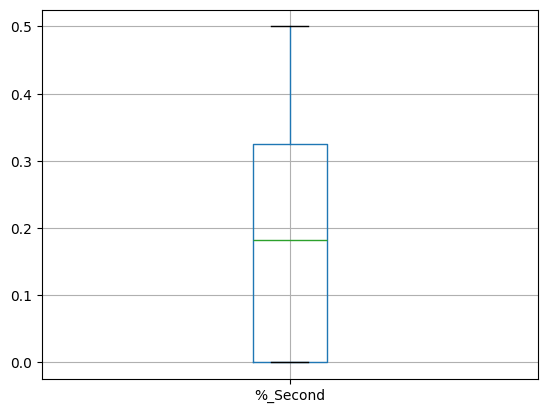

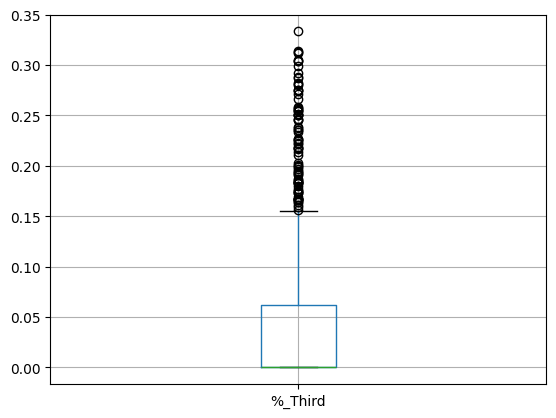

In [179]:
for feat in df_high[num_col].columns:
    df_high.boxplot(column=feat)
    plt.show()

Ces batiments sont plus récents, les ordres de grandeur sont généralement multipliés par 10. 
2 jeu de données plus différents dans les valeurs que dans la répartition de celles-ci.

## 3.3. Suppression de valeurs extrêmes 

Nous supprimons uniquement les batiments à taille et/ou consommation très extrême : 

In [180]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import remove_z_outlier
num_col_z = list(set(num_col).difference(['Latitude', 'Longitude']))


df_copy_z_out = remove_z_outlier(df_copy, num_col=num_col_z)
print(df_copy_z_out.shape)
print(df_copy.shape)

Number of total outliers = 191
(1216, 42)
(1407, 42)


Pour ce cas d'étude, je préfère écarter 1% des valeurs les plus extrêmes pour certaines colonnes : nos 2 cibles, les autres variables de consommation, la surface totale, le nb de batiment et le nb d'étage.

In [181]:
df_copy.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)',
       'NaturalGas(kBtu)', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsIntensity', 'Nb_UseType', '%_Largest', '%_Second',
       '%_Third'],
      dtype='objec

In [182]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import remove_1percent_outliers

num_col_1p = ['NumberofBuildings', 'NumberofFloors','PropertyGFATotal','SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)','SiteEnergyUseWN(kBtu)']

df_copy_clean = remove_1percent_outliers(df_copy, num_col=num_col_1p)
print(df_copy_clean.shape)
print(df_copy.shape)

Number of total outliers = 55
(1352, 42)
(1407, 42)


Nous allons travailler avec 1451 lignes de 42 colonnes.

# 4. Analyse descriptive

## 4.1. Univariée

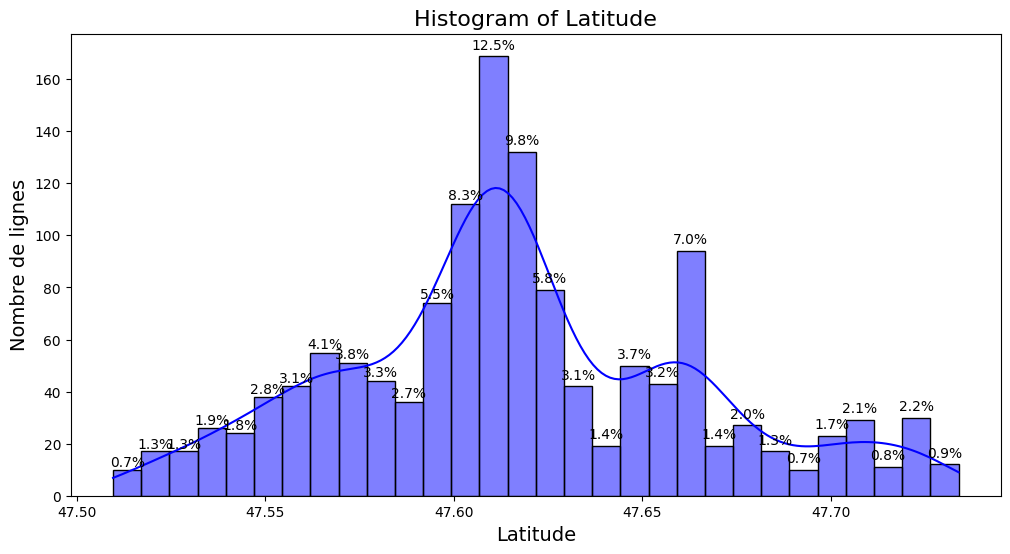

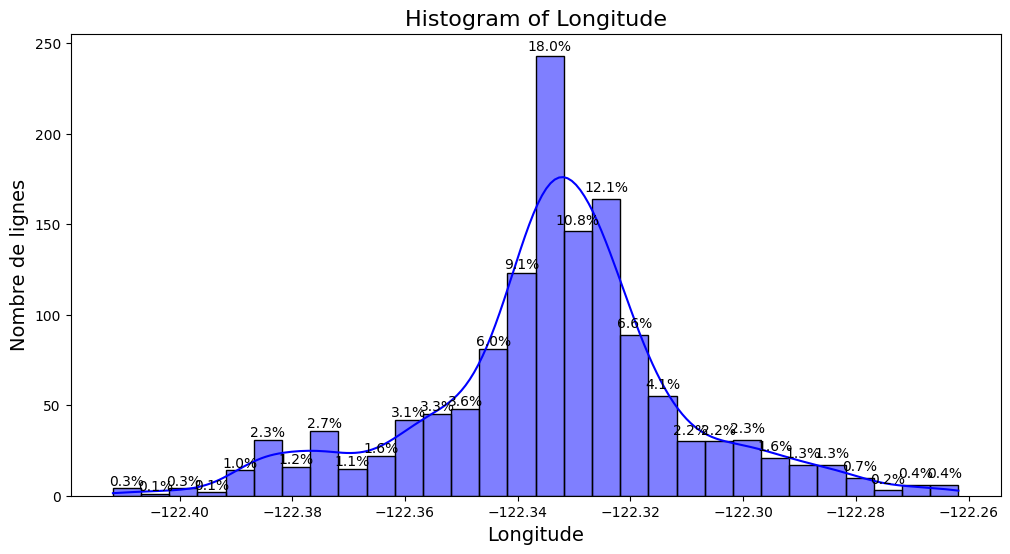

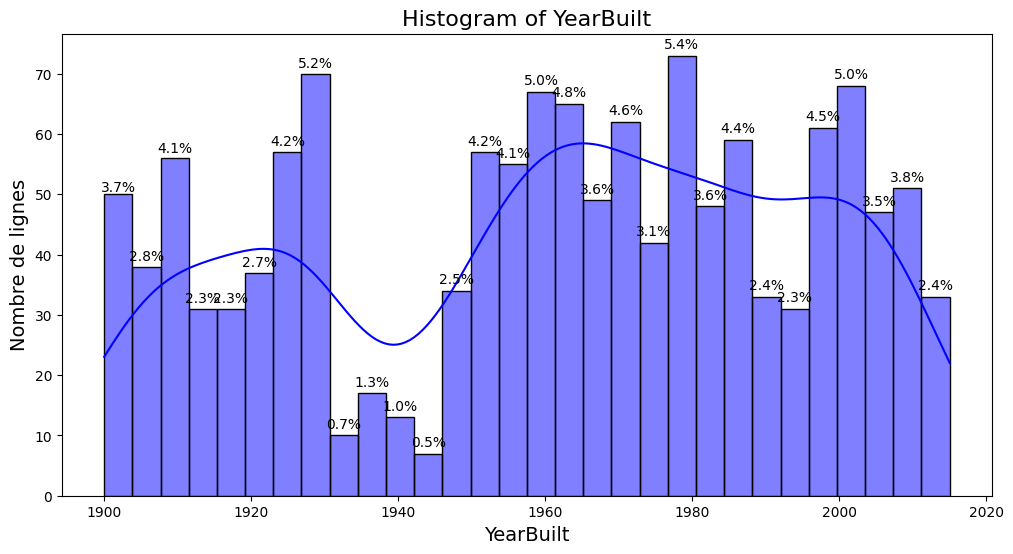

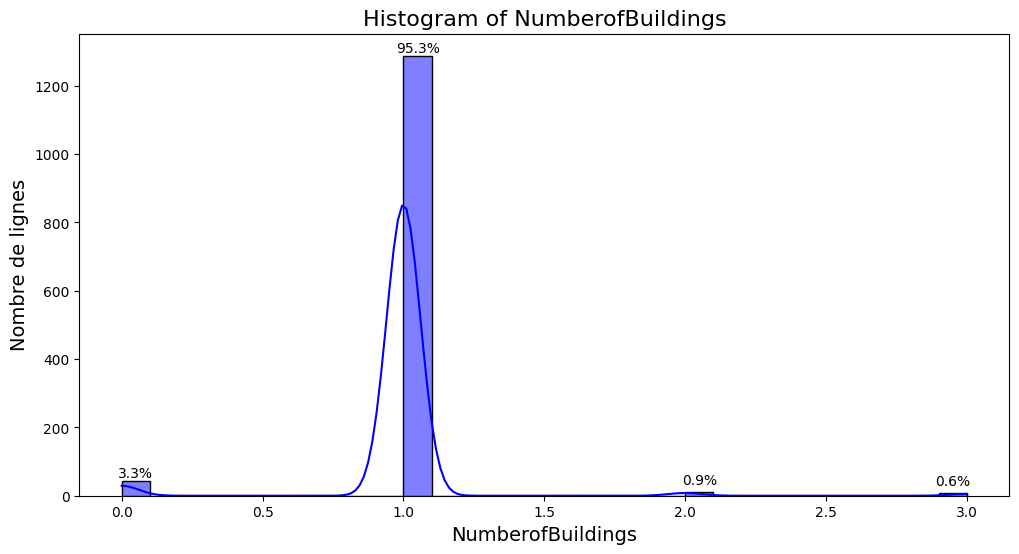

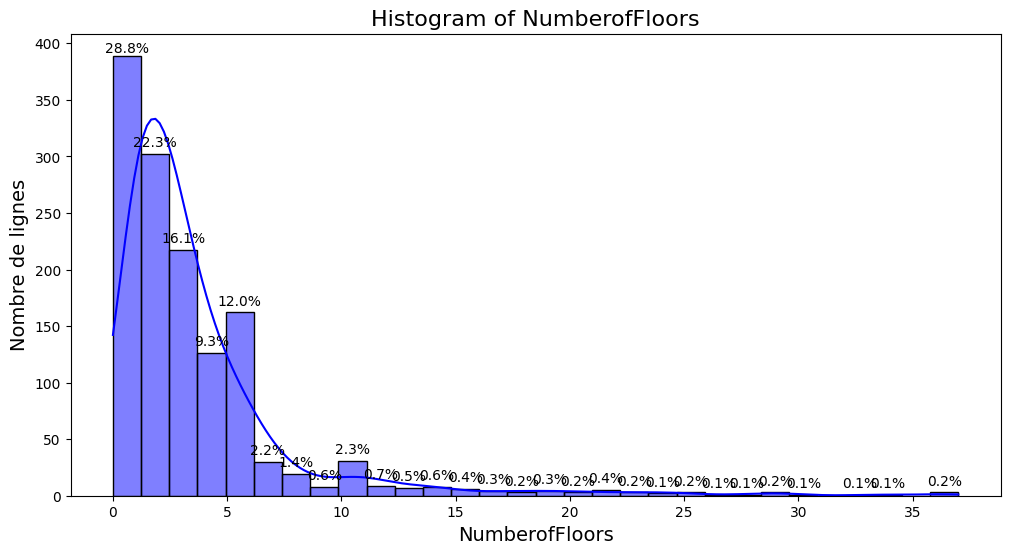

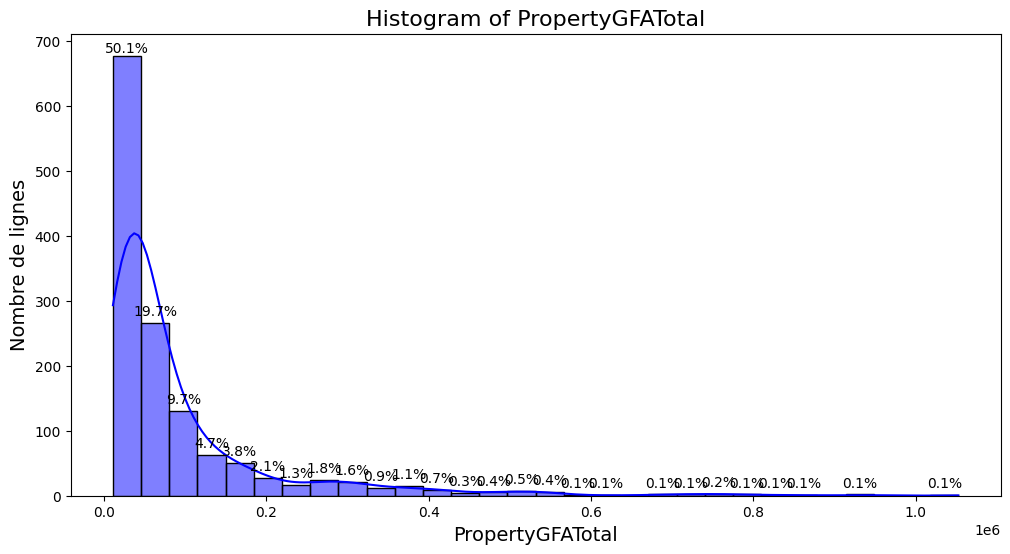

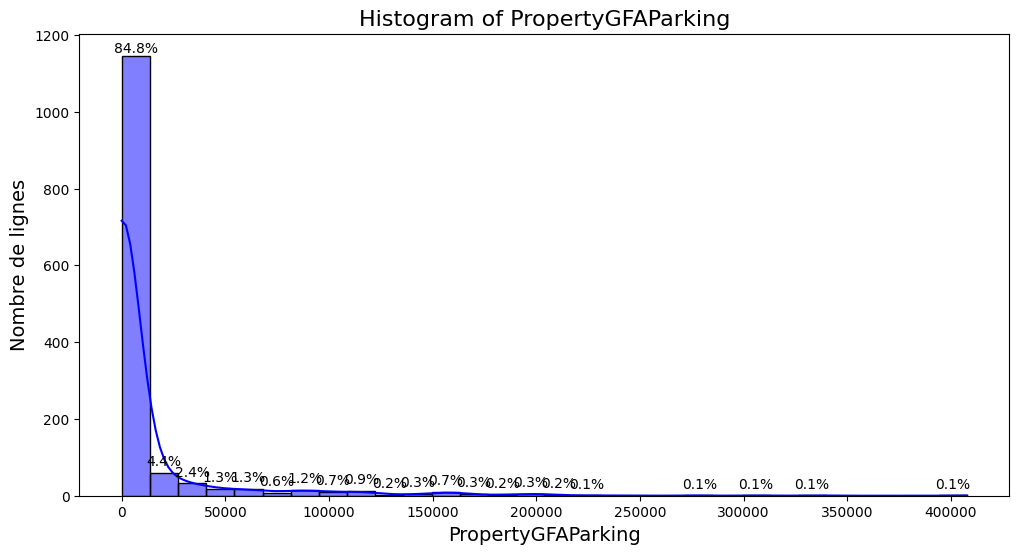

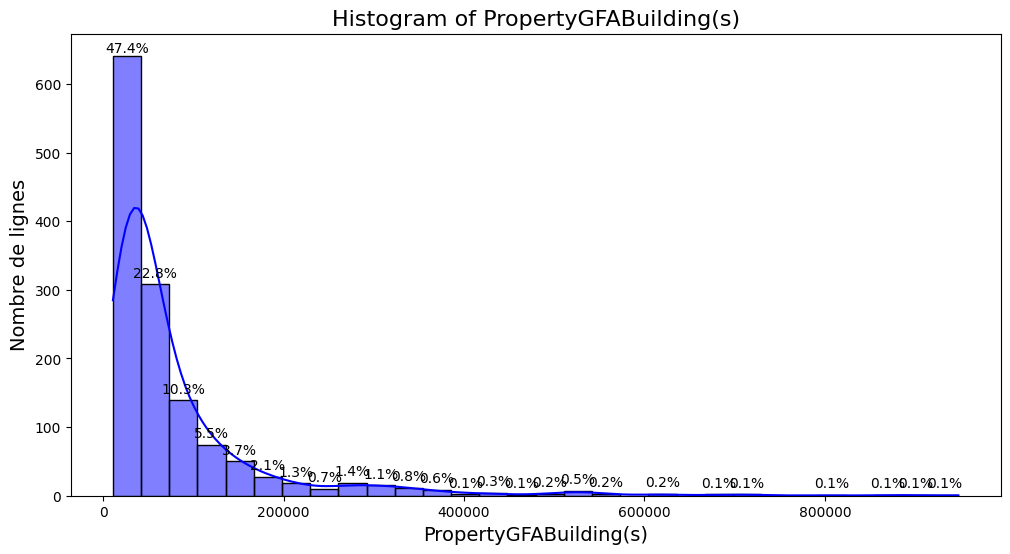

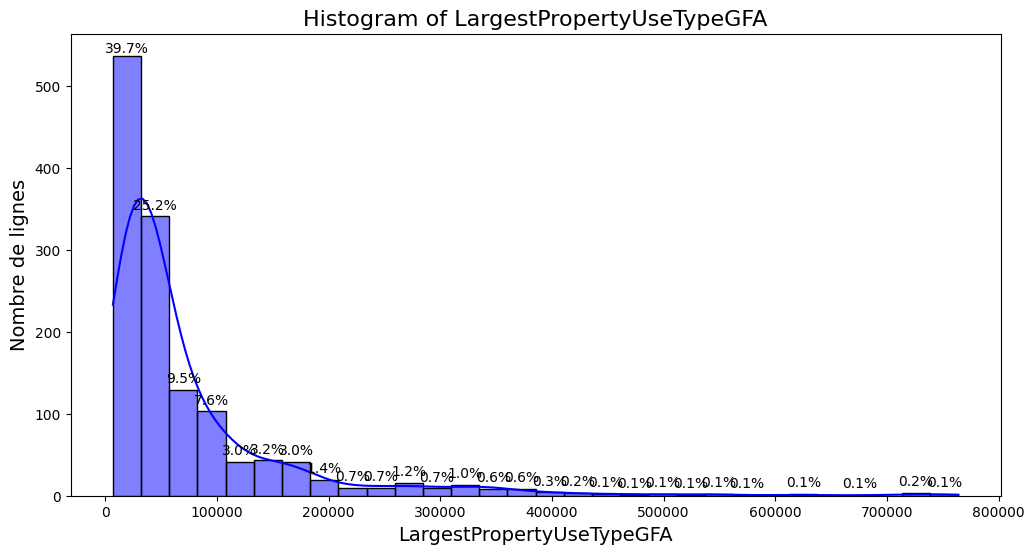

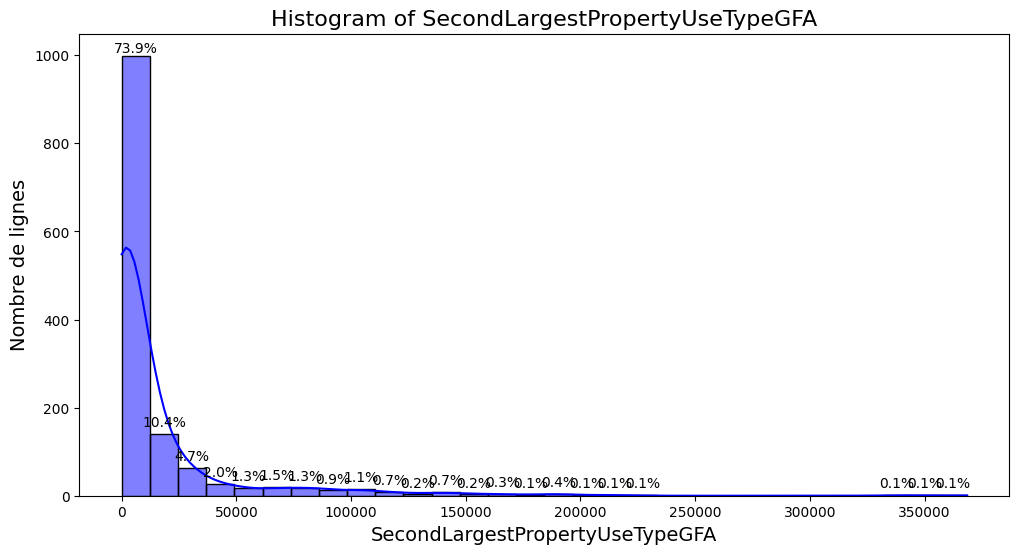

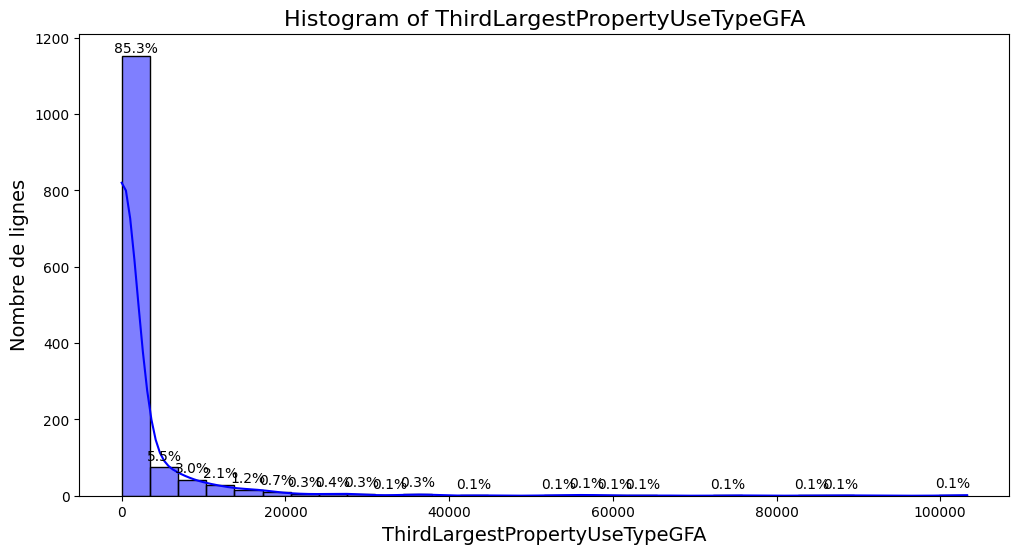

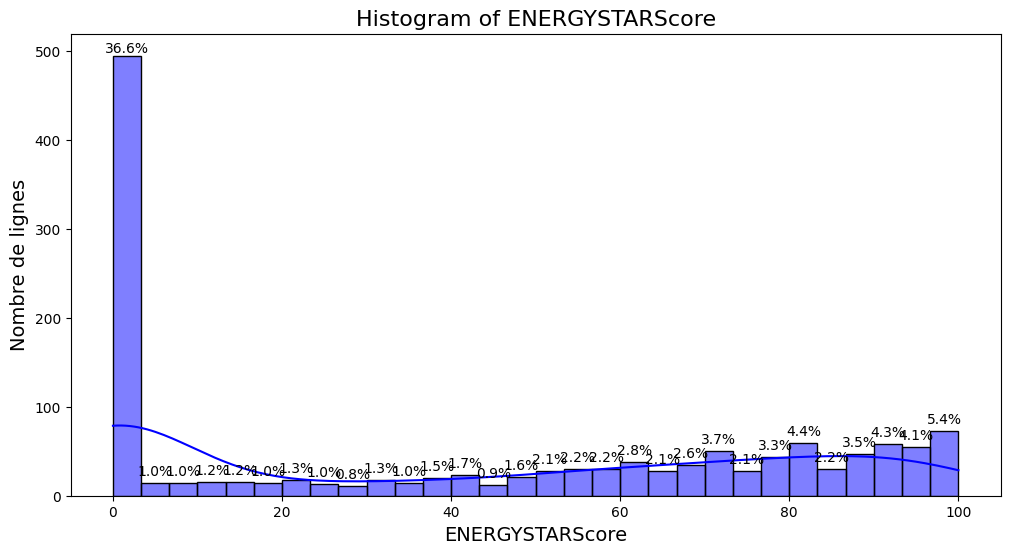

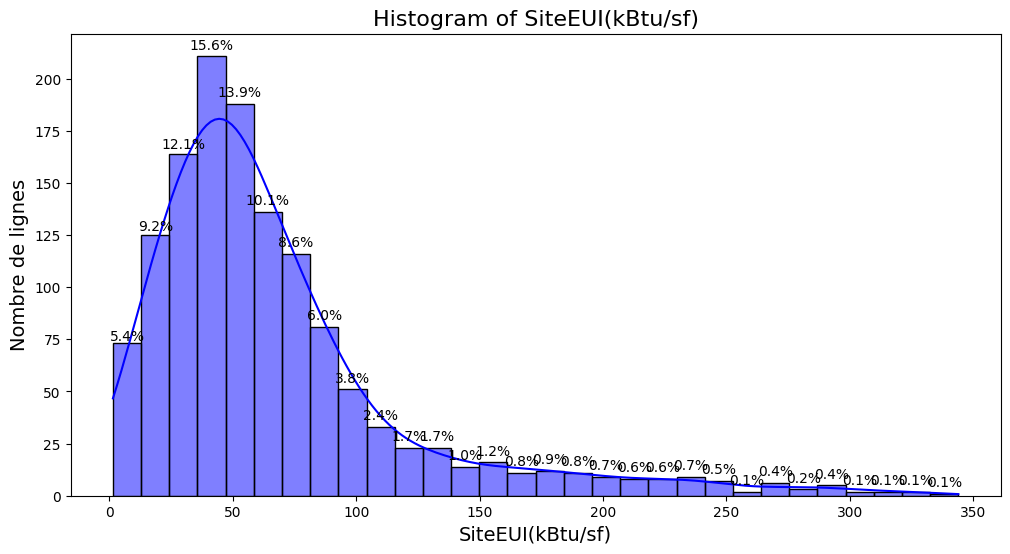

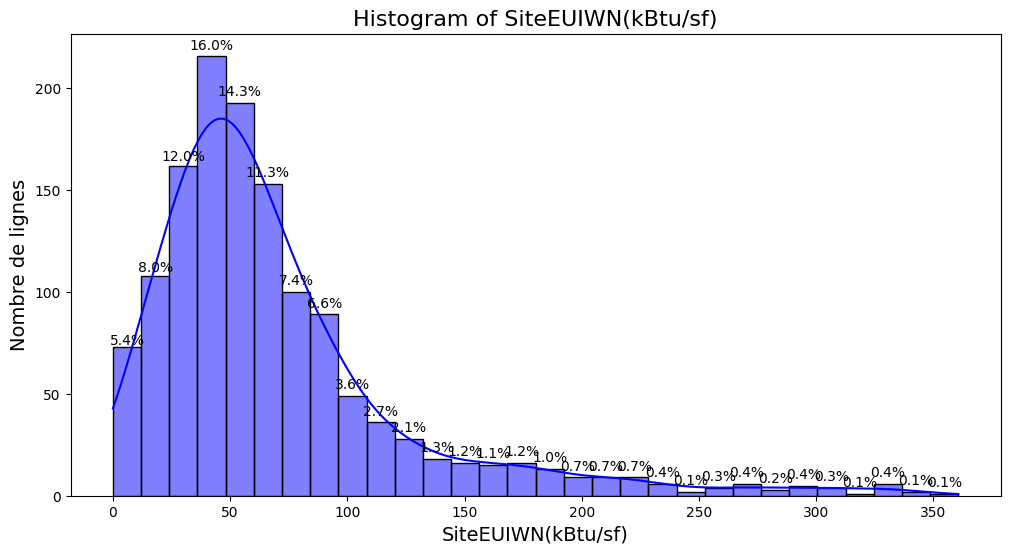

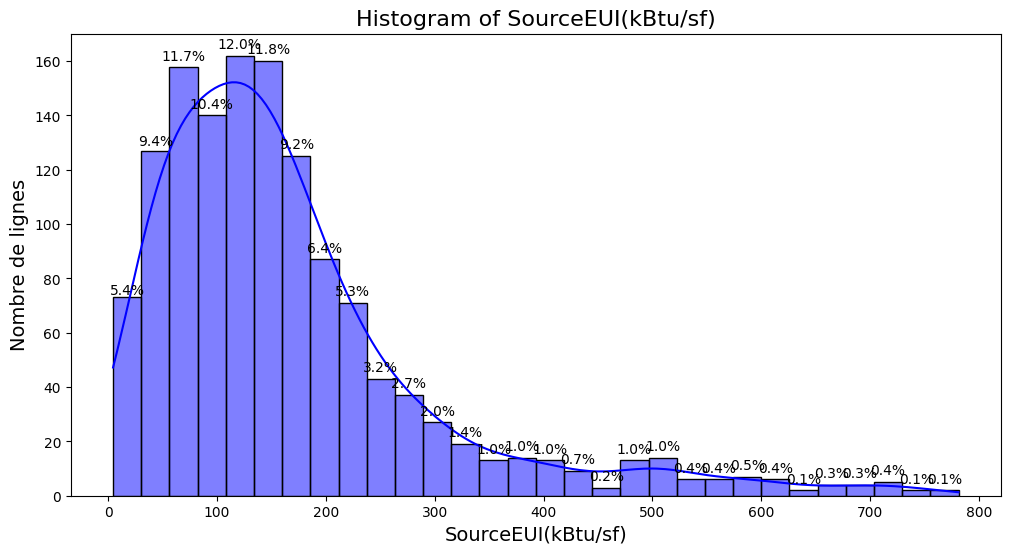

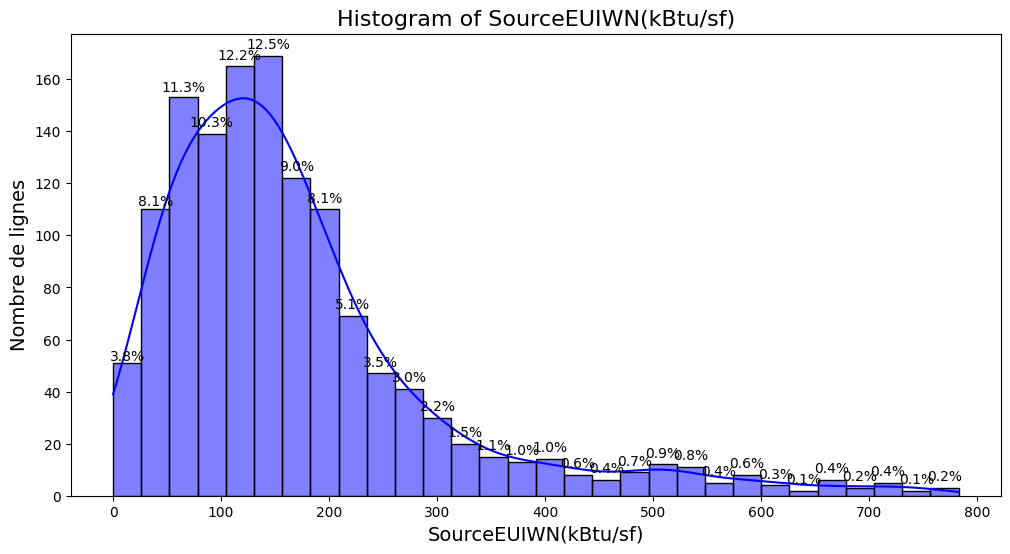

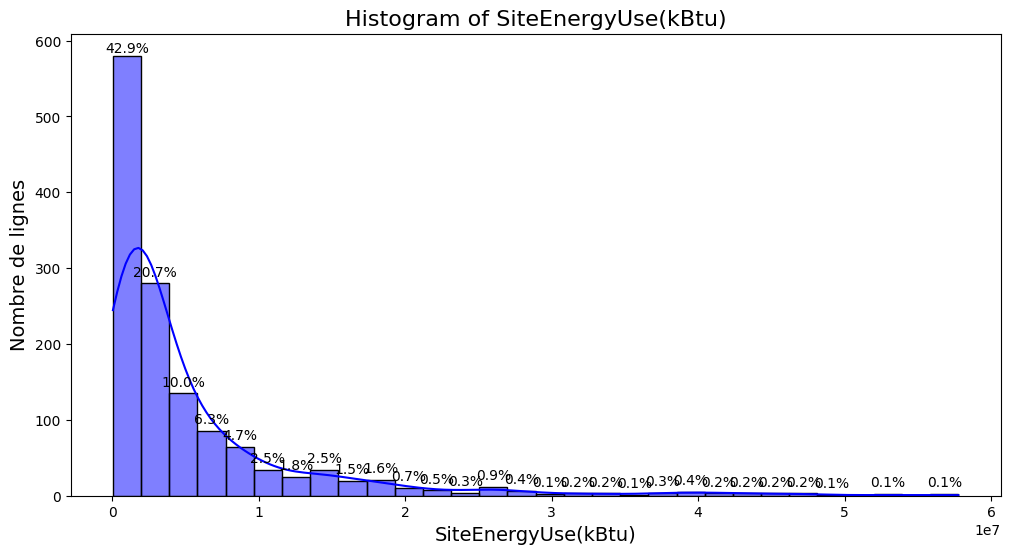

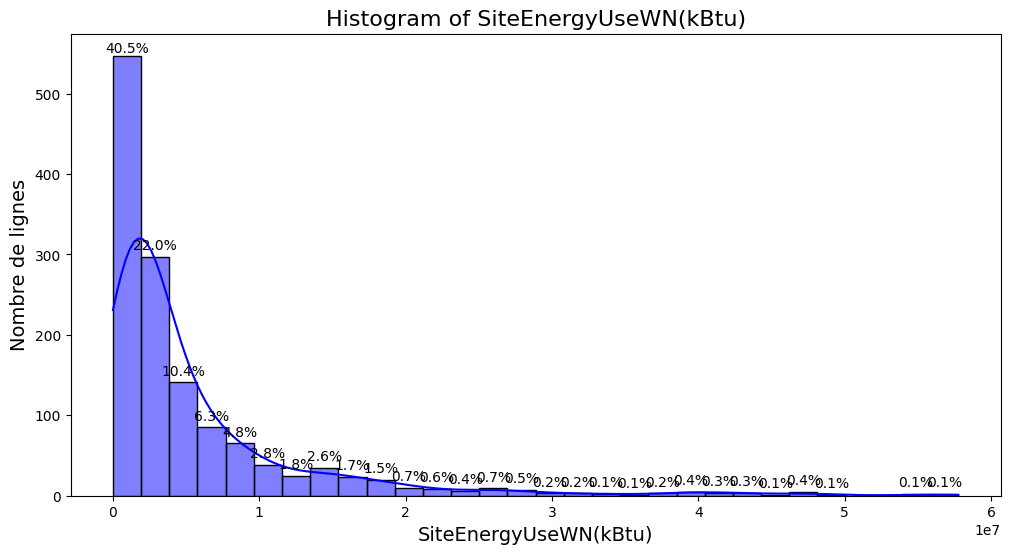

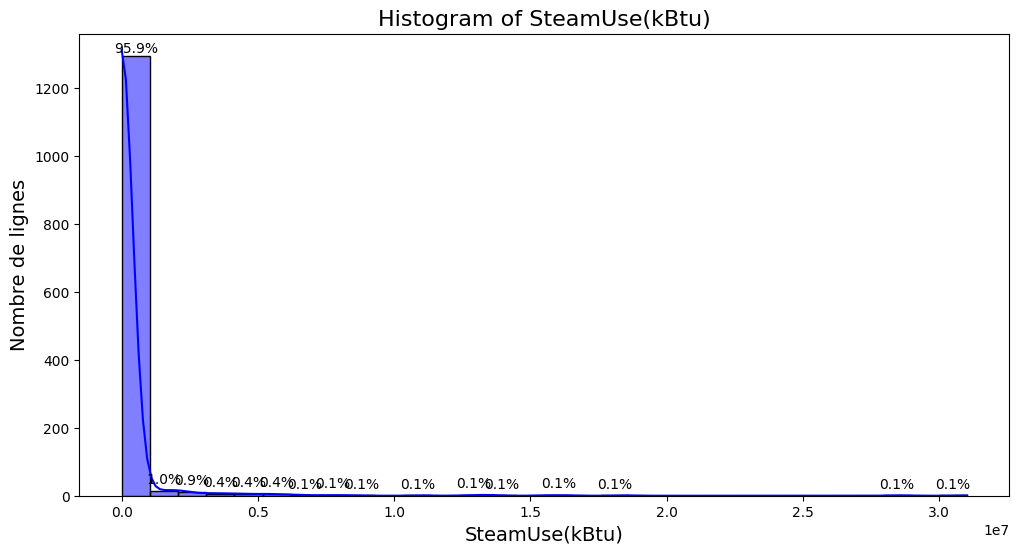

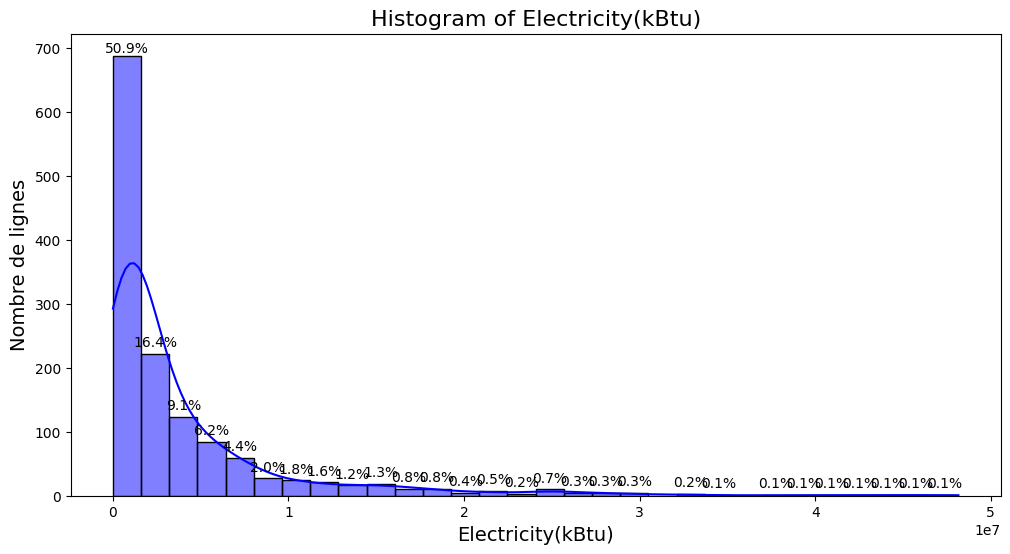

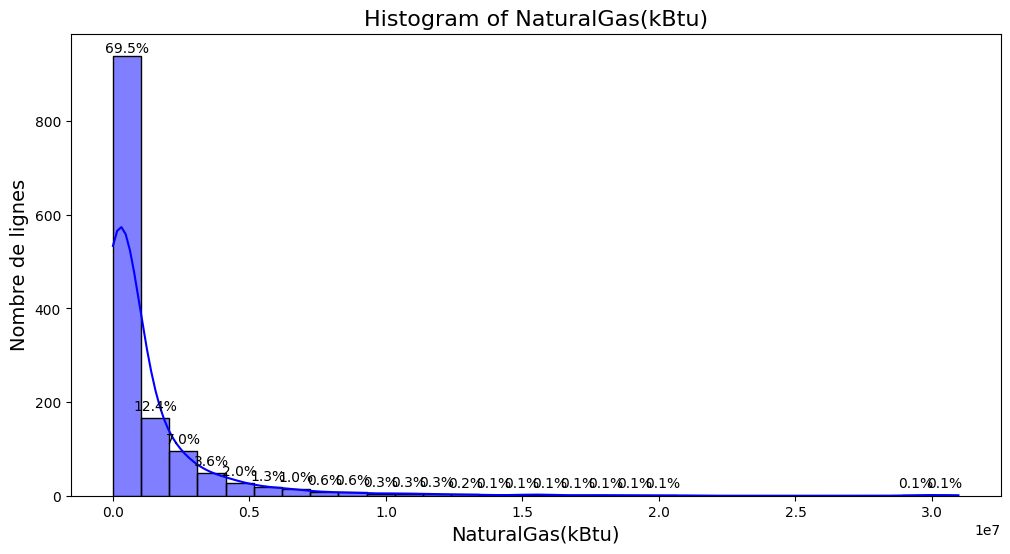

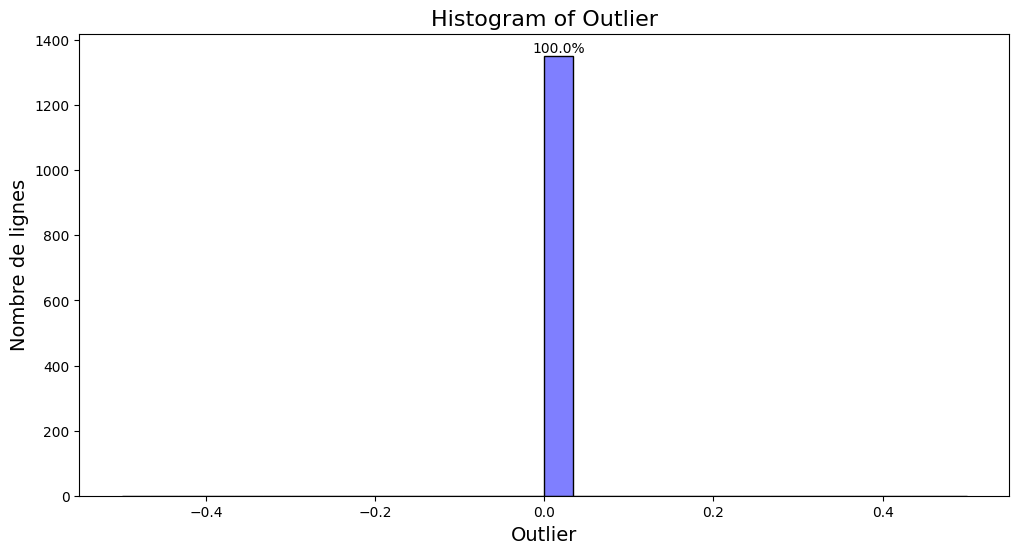

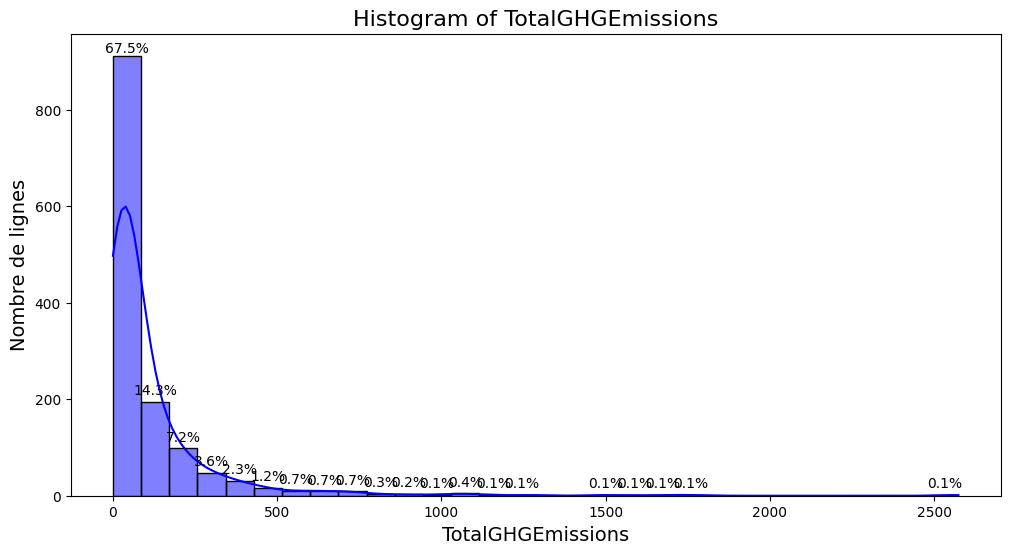

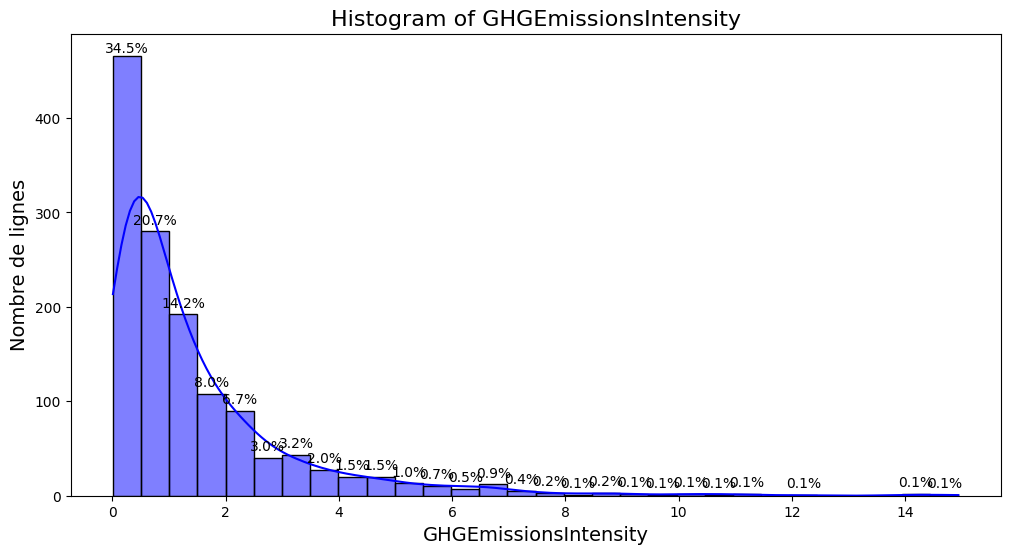

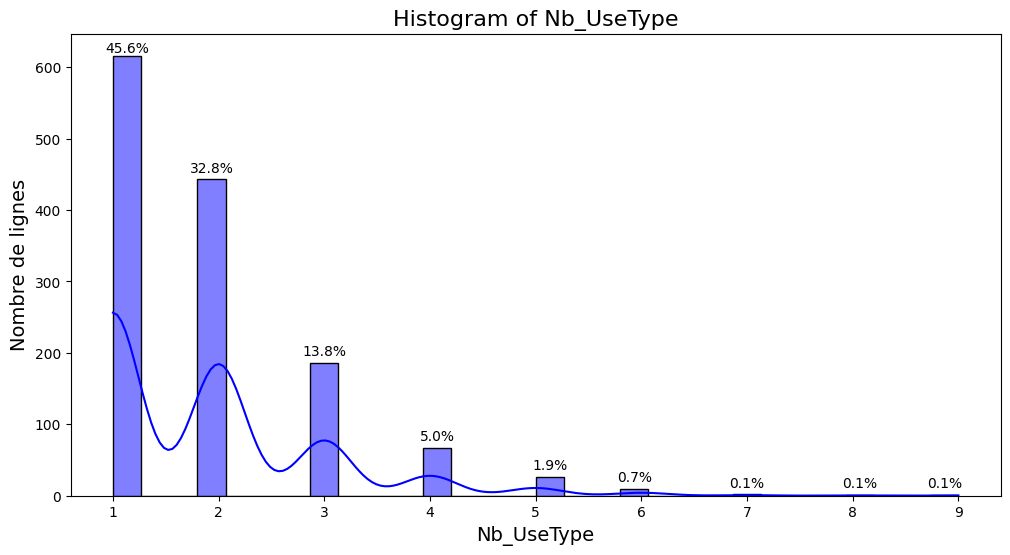

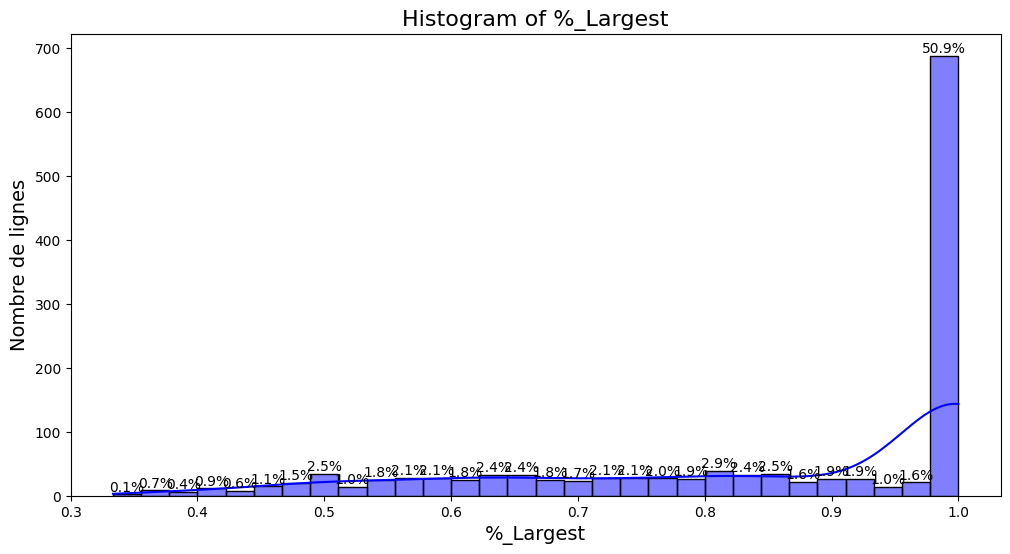

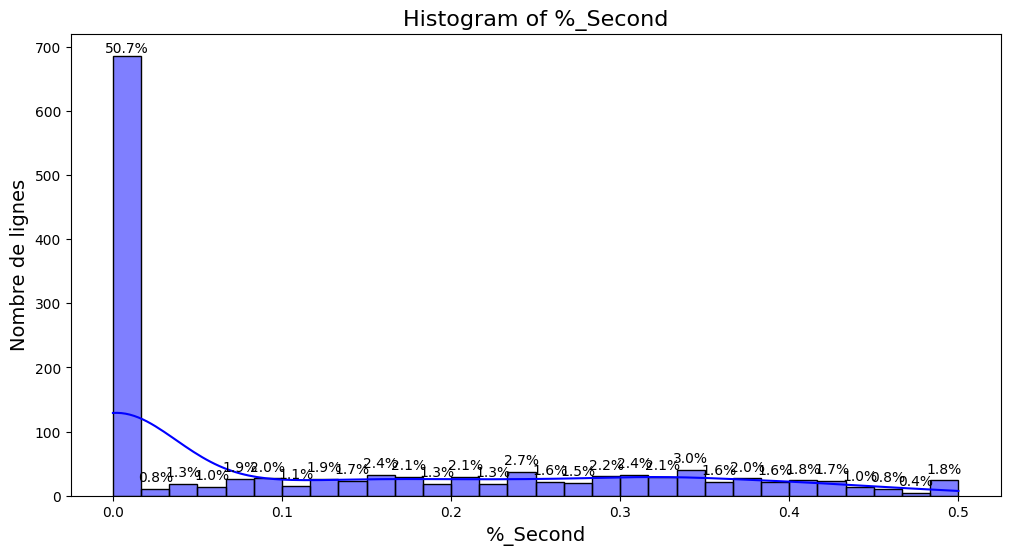

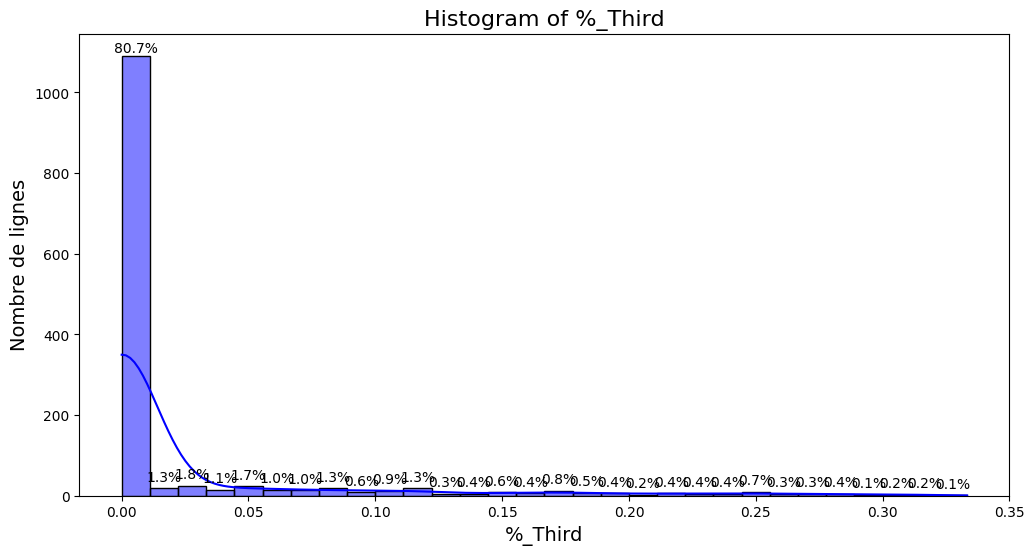

Skipping feature 'OSEBuildingID' because the maximum value count (1) is less than 20.


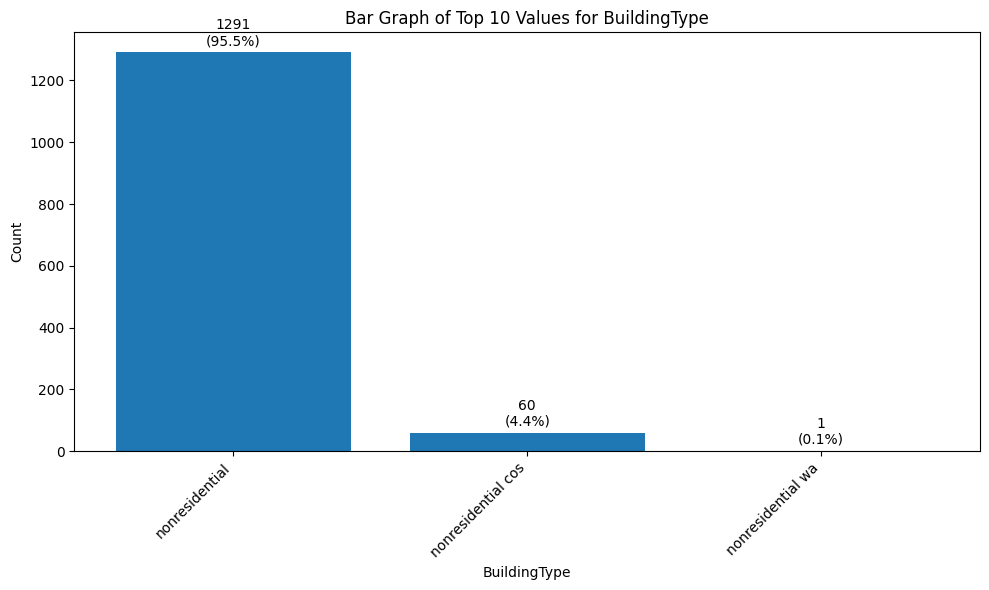

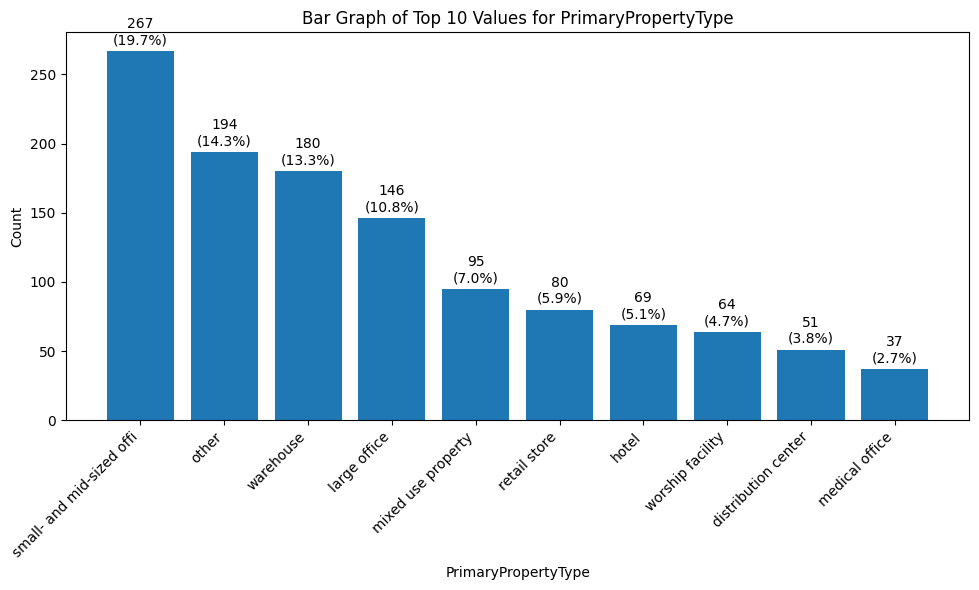

Skipping feature 'PropertyName' because the maximum value count (2) is less than 20.
Skipping feature 'Address' because the maximum value count (4) is less than 20.


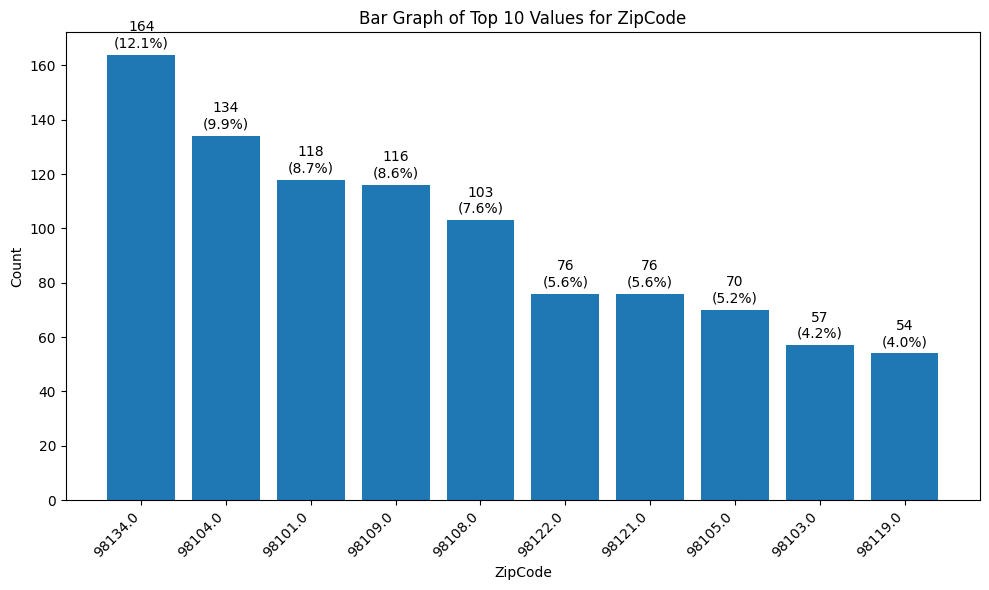

Skipping feature 'TaxParcelIdentificationNumber' because the maximum value count (5) is less than 20.


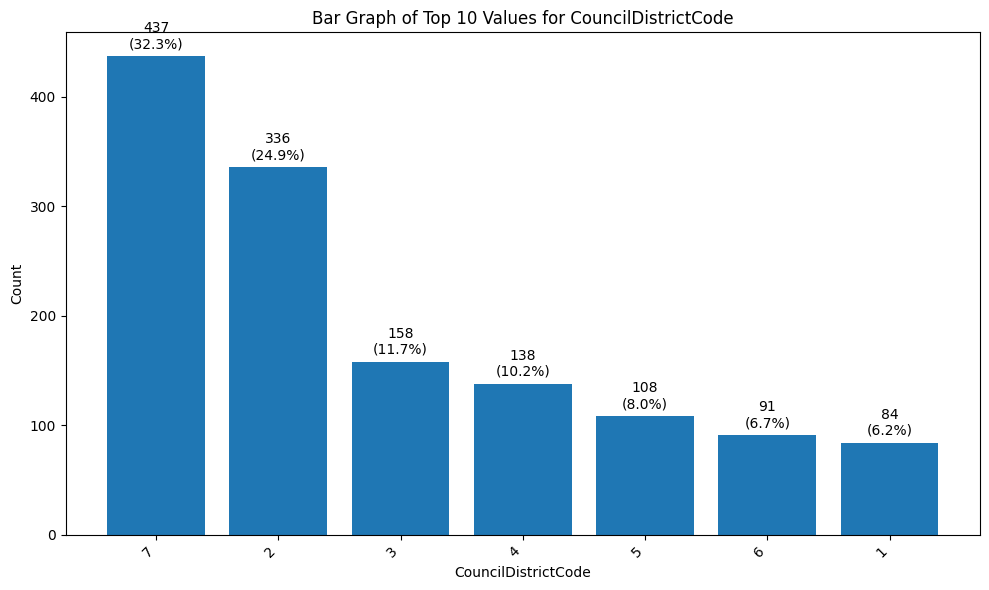

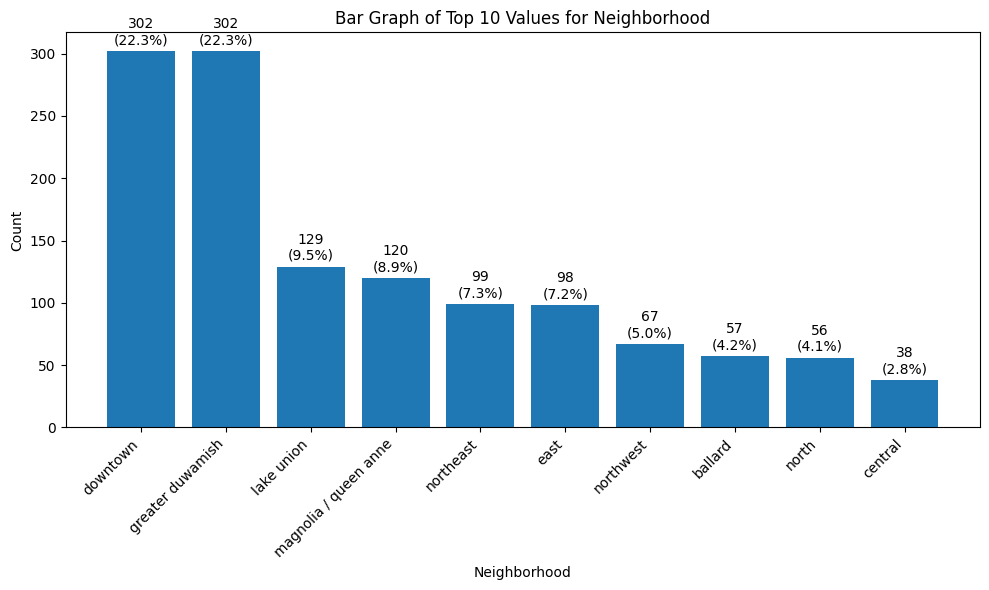

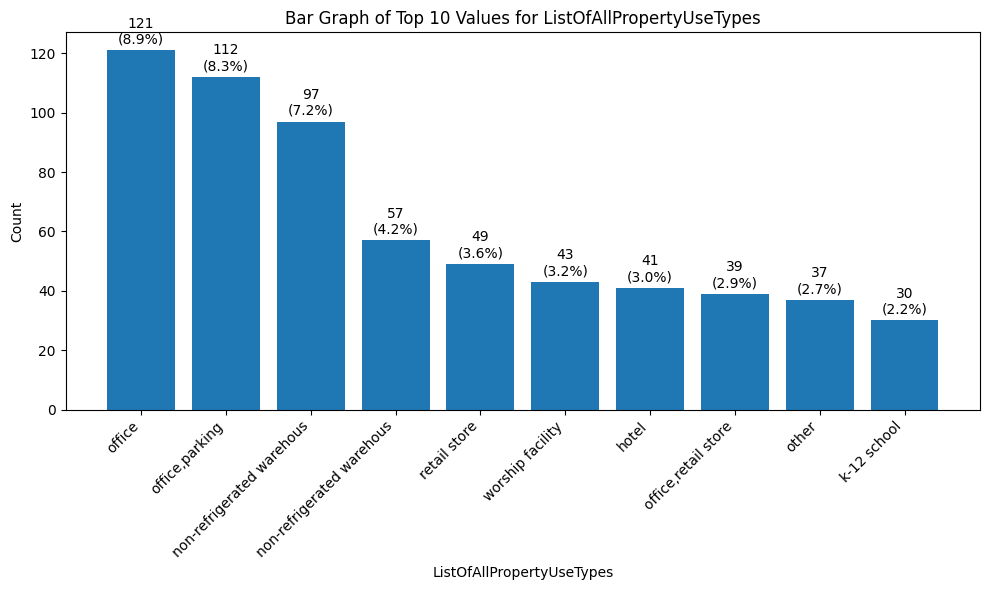

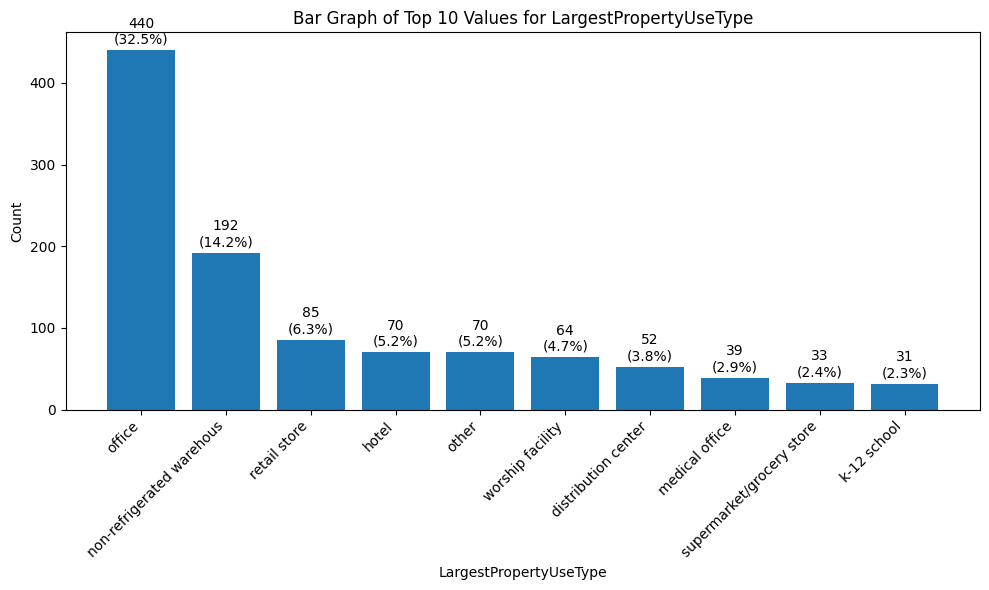

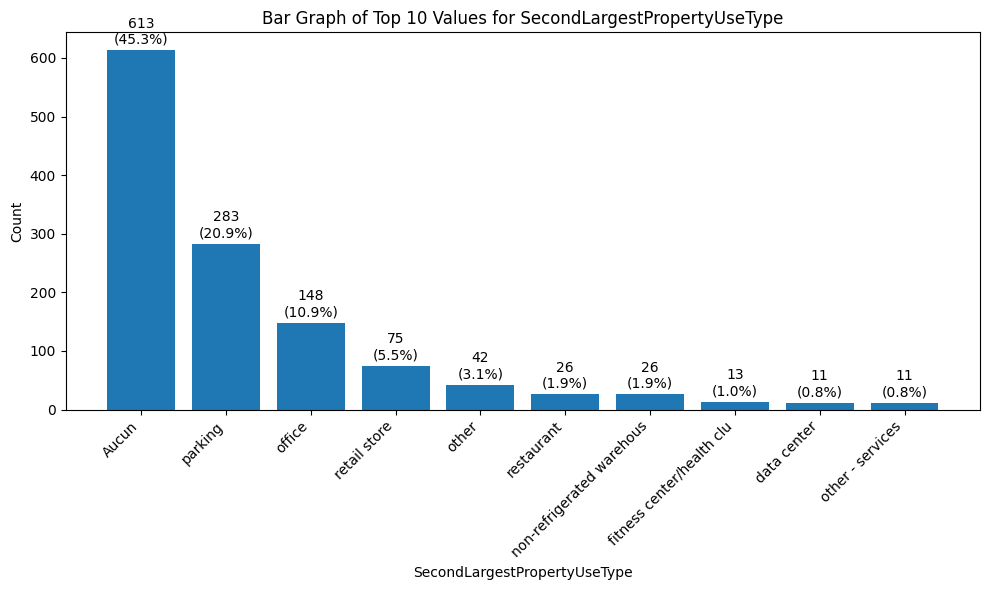

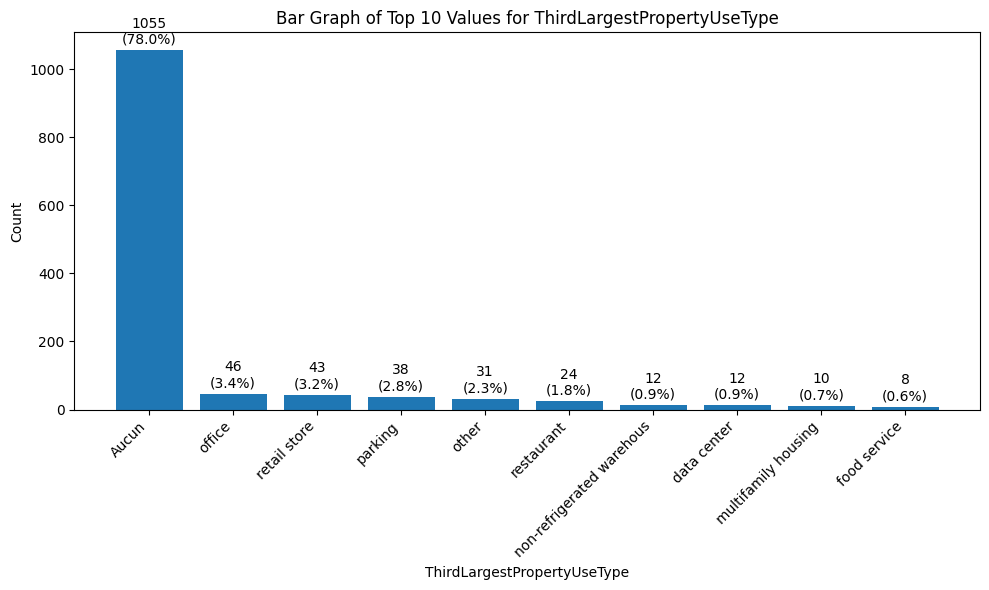

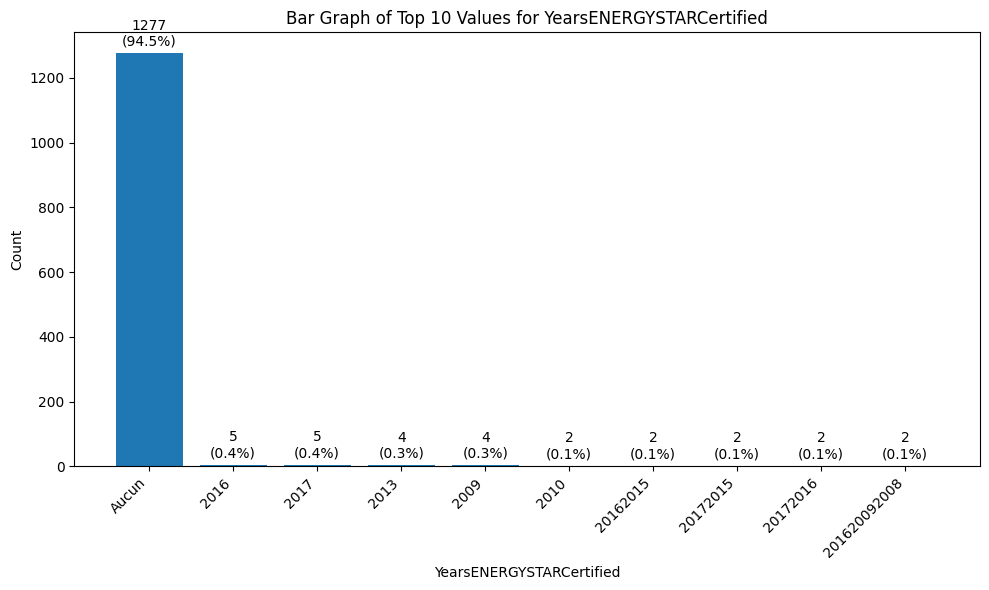

,count,kurt,max,mean,median,min,missing,mode,q1,q3,skew,std,type,unique
feature,,,,,,,,,,,,,,
%_Largest,1352,-0.497796,1.000000e+00,8.512505e-01,1.000000e+00,0.333333,0,1.0,7.083486e-01,1.000000e+00,-0.928426,1.875310e-01,float64,652
%_Second,1352,-0.742005,5.000000e-01,1.259843e-01,0.000000e+00,0.000000,0,0.0,0.000000e+00,2.500694e-01,0.833293,1.554146e-01,float64,653
%_Third,1352,8.596968,3.333333e-01,2.276525e-02,0.000000e+00,0.000000,0,0.0,0.000000e+00,0.000000e+00,2.990511,5.913331e-02,float64,276
Address,1352,NaN,NaN,NaN,NaN,NaN,0,2203 airport way s,NaN,NaN,NaN,NaN,object,1335
BuildingType,1352,NaN,NaN,NaN,NaN,NaN,0,nonresidential,NaN,NaN,NaN,NaN,object,3
CouncilDistrictCode,1352,NaN,NaN,NaN,NaN,NaN,0,7,NaN,NaN,NaN,NaN,object,7
ENERGYSTARScore,1352,-1.630549,1.000000e+02,4.141198e+01,4.250000e+01,0.000000,0,0.0,0.000000e+00,7.800000e+01,0.130148,3.784205e+01,float64,101
Electricity(kBtu),1352,12.811926,4.815504e+07,3.960040e+06,1.558390e+06,0.000000,0,815508.0,6.883495e+05,4.460641e+06,3.191382,6.068339e+06,float64,1351
GHGEmissionsIntensity,1352,11.762434,1.494000e+01,1.456294e+00,8.400000e-01,0.010000,0,0.23,3.500000e-01,1.882500e+00,2.875615,1.761442e+00,float64,407


In [183]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import univariate_analysis

univariate_analysis(df_copy_clean)

Vue d'ensemble des valeurs des variables. Au vu du tableau, certaines variables pourraient s'avérer plus utiles avec une transformation. Par exemple :
- pour les consommations : log ou racine 
- pour le nombre d'étage : racine ou réciproque
- age et %_largest : carré ou cube

## 4.2. Bivariée

### Intro

In [184]:
df_copy_clean.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)',
       'NaturalGas(kBtu)', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsIntensity', 'Nb_UseType', '%_Largest', '%_Second',
       '%_Third'],
      dtype='objec

On isole les cibles :

In [185]:
# Séléction des cibles :
T1 = df_copy_clean["SiteEUIWN(kBtu/sf)"]
T2 = df_copy_clean["GHGEmissionsIntensity"]

Mets les cibles au log, pour comparer les perfs modèles :

In [186]:
df_copy_clean["log_SiteEUIWN(kBtu/sf)"] = np.log1p(df_copy_clean["SiteEUIWN(kBtu/sf)"])
df_copy_clean["log_GHGEmissionsIntensity"] = np.log1p(df_copy_clean["GHGEmissionsIntensity"])

In [187]:
T1_log = df_copy_clean["log_SiteEUIWN(kBtu/sf)"] 
T2_log = df_copy_clean["log_GHGEmissionsIntensity"]

In [188]:
targets = ["SiteEUIWN(kBtu/sf)","log_SiteEUIWN(kBtu/sf)","GHGEmissionsIntensity","log_GHGEmissionsIntensity"]

In [189]:
num_col, cat_col = type_definition(df_copy_clean)

Colonnes numériques : ['Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)', 'Outlier', 'TotalGHGEmissions', 'GHGEmissionsIntensity', 'Nb_UseType', '%_Largest', '%_Second', '%_Third', 'log_SiteEUIWN(kBtu/sf)', 'log_GHGEmissionsIntensity']
Colonnes catégoriques : ['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName', 'Address', 'ZipCode', 'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified']


On crée un df sans target :

In [190]:
df_copy_clean_no_target = df_copy_clean.drop(columns = targets)

### Num - Num

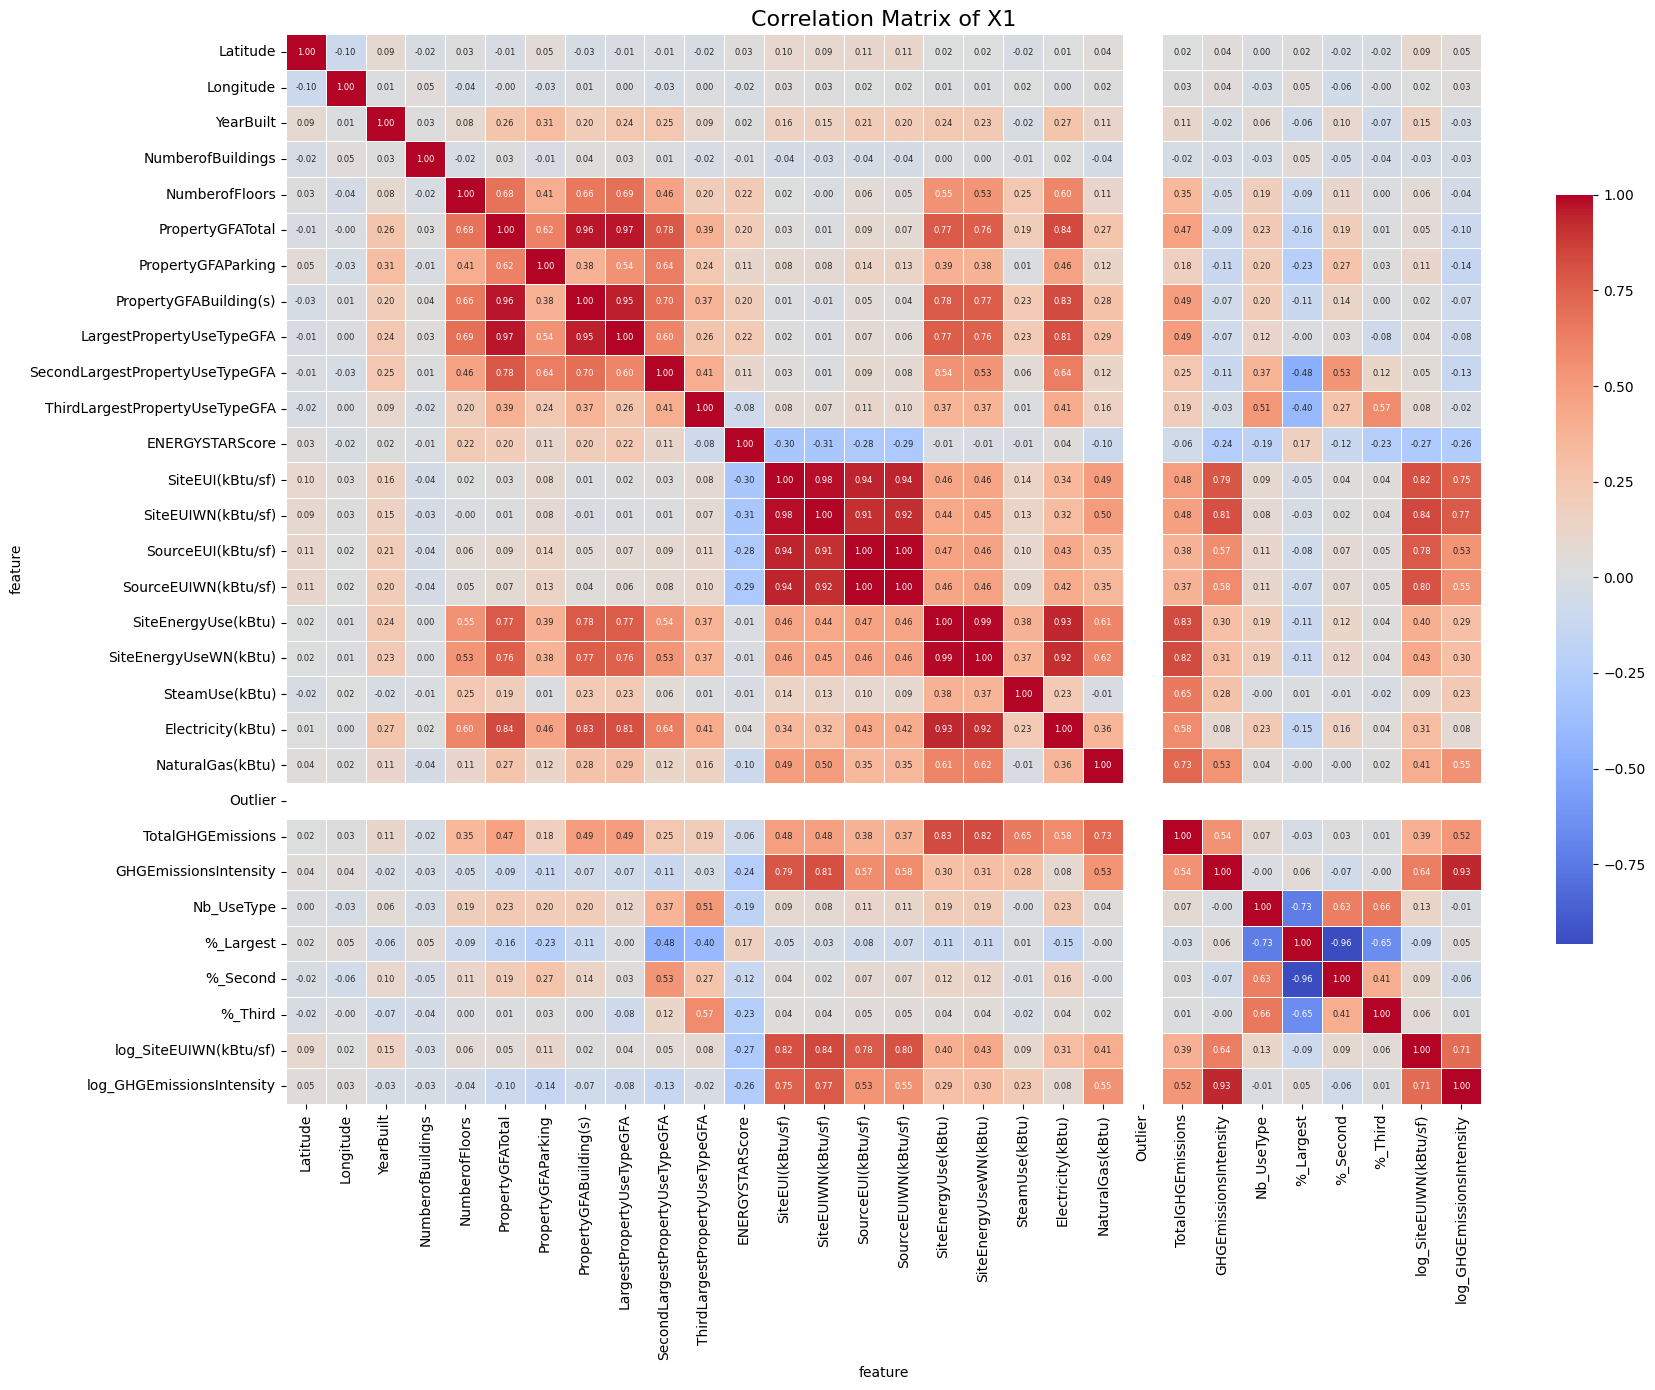

In [191]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import corr_matrix
corr_matrix(df_copy_clean)

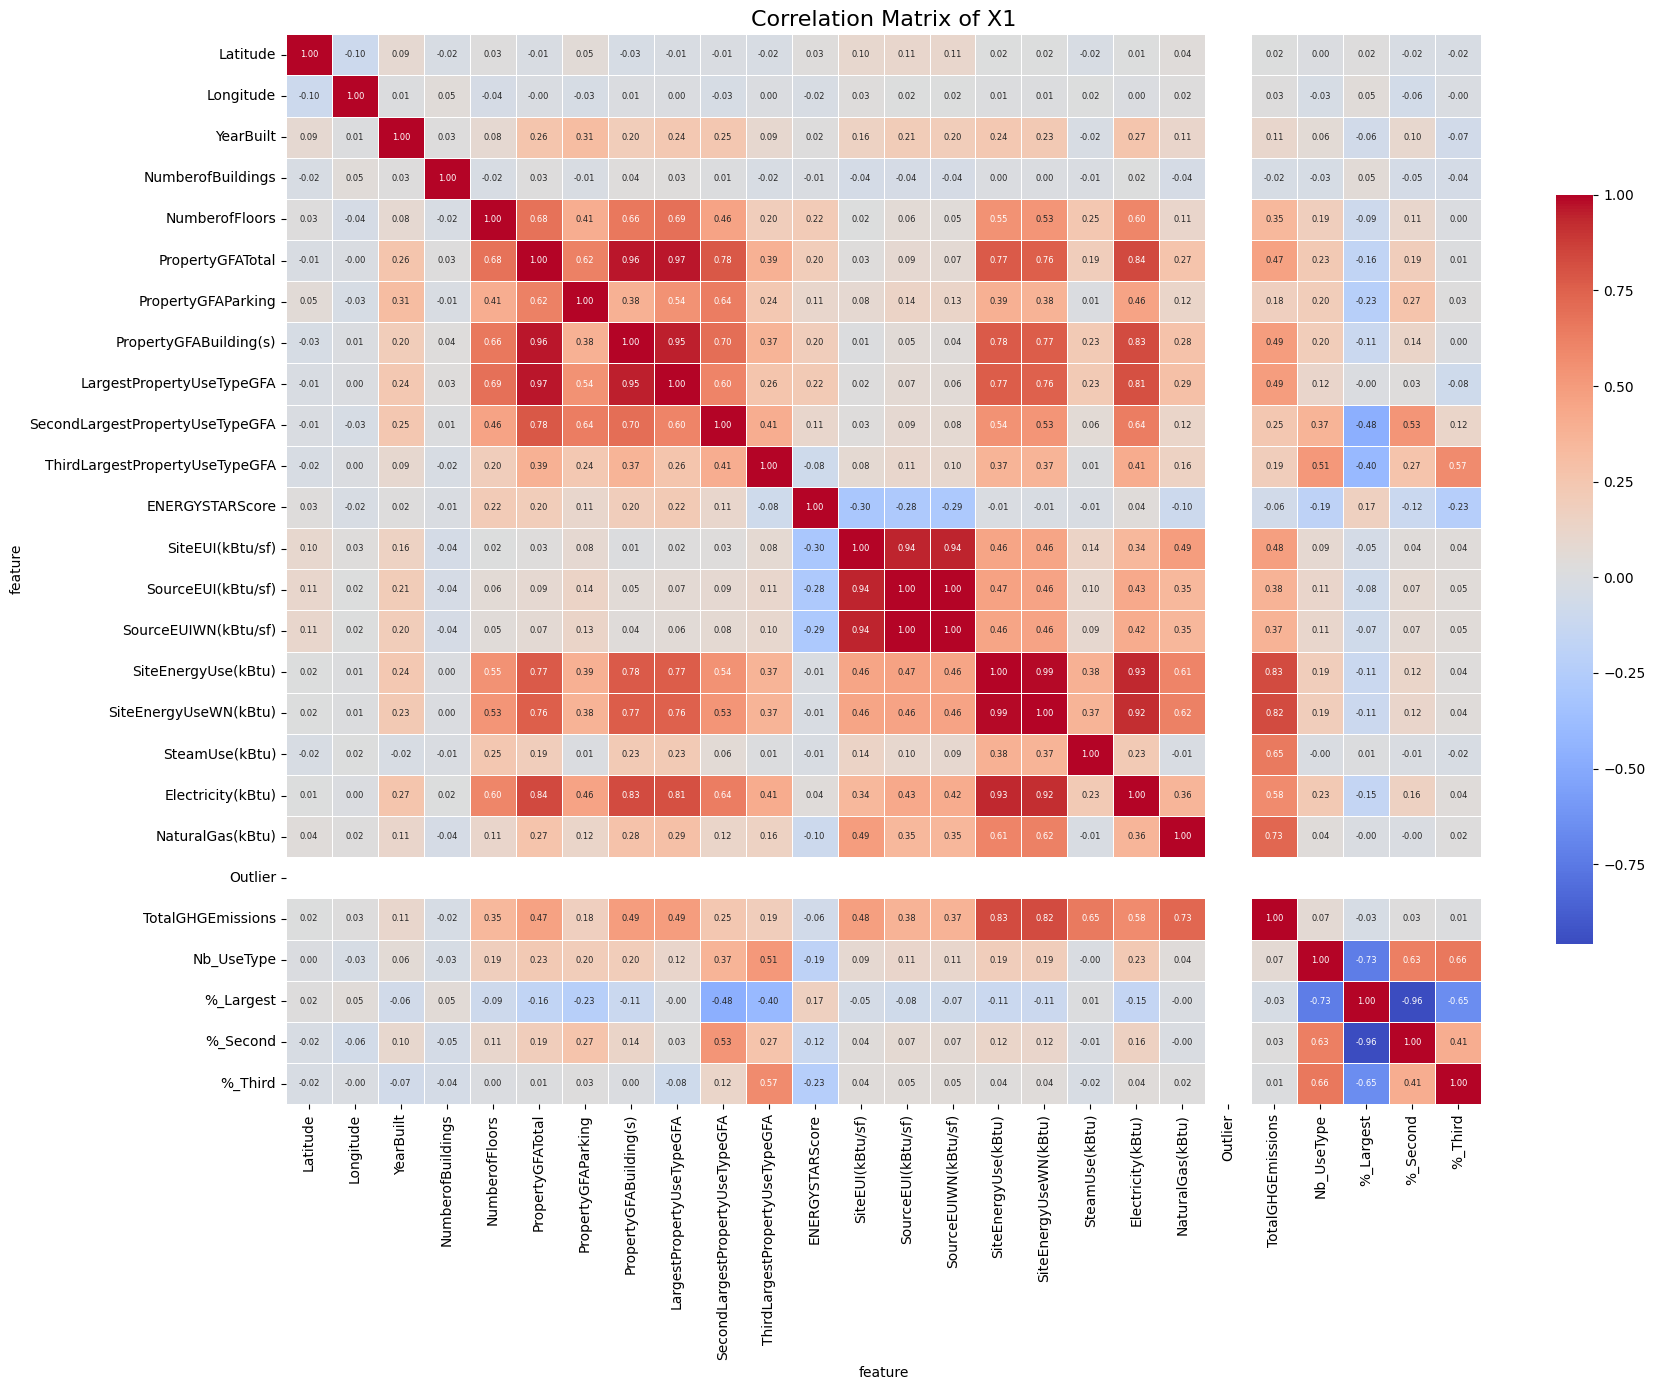

In [192]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import corr_matrix

corr_matrix(df_copy_clean_no_target)

In [193]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import print_top_correlations
high_corr_list, added_pairs = print_top_correlations(df_copy_clean_no_target, n=8, threshold=0.8)
high_corr_list

Top 8 Correlations (Positive and Negative) for Latitude:
  SourceEUI(kBtu/sf): 0.11
  SourceEUIWN(kBtu/sf): 0.11
  SiteEUI(kBtu/sf): 0.10
  Longitude: -0.10
  YearBuilt: 0.09
  PropertyGFAParking: 0.05
  NaturalGas(kBtu): 0.04
  ENERGYSTARScore: 0.03
----------------------------------------
Top 8 Correlations (Positive and Negative) for Longitude:
  Latitude: -0.10
  %_Second: -0.06
  NumberofBuildings: 0.05
  %_Largest: 0.05
  NumberofFloors: -0.04
  Nb_UseType: -0.03
  PropertyGFAParking: -0.03
  SiteEUI(kBtu/sf): 0.03
----------------------------------------
Top 8 Correlations (Positive and Negative) for YearBuilt:
  PropertyGFAParking: 0.31
  Electricity(kBtu): 0.27
  PropertyGFATotal: 0.26
  SecondLargestPropertyUseTypeGFA: 0.25
  LargestPropertyUseTypeGFA: 0.24
  SiteEnergyUse(kBtu): 0.24
  SiteEnergyUseWN(kBtu): 0.23
  SourceEUI(kBtu/sf): 0.21
----------------------------------------
Top 8 Correlations (Positive and Negative) for NumberofBuildings:
  %_Largest: 0.05
  Longitude:

[('PropertyGFATotal', 'LargestPropertyUseTypeGFA', 0.9667898950223759),
 ('PropertyGFATotal', 'PropertyGFABuilding(s)', 0.9622125616514722),
 ('PropertyGFATotal', 'Electricity(kBtu)', 0.8391579379734929),
 ('PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 0.9501552191468412),
 ('PropertyGFABuilding(s)', 'Electricity(kBtu)', 0.8293183926308498),
 ('LargestPropertyUseTypeGFA', 'Electricity(kBtu)', 0.8102745446763461),
 ('SiteEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 0.9414216841459127),
 ('SiteEUI(kBtu/sf)', 'SourceEUI(kBtu/sf)', 0.9402003653037473),
 ('SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 0.9961929276473904),
 ('SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 0.9914122881044973),
 ('SiteEnergyUse(kBtu)', 'Electricity(kBtu)', 0.9344036434440801),
 ('SiteEnergyUse(kBtu)', 'TotalGHGEmissions', 0.8252735549111061),
 ('SiteEnergyUseWN(kBtu)', 'Electricity(kBtu)', 0.9201713930843723),
 ('SiteEnergyUseWN(kBtu)', 'TotalGHGEmissions', 0.8248078903498397),
 ('%_Largest', '%_Second', -0.

In [194]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import count_string_occurrences

count_string_occurrences(added_pairs)

Counter({'Electricity(kBtu)': 5,
         'SiteEnergyUse(kBtu)': 3,
         'PropertyGFABuilding(s)': 3,
         'SiteEnergyUseWN(kBtu)': 3,
         'LargestPropertyUseTypeGFA': 3,
         'PropertyGFATotal': 3,
         'TotalGHGEmissions': 2,
         'SourceEUI(kBtu/sf)': 2,
         'SourceEUIWN(kBtu/sf)': 2,
         'SiteEUI(kBtu/sf)': 2,
         '%_Largest': 1,
         '%_Second': 1})

Nous éliminerons les plus corrélées après le feature engineering et avant de les passer dans le modèle, dans le notebook suivant.

### Cat - Cat

In [195]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import cramers_v, analyse_cat_cat

In [196]:
significant_results = analyse_cat_cat(df_copy_clean)

Skipping OSEBuildingID vs. BuildingType: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. PrimaryPropertyType: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. PropertyName: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. Address: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. ZipCode: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. TaxParcelIdentificationNumber: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. CouncilDistrictCode: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. Neighborhood: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. ListOfAllPropertyUseTypes: One or both columns have a mode occurring less than 15 times.
Skipping OSEBuildingID vs. LargestPrope

In [197]:
cramer_sort = significant_results.sort_values(by='cramers_v', ascending=False)
cramer_sort.sort_values(by='cramers_v', ascending=False).head(10)

,col1,col2,p_value,cramers_v
11,PrimaryPropertyType,LargestPropertyUseType,0.000000e+00,0.908909
27,ListOfAllPropertyUseTypes,LargestPropertyUseType,0.000000e+00,0.868715
20,CouncilDistrictCode,Neighborhood,0.000000e+00,0.856365
28,ListOfAllPropertyUseTypes,SecondLargestPropertyUseType,0.000000e+00,0.833721
14,ZipCode,CouncilDistrictCode,0.000000e+00,0.830415
10,PrimaryPropertyType,ListOfAllPropertyUseTypes,0.000000e+00,0.827250
29,ListOfAllPropertyUseTypes,ThirdLargestPropertyUseType,0.000000e+00,0.822884
15,ZipCode,Neighborhood,0.000000e+00,0.764597
4,BuildingType,LargestPropertyUseType,1.101992e-63,0.411070
1,BuildingType,ZipCode,1.354599e-62,0.399139


On supprime PrimaryPropertyType, ListOfAllPropertyUseTypes, Neighborhood, ZipCode.

In [198]:
cat_col_correlated = ["PrimaryPropertyType", "ListOfAllPropertyUseTypes", "Neighborhood","ZipCode"]
print(df_copy_clean.shape)

(1352, 44)


In [199]:
df_copy_clean.columns

Index(['OSEBuildingID', 'BuildingType', 'PrimaryPropertyType', 'PropertyName',
       'Address', 'ZipCode', 'TaxParcelIdentificationNumber',
       'CouncilDistrictCode', 'Neighborhood', 'Latitude', 'Longitude',
       'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)', 'Electricity(kBtu)',
       'NaturalGas(kBtu)', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsIntensity', 'Nb_UseType', '%_Largest', '%_Second',
       '%_Third', 'log_SiteEUIWN(kBtu

In [200]:
df_copy_clean = df_copy_clean.drop(columns = cat_col_correlated )
print(df_copy_clean.shape)

(1352, 40)


### Cat - Num

In [201]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import bar_chart

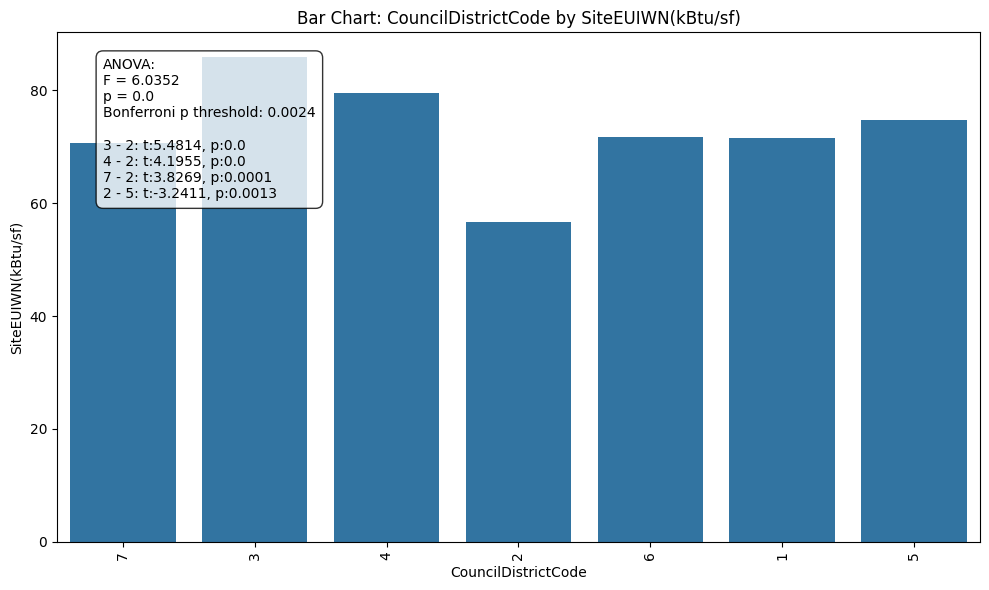

In [202]:
all_cols = ['OSEBuildingID', 'BuildingType', 'PropertyName', 'Address',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Latitude',
       'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kBtu)', 'NaturalGas(kBtu)', 'Outlier', 'TotalGHGEmissions',
       'GHGEmissionsIntensity', 'Nb_UseType', '%_Largest', '%_Second',
       '%_Third', 'log_SiteEUIWN(kBtu/sf)', 'log_GHGEmissionsIntensity']

col = "CouncilDistrictCode"

bar_chart(df_copy_clean, 'SiteEUIWN(kBtu/sf)', col)

Il y'a une différence significative entre certains sous-groupes pour la colonne CouncilDistrictCode.
Nous ne savons pas s'il y'a un lien de causalité, mais il y a un lien de corrélation.

Les résultats sont similaires sur la 2è cible :

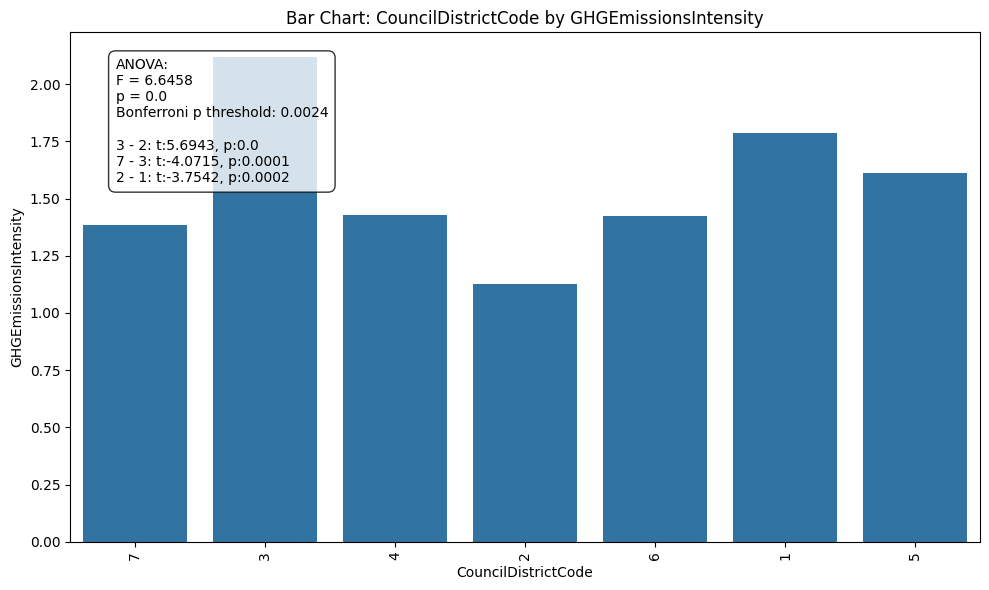

In [203]:
col = "CouncilDistrictCode"

bar_chart(df_copy_clean, 'GHGEmissionsIntensity', col)

Skipping group 'courthouse' due to insufficient data (n < 2).
Skipping group 'urgent care/clinic/other outpatient' due to insufficient data (n < 2).
Skipping group 'wholesale club/supercenter' due to insufficient data (n < 2).
Skipping group 'lifestyle center' due to insufficient data (n < 2).
Skipping group 'fire station' due to insufficient data (n < 2).
Skipping group 'residential care facility' due to insufficient data (n < 2).
Skipping group 'food service' due to insufficient data (n < 2).
Skipping group 'adult education' due to insufficient data (n < 2).
Skipping group 'movie theater' due to insufficient data (n < 2).
Skipping group 'personal services' due to insufficient data (n < 2).


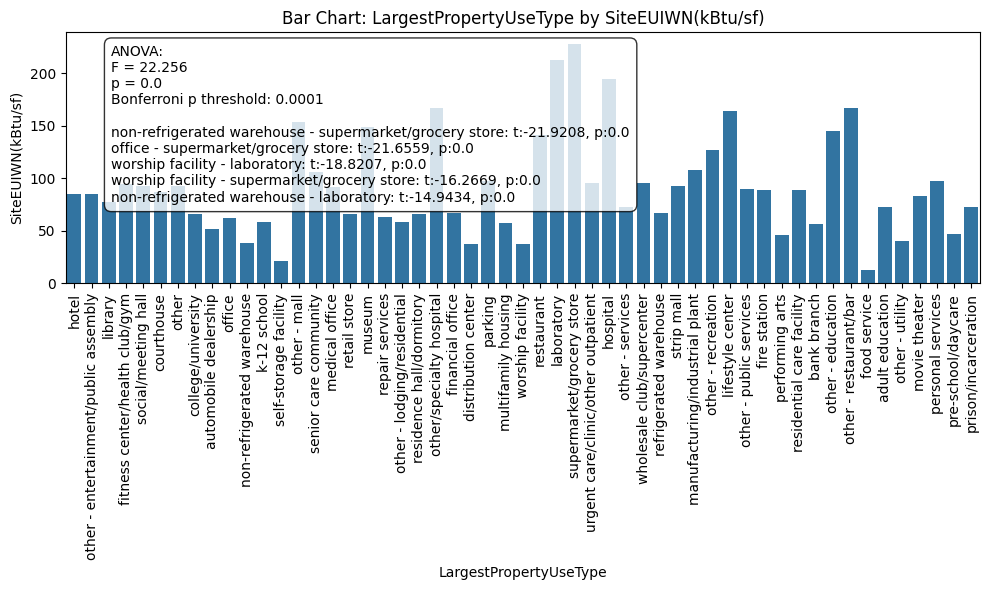

In [204]:
col = "LargestPropertyUseType"

bar_chart(df_copy_clean, 'SiteEUIWN(kBtu/sf)', col)

Les résultats sont similaires sur la 2è cible :

Skipping group 'courthouse' due to insufficient data (n < 2).
Skipping group 'urgent care/clinic/other outpatient' due to insufficient data (n < 2).
Skipping group 'wholesale club/supercenter' due to insufficient data (n < 2).
Skipping group 'lifestyle center' due to insufficient data (n < 2).
Skipping group 'fire station' due to insufficient data (n < 2).
Skipping group 'residential care facility' due to insufficient data (n < 2).
Skipping group 'food service' due to insufficient data (n < 2).
Skipping group 'adult education' due to insufficient data (n < 2).
Skipping group 'movie theater' due to insufficient data (n < 2).
Skipping group 'personal services' due to insufficient data (n < 2).


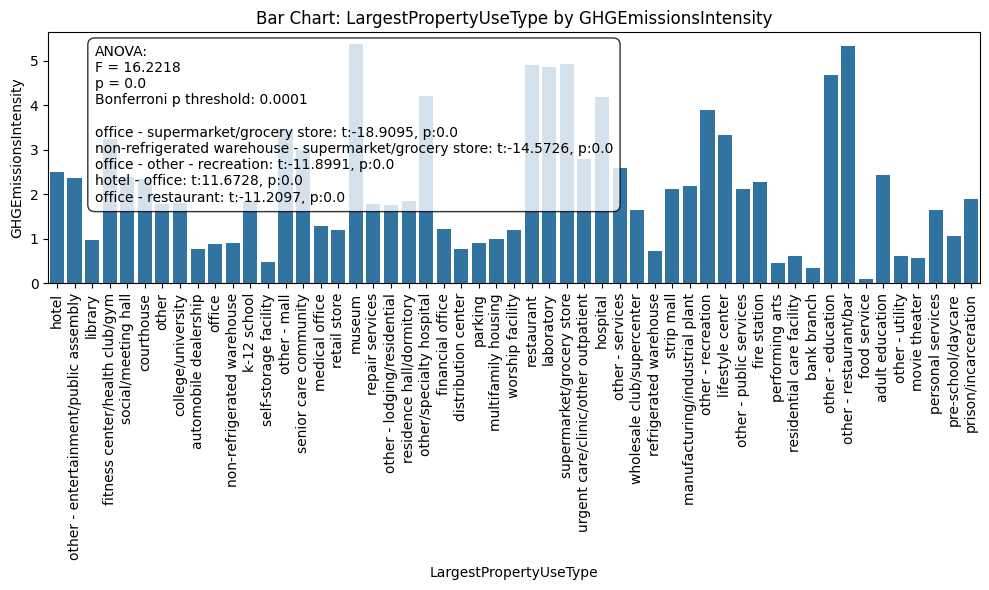

In [205]:
col = "LargestPropertyUseType"

bar_chart(df_copy_clean, 'GHGEmissionsIntensity', col)

Il y'a une différence très significative de consommation selon la modalité de LargestPropertyUseType. Ce lien est beaucoup plus évident que pour CouncilDistrictCode.

## Analyse multi-variée

In [206]:
from My_function_p4_explo import run_ols_with_two_features

In [207]:
no_leak_col = list(set(df_copy_clean.columns).difference(['SiteEnergyUse(kBtu)', 'Electricity(kBtu)',
 'GHGEmissionsIntensity', 'Electricity(kWh)', 'NaturalGas(therms)', 'ENERGYSTARScore', 'SiteEUIWN(kBtu/sf)', 'NaturalGas(kBtu)',
 'SiteEnergyUseWN(kBtu)', 'SourceEUI(kBtu/sf)','TotalGHGEmissions','SiteEUI(kBtu/sf)', 'SteamUse(kBtu)','SourceEUIWN(kBtu/sf)',
 'log_GHGEmissionsIntensity','log_SiteEUIWN(kBtu/sf)']))

In [208]:
feat_for_reg = no_leak_col
target_col = 'SiteEUIWN(kBtu/sf)'

results = run_ols_with_two_features(df_copy_clean, target_col = target_col, feat_col = feat_for_reg)

In [209]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import compare_r_squared_2, compare_r_squared_3

In [210]:
compare_r_squared_2(results=results)

Result 0: Features=(YearBuilt, Latitude), R-squared = 0.0302
Result 1: Features=(YearBuilt, Nb_UseType), R-squared = 0.0285
Result 2: Features=(YearBuilt, ThirdLargestPropertyUseTypeGFA), R-squared = 0.0266
Result 3: Features=(YearBuilt, PropertyGFABuilding(s)), R-squared = 0.0258
Result 4: Features=(YearBuilt, %_Third), R-squared = 0.0258
Result 5: Features=(YearBuilt, NumberofBuildings), R-squared = 0.0252
Result 6: Features=(YearBuilt, SecondLargestPropertyUseTypeGFA), R-squared = 0.0247
Result 7: Features=(YearBuilt, LargestPropertyUseTypeGFA), R-squared = 0.0247
Result 8: Features=(YearBuilt, PropertyGFAParking), R-squared = 0.0247
Result 9: Features=(YearBuilt, PropertyGFATotal), R-squared = 0.0246
Result 10: Features=(YearBuilt, Longitude), R-squared = 0.0243
Result 11: Features=(YearBuilt, %_Largest), R-squared = 0.0241
Result 12: Features=(YearBuilt, NumberofFloors), R-squared = 0.0239
Result 13: Features=(YearBuilt, %_Second), R-squared = 0.0237
Result 14: Features=(YearBuilt

In [211]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import run_ols_with_3_features
results = run_ols_with_3_features(df_copy_clean, target_col = target_col, feat_col = feat_for_reg)

In [212]:
compare_r_squared_3(results=results)

Result 0: Features=(YearBuilt, Nb_UseType, Latitude), R-squared = 0.0350
Result 1: Features=(YearBuilt, Latitude, ThirdLargestPropertyUseTypeGFA), R-squared = 0.0334
Result 2: Features=(YearBuilt, %_Third, Latitude), R-squared = 0.0324
Result 3: Features=(YearBuilt, Nb_UseType, SecondLargestPropertyUseTypeGFA), R-squared = 0.0323
Result 4: Features=(YearBuilt, Nb_UseType, PropertyGFABuilding(s)), R-squared = 0.0321
Result 5: Features=(YearBuilt, Latitude, PropertyGFABuilding(s)), R-squared = 0.0319
Result 6: Features=(YearBuilt, NumberofBuildings, Latitude), R-squared = 0.0316
Result 7: Features=(YearBuilt, PropertyGFABuilding(s), ThirdLargestPropertyUseTypeGFA), R-squared = 0.0315
Result 8: Features=(YearBuilt, Latitude, Longitude), R-squared = 0.0312
Result 9: Features=(YearBuilt, Latitude, SecondLargestPropertyUseTypeGFA), R-squared = 0.0311
Result 10: Features=(YearBuilt, LargestPropertyUseTypeGFA, Latitude), R-squared = 0.0310
Result 11: Features=(YearBuilt, Latitude, PropertyGFAP

L'analyse multi-variée n'indique rien d'intéressant avec les features numériques en l'état.

# 5. Feature engineering

## Parking

In [213]:
df_copy_clean['%_GFA_Parking'] = round(df_copy_clean['PropertyGFAParking']/df_copy_clean['PropertyGFATotal']*100,2)
df_copy_clean[['%_GFA_Parking']].head()

feature,%_GFA_Parking
0,0.00
1,14.55
3,0.00
4,35.31
6,0.00


In [214]:
df_copy_clean['%_GFA_Parking'].describe()

count    1352.000000
mean        5.964956
std        13.526042
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        79.820000
Name: %_GFA_Parking, dtype: float64

In [215]:
df_copy_clean['%_GFA_Building'] = 100 - df_copy_clean['%_GFA_Parking']
df_copy_clean['%_GFA_Building'].describe()

count    1352.000000
mean       94.035044
std        13.526042
min        20.180000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: %_GFA_Building, dtype: float64

## Age

In [216]:
target_column = "YearBuilt"
target_index = df_copy_clean.columns.get_loc(target_column)
df_copy_clean.insert(loc=target_index, column="Age_Building", value= 2017 - df_copy_clean["YearBuilt"])

In [217]:
print(df_copy_clean[["YearBuilt","Age_Building"]].isna().sum())
df_copy_clean[["YearBuilt","Age_Building"]].head()

feature
YearBuilt       0
Age_Building    0
dtype: int64


feature,YearBuilt,Age_Building
0,1927,90
1,1996,21
3,1926,91
4,1980,37
6,1926,91


## Usage Energétique

In [218]:
target_column = "NaturalGas(kBtu)"
target_index = df_copy_clean.columns.get_loc(target_column)
df_copy_clean.insert(loc=target_index, column="%_Gas", value = 
               round(100*df_copy_clean["NaturalGas(kBtu)"] / df_copy_clean["SiteEnergyUse(kBtu)"],3))

In [219]:
target_column = "SteamUse(kBtu)"
target_index = df_copy_clean.columns.get_loc(target_column)
df_copy_clean.insert(loc=target_index, column="%_Steam", value = 
               round(100*df_copy_clean["SteamUse(kBtu)"] / df_copy_clean["SiteEnergyUse(kBtu)"],3))

In [220]:
target_column = "Electricity(kBtu)"
target_index = df_copy_clean.columns.get_loc(target_column)
df_copy_clean.insert(loc=target_index, column="%_Elec", value = 
               round(100*df_copy_clean["Electricity(kBtu)"] / df_copy_clean["SiteEnergyUse(kBtu)"],3))

In [221]:
df_copy_clean[["%_Elec","%_Gas","%_Steam"]].head()

feature,%_Elec,%_Gas,%_Steam
0,54.606,17.664,27.730
1,38.661,61.339,0.000
3,40.752,26.657,32.591
4,37.880,62.120,0.000
6,48.816,51.184,0.000


In [222]:
df_copy_clean[["%_Elec","%_Gas","%_Steam"]].describe()

feature,%_Elec,%_Gas,%_Steam
count,1352.000000,1352.000000,1352.000000
mean,70.375737,27.526803,2.097016
std,26.349702,26.427738,9.186042
min,0.000000,0.000000,0.000000
25%,49.462750,0.000000,0.000000
50%,71.100500,23.737500,0.000000
75%,100.000000,48.922250,0.000000
max,100.000000,100.000000,76.699000


## Transformations

### Intro

In [223]:
df_copy_clean.columns

Index(['OSEBuildingID', 'BuildingType', 'PropertyName', 'Address',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Latitude',
       'Longitude', 'Age_Building', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'LargestPropertyUseType',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType',
       'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType',
       'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified',
       'ENERGYSTARScore', 'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)',
       'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'SiteEnergyUse(kBtu)',
       'SiteEnergyUseWN(kBtu)', '%_Steam', 'SteamUse(kBtu)', '%_Elec',
       'Electricity(kBtu)', '%_Gas', 'NaturalGas(kBtu)', 'Outlier',
       'TotalGHGEmissions', 'GHGEmissionsIntensity', 'Nb_UseType', '%_Largest',
       '%_Second', '%_Third', 'log_SiteEUIWN(kBtu/sf)',
       'log_GHGEmissionsIntensity

In [224]:
col_to_drop = ["BuildingType","PropertyName", "Address",  "Latitude", "Longitude",
               "TaxParcelIdentificationNumber", "Outlier", "Nb_UseType"]

df_copy_clean = df_copy_clean.drop(columns = col_to_drop)

In [225]:
leak_feature = ["ENERGYSTARScore", "NaturalGas(kBtu)","Electricity(kBtu)","SteamUse(kBtu)", "SiteEUI(kBtu/sf)", "SourceEUIWN(kBtu/sf)", "SourceEUI(kBtu/sf)", "TotalGHGEmissions", "SiteEnergyUseWN(kBtu)", "SiteEnergyUse(kBtu)"]

df_copy_clean = df_copy_clean.drop(columns = leak_feature)

In [226]:
len(df_copy_clean.columns)

28

In [227]:
targets = ['log_SiteEUIWN(kBtu/sf)', 'log_GHGEmissionsIntensity', 'SiteEUIWN(kBtu/sf)', 'GHGEmissionsIntensity']
df_copy_clean_no_target = df_copy_clean.drop(columns = targets)

### Numériques

In [228]:
print(df_copy_clean_no_target.shape)

(1352, 24)


Nous allons explorer les corrélations entre nos variables et nos cibles, selon la ou les transformation effectuée. Nous allons tester des 
- transformations mathématiques : puissances, log
- scaling : robust, standard, yeo johsnon
- des composées de ces fonctions.

In [229]:
num_col = []
cat_col = []

for feat in df_copy_clean_no_target.columns:
    if pd.api.types.is_numeric_dtype(df_copy_clean_no_target[feat]):
        num_col.append(feat)

    else:
        cat_col.append(feat)

df_copy_clean_no_target[num_col].corrwith(T1).sort_values(ascending=False)

feature
%_Gas                              0.167953
YearBuilt                          0.153915
%_GFA_Parking                      0.147423
PropertyGFAParking                 0.077994
%_Steam                            0.075506
ThirdLargestPropertyUseTypeGFA     0.068480
%_Third                            0.035280
%_Second                           0.022223
PropertyGFATotal                   0.010749
SecondLargestPropertyUseTypeGFA    0.006637
LargestPropertyUseTypeGFA          0.005650
NumberofFloors                    -0.001903
PropertyGFABuilding(s)            -0.014420
%_Largest                         -0.029542
NumberofBuildings                 -0.034872
%_GFA_Building                    -0.147423
Age_Building                      -0.153915
%_Elec                            -0.194798
dtype: float64

In [230]:
df_copy_clean[num_col].corrwith(T1).sort_values(ascending=False)

feature
%_Gas                              0.167953
YearBuilt                          0.153915
%_GFA_Parking                      0.147423
PropertyGFAParking                 0.077994
%_Steam                            0.075506
ThirdLargestPropertyUseTypeGFA     0.068480
%_Third                            0.035280
%_Second                           0.022223
PropertyGFATotal                   0.010749
SecondLargestPropertyUseTypeGFA    0.006637
LargestPropertyUseTypeGFA          0.005650
NumberofFloors                    -0.001903
PropertyGFABuilding(s)            -0.014420
%_Largest                         -0.029542
NumberofBuildings                 -0.034872
%_GFA_Building                    -0.147423
Age_Building                      -0.153915
%_Elec                            -0.194798
dtype: float64

### Les fonctions de transformations

In [231]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import analyze_iterative_transformations

In [232]:
summary_results, history_results = analyze_iterative_transformations(
        df_copy_clean,
        'SiteEUIWN(kBtu/sf)',
        max_turns=3,
        min_improvement=0.005 # Require at least 0.005 increase in abs corr
    )

Starting iterative transformation analysis for 21 features...
--- Turn 1/3 ---
  Feature 'NumberofFloors': Improved corr from -0.0019 to -0.0183 using 'power_8_00'
  Feature 'PropertyGFATotal': Improved corr from 0.0107 to 0.0682 using 'yeo_johnson'
  Feature 'PropertyGFAParking': Improved corr from 0.0780 to 0.1241 using 'yeo_johnson'
  Feature 'PropertyGFABuilding(s)': Improved corr from -0.0144 to -0.0432 using 'power_8_00'
  Feature 'LargestPropertyUseTypeGFA': Improved corr from 0.0056 to 0.0495 using 'yeo_johnson'


  Feature 'SecondLargestPropertyUseTypeGFA': Improved corr from 0.0066 to 0.0346 using 'power_0_25'
  Feature 'ThirdLargestPropertyUseTypeGFA': Improved corr from 0.0685 to 0.1457 using 'power_0_50'
  Feature '%_Steam': Improved corr from 0.0755 to 0.2141 using 'power_0_50'
  Feature '%_Elec': Improved corr from -0.1948 to -0.2249 using 'power_3_00'
  Feature '%_Gas': Improved corr from 0.1680 to 0.1956 using 'yeo_johnson'
  Feature '%_Largest': Improved corr from -0.0295 to -0.0376 using 'log2'
  Feature '%_Second': Improved corr from 0.0222 to 0.0468 using 'power_0_50'
  Feature '%_Third': Improved corr from 0.0353 to 0.0719 using 'power_0_50'
  Feature 'log_SiteEUIWN(kBtu/sf)': Improved corr from 0.8416 to 0.9988 using 'power_3_00'
  Feature 'log_GHGEmissionsIntensity': Improved corr from 0.7737 to 0.8137 using 'power_2_00'
  Feature '%_GFA_Parking': Improved corr from 0.1474 to 0.1790 using 'power_0_50'
--- Turn 2/3 ---
  Feature 'PropertyGFABuilding(s)': Improved corr from -0.0432

c:\Users\guill\anaconda3\Lib\site-packages\numpy\core\_methods.py:239: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
c:\Users\guill\anaconda3\Lib\site-packages\numpy\core\_methods.py:239: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


  Feature '%_Steam': Improved corr from 0.2141 to 0.2211 using 'power_2_00'
  Feature '%_Largest': Improved corr from -0.0376 to 0.0572 using 'power_2_00'
  Feature '%_Second': Improved corr from 0.0468 to 0.0797 using 'power_3_00'
  Feature '%_Third': Improved corr from 0.0719 to 0.1043 using 'power_3_00'
--- Turn 3/3 ---
  Feature 'PropertyGFABuilding(s)': Improved corr from 0.0726 to 0.1426 using 'log2'
  Feature '%_Largest': Improved corr from 0.0572 to 0.0911 using 'power_0_50'
Iterative analysis complete.


Ce que dit ce tableau de résultats, c'est qu'une composée des fonctions décrites, appliquées aux valeurs des variables nous donne de nouvelles valeurs qui sont linéairement plus corrélée en valeur absolue à la cible que les valeurs initiales. C'est majoritairement yeo_johnson qui donne les meilleurs résultats.



In [233]:
history_results

,Transform_1,Corr_1,Transform_2,Corr_2,Transform_3,Corr_3
Age_Building,None,NaN,None,NaN,None,NaN
YearBuilt,None,NaN,None,NaN,None,NaN
NumberofBuildings,None,NaN,None,NaN,None,NaN
NumberofFloors,power_8_00,-0.018283,None,NaN,None,NaN
PropertyGFATotal,yeo_johnson,0.068170,None,NaN,None,NaN
PropertyGFAParking,yeo_johnson,0.124059,None,NaN,None,NaN
PropertyGFABuilding(s),power_8_00,-0.043164,power_3_00,0.072602,log2,0.142624
LargestPropertyUseTypeGFA,yeo_johnson,0.049535,None,NaN,None,NaN
SecondLargestPropertyUseTypeGFA,power_0_25,0.034563,None,NaN,None,NaN
ThirdLargestPropertyUseTypeGFA,power_0_50,0.145657,power_2_00,0.169713,None,NaN


In [234]:
summary_results

,Initial Correlation,Final Correlation,Num Transformations
Feature,,,
Age_Building,-0.153915,-0.153915,0
YearBuilt,0.153915,0.153915,0
NumberofBuildings,-0.034872,-0.034872,0
NumberofFloors,-0.001903,-0.018283,1
PropertyGFATotal,0.010749,0.068170,1
PropertyGFAParking,0.077994,0.124059,1
PropertyGFABuilding(s),-0.014420,0.142624,3
LargestPropertyUseTypeGFA,0.005650,0.049535,1
SecondLargestPropertyUseTypeGFA,0.006637,0.034563,1


In [235]:
from My_function_p4_explo import create_transformed_dataframe
df_transformed = create_transformed_dataframe(df_copy_clean, history_results)
df_transformed.head()

feature,OSEBuildingID,CouncilDistrictCode,Age_Building,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,SiteEUIWN(kBtu/sf),%_Steam,%_Elec,%_Gas,GHGEmissionsIntensity,%_Largest,%_Second,%_Third,log_SiteEUIWN(kBtu/sf),log_GHGEmissionsIntensity,%_GFA_Parking,%_GFA_Building
0,1,7,90,1927,1.0,429981696,0.708597,-0.502993,NaN,hotel,0.811364,Aucun,NaN,Aucun,NaN,Aucun,84.321754,27.730,4.855141e+08,0.127654,2.83,NaN,NaN,NaN,1738.029048,1.803286,0.00,100.00
1,2,7,21,1996,1.0,214358881,0.861608,1.981937,62.722721,hotel,0.759289,parking,11.078605,restaurant,4622.0,Aucun,97.901505,NaN,8.637050e+07,1.095172,2.86,0.304152,0.008069,0.000421,2046.509576,1.824302,14.55,85.45
3,5,7,91,1926,1.0,100000000,0.301438,-0.502993,NaN,hotel,0.431359,Aucun,NaN,Aucun,NaN,Aucun,113.287679,32.591,1.123944e+08,0.411840,4.67,NaN,NaN,NaN,2389.487031,3.010881,0.00,100.00
4,8,7,37,1980,1.0,11019960576,1.290439,1.996890,NaN,hotel,1.042961,parking,15.803171,swimming pool,NaN,Aucun,129.041231,NaN,7.799196e+07,1.106754,2.88,0.633129,0.075206,NaN,2733.295789,1.838289,35.31,64.69
6,10,7,91,1926,1.0,214358881,0.643630,-0.502993,NaN,hotel,0.748888,Aucun,NaN,Aucun,NaN,Aucun,73.038352,NaN,2.772113e+08,0.933628,2.12,NaN,NaN,NaN,1477.935717,1.294664,0.00,100.00


In [236]:
df_transformed.describe()

feature,Age_Building,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseTypeGFA,SiteEUIWN(kBtu/sf),%_Steam,%_Elec,%_Gas,GHGEmissionsIntensity,%_Largest,%_Second,%_Third,log_SiteEUIWN(kBtu/sf),log_GHGEmissionsIntensity,%_GFA_Parking,%_GFA_Building
count,1352.000000,1352.000000,1352.000000,1.352000e+03,1.352000e+03,1.352000e+03,362.000000,1.352000e+03,675.000000,277.000000,1352.000000,87.000000,1.352000e+03,1.352000e+03,1352.000000,675.000000,6.750000e+02,2.770000e+02,1352.000000,1352.000000,1352.000000,1352.000000
mean,56.388314,1960.611686,0.988166,1.224261e+10,7.626772e-14,-4.204395e-17,61.569722,3.363516e-16,11.555630,10593.996016,70.327110,32.588103,4.118187e+09,4.204395e-17,1.456294,0.551574,4.730342e-02,8.948147e-03,1388.043461,0.818356,5.964956,94.035044
std,33.060462,33.060462,0.254945,1.603787e+11,1.000370e+00,1.000370e+00,1.336963,1.000370e+00,3.630295,14861.338878,57.179776,17.899804,4.215593e+09,1.000370e+00,1.761442,0.353606,4.613999e-02,1.344878e-02,1222.217831,1.104661,13.526042,13.526042
min,2.000000,1900.000000,0.000000,0.000000e+00,-3.019376e+00,-5.029934e-01,55.502357,-3.110983e+00,3.585284,199.457146,0.000000,0.053000,0.000000e+00,-1.301537e+00,0.010000,0.003181,2.277048e-07,2.718573e-08,0.000000,0.000099,0.000000,20.180000
25%,29.000000,1929.000000,1.000000,1.000000e+00,-8.609758e-01,-5.029934e-01,60.966228,-7.463149e-01,9.147565,3256.471664,35.892239,22.310000,2.960679e+08,-1.301537e+00,0.350000,0.261636,8.696014e-03,3.629212e-04,611.411171,0.090063,0.000000,100.000000
50%,53.000000,1964.000000,1.000000,2.560000e+02,-7.787148e-02,-5.029934e-01,61.939520,-6.906455e-02,10.675846,6000.000000,55.101445,33.022000,1.817036e+09,3.283754e-01,0.840000,0.498443,3.133677e-02,2.266657e-03,1059.242198,0.371814,0.000000,100.000000
75%,88.000000,1988.000000,1.000000,6.553600e+04,8.143325e-01,-5.029934e-01,62.569198,7.695238e-01,13.209347,11371.033980,85.437890,45.100000,1.000000e+10,8.944733e-01,1.882500,0.805774,7.263874e-02,1.174310e-02,1763.578630,1.120757,0.000000,100.000000
max,117.000000,2015.000000,3.000000,3.512479e+12,2.111592e+00,2.006409e+00,62.998627,2.317867e+00,24.638962,103287.513569,360.615048,76.699000,1.000000e+10,1.571388e+00,14.940000,1.584963,1.767767e-01,6.415003e-02,7092.353641,7.666429,79.820000,100.000000


### Catégoriques

In [237]:
num_col, cat_col = type_definition(df_copy_clean)

Colonnes numériques : ['Age_Building', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'SiteEUIWN(kBtu/sf)', '%_Steam', '%_Elec', '%_Gas', 'GHGEmissionsIntensity', '%_Largest', '%_Second', '%_Third', 'log_SiteEUIWN(kBtu/sf)', 'log_GHGEmissionsIntensity', '%_GFA_Parking', '%_GFA_Building']
Colonnes catégoriques : ['OSEBuildingID', 'CouncilDistrictCode', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified']


Nous allons réduire le nombre de modalités pour les colonnes catégoriques qui définissent l'usage principal, secondaire et troisième.

### Réduction des modalités

In [238]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import bin_categories

cat_to_reduce = ["LargestPropertyUseType","SecondLargestPropertyUseType", "ThirdLargestPropertyUseType"]

print(df_copy_clean[cat_col].nunique())
bin_categories(df_copy_clean, cat_to_reduce)
bin_categories(df_transformed, cat_to_reduce)
print(df_copy_clean[cat_col].nunique())

feature
OSEBuildingID                   1352
CouncilDistrictCode                7
LargestPropertyUseType            53
SecondLargestPropertyUseType      47
ThirdLargestPropertyUseType       37
YearsENERGYSTARCertified          55
dtype: int64
feature
OSEBuildingID                   1352
CouncilDistrictCode                7
LargestPropertyUseType            21
SecondLargestPropertyUseType      12
ThirdLargestPropertyUseType       10
YearsENERGYSTARCertified          55
dtype: int64


# 6. Preprocessing

## Intro

Les variables numériques seront traitées en début de notebook prédictif, car différents scaling seront testés et appliqué ou non, en fonction des résultats des modèles. On s'occupe des variables catégoriques.
 
Nous allons effectuer un encodage spécial : créer une colonne associant le type d'usage avec sa modalité qui prendra pour valeur le % de superficie utilisé. Il y aura autant de colonnes que d'associations de sous-modalités. 
Cette valeur contiendra ainsi 3 informations, 2 catégoriques et 1 numérique.

In [239]:
df_copy_clean.columns

Index(['OSEBuildingID', 'CouncilDistrictCode', 'Age_Building', 'YearBuilt',
       'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal',
       'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'SiteEUIWN(kBtu/sf)', '%_Steam', '%_Elec',
       '%_Gas', 'GHGEmissionsIntensity', '%_Largest', '%_Second', '%_Third',
       'log_SiteEUIWN(kBtu/sf)', 'log_GHGEmissionsIntensity', '%_GFA_Parking',
       '%_GFA_Building'],
      dtype='object', name='feature')

In [240]:
df_copy_clean.rename(columns={'%_Largest': '%_GFA_Largest_Use', '%_Second': '%_GFA_SecondLargest_Use', '%_Third': '%_GFA_ThirdLargest_Use'}, inplace=True)
df_transformed.rename(columns={'%_Largest': '%_GFA_Largest_Use', '%_Second': '%_GFA_SecondLargest_Use', '%_Third': '%_GFA_ThirdLargest_Use'}, inplace=True)

## Special

In [241]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import special_encoding, sum_special_encoding_columns

print(len(df_copy_clean.columns))
special_encoding(df_copy_clean)
print(len(df_copy_clean.columns))

print(len(df_transformed.columns))
special_encoding(df_transformed)
print(len(df_transformed.columns))

28
71
28
71


In [242]:
df_copy_clean_test = df_copy_clean

In [243]:
print(len(df_copy_clean_test.columns))
print(len(df_transformed.columns))
print(len(df_copy_clean.columns))

71
71
71


In [244]:
df_copy_clean_test = sum_special_encoding_columns(df_copy_clean)
df_transformed = sum_special_encoding_columns(df_transformed)
print(len(df_copy_clean_test.columns))
print(len(df_transformed.columns))
print(len(df_copy_clean.columns))

96
96
71


In [245]:
import pickle
with open("df_copy_clean.pkl", "wb") as f:
    pickle.dump(df_copy_clean, f)

with open("df_transformed.pkl", "wb") as f:
    pickle.dump(df_transformed, f)

with open("df_copy_clean_test.pkl", "wb") as f:
    pickle.dump(df_copy_clean_test, f)

In [246]:
with open("df_copy_clean.pkl", "rb") as f:
    df_copy_clean = pickle.load(f)

with open("df_transformed.pkl", "rb") as f:
    df_transformed = pickle.load(f)

with open("df_copy_clean_test.pkl", "rb") as f:
    df_copy_clean_test = pickle.load(f)

## Catégorique

CouncilDistrictCode : 

In [247]:
set(df_copy_clean.columns)

{'%_Elec',
 '%_GFA_Building',
 '%_GFA_Largest_Use',
 '%_GFA_Parking',
 '%_GFA_SecondLargest_Use',
 '%_GFA_ThirdLargest_Use',
 '%_Gas',
 '%_Steam',
 'Age_Building',
 'CouncilDistrictCode',
 'GHGEmissionsIntensity',
 'LargestPropertyUseType',
 'LargestPropertyUseTypeGFA',
 'LargestPropertyUseType_college/university_%_GFA',
 'LargestPropertyUseType_distribution center_%_GFA',
 'LargestPropertyUseType_hotel_%_GFA',
 'LargestPropertyUseType_k-12 school_%_GFA',
 'LargestPropertyUseType_medical office_%_GFA',
 'LargestPropertyUseType_non-refrigerated warehouse_%_GFA',
 'LargestPropertyUseType_office_%_GFA',
 'LargestPropertyUseType_other - entertainment/public assembly_%_GFA',
 'LargestPropertyUseType_other - recreation_%_GFA',
 'LargestPropertyUseType_other_%_GFA',
 'LargestPropertyUseType_other_grouped_%_GFA',
 'LargestPropertyUseType_parking_%_GFA',
 'LargestPropertyUseType_refrigerated warehouse_%_GFA',
 'LargestPropertyUseType_residence hall/dormitory_%_GFA',
 'LargestPropertyUseType_res

In [248]:
print(len(df_copy_clean_test.columns))
print(len(df_transformed.columns))
print(len(df_copy_clean.columns))

96
96
71


In [249]:
importlib.reload(My_function_p4_explo)
from My_function_p4_explo import onehot_encode_column as ohe

df_copy_clean = ohe(df_copy_clean, "CouncilDistrictCode")

In [250]:
df_transformed = ohe(df_transformed, "CouncilDistrictCode")
df_copy_clean_test = ohe(df_copy_clean_test, "CouncilDistrictCode")

In [251]:
print(len(df_copy_clean_test.columns))
print(len(df_transformed.columns))
print(len(df_copy_clean.columns))

102
102
77


In [252]:
summed_col = ['LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'LargestPropertyUseType_college/university_%_GFA',
 'LargestPropertyUseType_distribution center_%_GFA', 'LargestPropertyUseType_hotel_%_GFA',
 'LargestPropertyUseType_k-12 school_%_GFA', 'LargestPropertyUseType_medical office_%_GFA',
 'LargestPropertyUseType_non-refrigerated warehouse_%_GFA', 'LargestPropertyUseType_office_%_GFA',
 'LargestPropertyUseType_other - entertainment/public assembly_%_GFA', 'LargestPropertyUseType_other - recreation_%_GFA',
 'LargestPropertyUseType_other_%_GFA', 'LargestPropertyUseType_other_grouped_%_GFA',
 'LargestPropertyUseType_parking_%_GFA', 'LargestPropertyUseType_refrigerated warehouse_%_GFA',
 'LargestPropertyUseType_residence hall/dormitory_%_GFA', 'LargestPropertyUseType_restaurant_%_GFA',
 'LargestPropertyUseType_retail store_%_GFA', 'LargestPropertyUseType_self-storage facility_%_GFA',
 'LargestPropertyUseType_senior care community_%_GFA', 'LargestPropertyUseType_social/meeting hall_%_GFA',
 'LargestPropertyUseType_supermarket/grocery store_%_GFA', 'LargestPropertyUseType_worship facility_%_GFA','SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
 'SecondLargestPropertyUseType_Aucun_%_GFA', 'SecondLargestPropertyUseType_data center_%_GFA',
 'SecondLargestPropertyUseType_fitness center/health club/gym_%_GFA', 'SecondLargestPropertyUseType_multifamily housing_%_GFA',
 'SecondLargestPropertyUseType_non-refrigerated warehouse_%_GFA', 'SecondLargestPropertyUseType_office_%_GFA',
 'SecondLargestPropertyUseType_other - services_%_GFA', 'SecondLargestPropertyUseType_other_%_GFA',
 'SecondLargestPropertyUseType_other_grouped_%_GFA', 'SecondLargestPropertyUseType_parking_%_GFA',
 'SecondLargestPropertyUseType_restaurant_%_GFA', 'SecondLargestPropertyUseType_retail store_%_GFA',
 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
 'ThirdLargestPropertyUseType_Aucun_%_GFA', 'ThirdLargestPropertyUseType_data center_%_GFA',
 'ThirdLargestPropertyUseType_multifamily housing_%_GFA', 'ThirdLargestPropertyUseType_non-refrigerated warehouse_%_GFA',
 'ThirdLargestPropertyUseType_office_%_GFA', 'ThirdLargestPropertyUseType_other_%_GFA',
 'ThirdLargestPropertyUseType_other_grouped_%_GFA', 'ThirdLargestPropertyUseType_parking_%_GFA',
 'ThirdLargestPropertyUseType_restaurant_%_GFA', 'ThirdLargestPropertyUseType_retail store_%_GFA'
]

In [253]:
df_copy_clean_test = df_copy_clean_test.drop(columns= summed_col, axis=1)

In [254]:
df_transformed = df_transformed.drop(columns= summed_col, axis=1)

In [255]:
col_to_drop = ["YearBuilt"]
df_copy_clean_test = df_copy_clean_test.drop(columns= col_to_drop, axis=1)
df_copy_clean = df_copy_clean.drop(columns= col_to_drop, axis=1)
df_transformed = df_transformed.drop(columns= col_to_drop, axis=1)

In [258]:
df_transformed.isna().sum()

OSEBuildingID                                           0
Age_Building                                            0
NumberofBuildings                                       0
NumberofFloors                                          0
PropertyGFATotal                                        0
PropertyGFAParking                                      0
PropertyGFABuilding(s)                                990
YearsENERGYSTARCertified                                0
SiteEUIWN(kBtu/sf)                                      0
%_Steam                                              1265
%_Elec                                                  0
%_Gas                                                   0
GHGEmissionsIntensity                                   0
%_GFA_Largest_Use                                     677
%_GFA_SecondLargest_Use                               677
%_GFA_ThirdLargest_Use                               1075
log_SiteEUIWN(kBtu/sf)                                  0
log_GHGEmissio

In [259]:
df_transformed = df_transformed.fillna(0)

In [260]:
df_copy_clean_test.columns

Index(['OSEBuildingID', 'Age_Building', 'NumberofBuildings', 'NumberofFloors',
       'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)',
       'YearsENERGYSTARCertified', 'SiteEUIWN(kBtu/sf)', '%_Steam', '%_Elec',
       '%_Gas', 'GHGEmissionsIntensity', '%_GFA_Largest_Use',
       '%_GFA_SecondLargest_Use', '%_GFA_ThirdLargest_Use',
       'log_SiteEUIWN(kBtu/sf)', 'log_GHGEmissionsIntensity', '%_GFA_Parking',
       '%_GFA_Building', 'hotel_Total_%_GFA', 'other_Total_%_GFA',
       'other - services_Total_%_GFA', 'parking_Total_%_GFA',
       'data center_Total_%_GFA', 'college/university_Total_%_GFA',
       'retail store_Total_%_GFA', 'supermarket/grocery store_Total_%_GFA',
       'restaurant_Total_%_GFA', 'refrigerated warehouse_Total_%_GFA',
       'other - recreation_Total_%_GFA', 'office_Total_%_GFA',
       'other - entertainment/public assembly_Total_%_GFA',
       'Aucun_Total_%_GFA', 'senior care community_Total_%_GFA',
       'medical office_Total_%_GFA'

Il ne reste que des variables numériques. Le scaling se fera après la séparation du jeu de données en train et test.

In [ ]:
import pickle
with open("df.pkl", "wb") as f:
    pickle.dump(df_copy_clean, f)

with open("df_transformed.pkl", "wb") as f:
    pickle.dump(df_transformed, f)

with open("df_summed.pkl", "wb") as f:
    pickle.dump(df_copy_clean_test, f)

Nous pouvons supprimer les colonnes numériques initiales, car leurs valeurs sont encodées dans les variables créées dans le feature engineering lors du special_encoding.

BONUS : High skewness : Inverse hyperbolic sine transformation (arcsinh): np.arcsinh(x). Handles negative values and can reduce skewness.

## Dataframe pour l'étude de l'energyscore

In [261]:
df_summed_energy = pd.merge(df_copy_clean_test, df_energy, how='left', on="OSEBuildingID")

Les 0 d'energystarscore sont des NaN traités. Nous les supprimons :

In [262]:
print(df_summed_energy.shape)
df_summed_energy = df_summed_energy[df_summed_energy['ENERGYSTARScore'] != 0]
print(df_summed_energy.shape)

(1352, 53)
(888, 53)


En //, nous créons un jeu de données avec les mêmes individus sans l'energystarscore, afin que la comparaison-l'étude de l'importance de cette feature soit cohérente. (Notebook 2 et 3 Chapitre 6)

In [263]:
df_summed_compare_energy = df_summed_energy.drop(columns="ENERGYSTARScore")

Nous pourrons comparer df_summed_energy avec df_summed_compare_energy

In [264]:
with open("df_summed_compare_energy.pkl", "wb") as f:
    pickle.dump(df_summed_compare_energy, f)


with open("df_summed_energy.pkl", "wb") as f:
    pickle.dump(df_summed_energy, f)

# Commentaires

In [ ]:
end_time = time.time()

notebook_time = end_time - start_time
print(f' Le notebook a mis {notebook_time} secondes pour s excécuter')

 Le notebook a mis 25.3119900226593 pour s excécuter


## Pour aller plus loin.

<b> <u> Feature Engineering et transformations mathématiques </u> : </b> 

1) Avancer avec 2 tracés de composition de fonctions différentes par variables, afin d'éviter des "minimums locaux". Parfois, le meilleur chemin ne commence pas par la meilleure transformation au premier tour. C'est comme prendre un raccourci qui mène à une impasse, au lieu de prendre plusieurs tournants qui mèneraient plus loin ensuite. Se limiter à 2 voir 3 transformations

2) Tester des opérations de features engineering dans cette partie pour pouvoir tester leurs transformées directement. Nécessite de modifier les pipelines et les fonctions construites.

3) Vérifier à l'aide de régression multiples de 2 à 4 features que les variables transformées apportent davantage à la prédction de la cible qu'avant les transformations.


<b> <u> Preprocessing </u> </b> 

1) Utiliser davantage de dataframes à tester dans la fonction d'overview des modèles :

    - Special_Encoding_2: Utiliser la valeur en GFA pour l'encodage au lieu du % GFA
    - Special_Encoding_3 : Utiliser la valeur en log_GFA pour l'encodage au lieu du % GFA
    - Multi_Special_Encoding : Utiliser le % d'énergie et le type d'usage pour créer des nouvelles colonnes (exemple: colonne "Elec_Data_Center_Total" prend la valeur du %_Elec)